<a href="https://colab.research.google.com/github/Zafar-southeast/HANIA/blob/main/WebQA_HANIA_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install -U sentence-transformers transformers accelerate spacy networkx
!pip -q install glirel
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 120.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip -q install -U loguru
!pip -q install -U sentence-transformers transformers accelerate spacy networkx
!pip -q install -U glirel
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 125.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 126.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import spacy

if "nlp" not in globals():
    nlp = spacy.load("en_core_web_sm")

print("spaCy loaded.")
print("GLiREL loaded:", "glirel_model" in globals())

spaCy loaded.
GLiREL loaded: True


In [ ]:
import json
import os

SOURCE_GRAPHS_PATH = (
    "/content/drive/MyDrive/"
    "webqa_partial147_source_local_graphs.json"
)

assert os.path.isfile(SOURCE_GRAPHS_PATH), (
    f"File not found: {SOURCE_GRAPHS_PATH}"
)

with open(SOURCE_GRAPHS_PATH, "r", encoding="utf-8") as f:
    source_graph_cache = json.load(f)

print("Loaded graph cache:", len(source_graph_cache), "questions")

Loaded graph cache: 147 questions


In [ ]:
import json
import random
import re
from collections import Counter
from typing import Any

import numpy as np
import spacy
import torch
from sentence_transformers import CrossEncoder
from glirel import GLiREL

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [ ]:
import torch
from glirel import GLiREL

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

try:
    # First try passing the missing arguments directly
    glirel_model = GLiREL.from_pretrained(
        "jackboyla/glirel-large-v0",
        proxies=None,
        resume_download=False,
    )

except TypeError as error:
    print("Applying GLiREL compatibility patch:", error)

    # Preserve the original private loader
    original_loader = GLiREL._from_pretrained.__func__

    def patched_loader(cls, *args, **kwargs):
        kwargs.setdefault("proxies", None)
        kwargs.setdefault("resume_download", False)

        return original_loader(
            cls,
            *args,
            **kwargs,
        )

    GLiREL._from_pretrained = classmethod(patched_loader)

    glirel_model = GLiREL.from_pretrained(
        "jackboyla/glirel-large-v0"
    )

glirel_model.to(DEVICE)
glirel_model.eval()

print("GLiREL loaded successfully")
print("GLiREL device:", next(glirel_model.parameters()).device)

Applying GLiREL compatibility patch: GLiREL._from_pretrained() missing 2 required keyword-only arguments: 'proxies' and 'resume_download'


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `hf_hub_download`. Downloads always resume whenever possible.
  warnings.warn(


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.87GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

glirel_config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/390 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-large
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  874MB            

model.safetensors: downloading bytes:           |  0.00B            

GLiREL loaded successfully
GLiREL device: cuda:0


In [ ]:
# ==========================================================
# Load spaCy NLP model
# ==========================================================

import spacy

try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "spacy",
            "download",
            "en_core_web_sm",
        ],
        check=True,
    )

    nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded:", nlp.meta["name"])

spaCy model loaded: core_web_sm


In [ ]:
# ==========================================================
# Test GLiREL on one simple sentence
# ==========================================================

text = "The Eiffel Tower is located in Paris."

doc = nlp(text)
tokens = [token.text for token in doc]

print("Tokens:")
for index, token in enumerate(tokens):
    print(index, token)

# GLiREL entity end positions are inclusive
ner = [
    [1, 2, "LANDMARK", "Eiffel Tower"],
    [6, 6, "GPE", "Paris"],
]

relation_labels = [
    "located in",
    "part of",
    "instance of",
]

relations = glirel_model.predict_relations(
    tokens,
    labels=relation_labels,
    threshold=0.0,   # only for this loading test
    ner=ner,
    top_k=1,
)


def mention_to_text(value):
    if isinstance(value, list):
        return " ".join(value)
    return str(value)


print("\nExtracted relations:")
for relation in sorted(
    relations,
    key=lambda item: item["score"],
    reverse=True,
):
    head = mention_to_text(relation["head_text"])
    tail = mention_to_text(relation["tail_text"])

    print(
        f"{head} --[{relation['label']}]--> {tail} "
        f"(score={relation['score']:.4f})"
    )

Tokens:
0 The
1 Eiffel
2 Tower
3 is
4 located
5 in
6 Paris
7 .

Extracted relations:
Eiffel Tower --[located in]--> Paris (score=0.8297)
Paris --[located in]--> Eiffel Tower (score=0.7707)


In [ ]:
# ==========================================================
# Clean GLiREL relation outputs
# ==========================================================

ASYMMETRIC_RELATIONS = {
    "located in",
    "part of",
    "instance of",
    "has property",
    "has color",
    "has shape",
    "has count",
    "number of",
    "contains",
    "founded by",
    "date of",
    "used for",
    "made of",
}

SYMMETRIC_RELATIONS = {
    "same as",
    "associated with",
}


def mention_to_text(value):
    """Convert GLiREL mention output into plain text."""
    if isinstance(value, list):
        return " ".join(value).strip()
    return str(value).strip()


def normalize_text(text):
    """Normalize text for duplicate comparison."""
    return " ".join(text.lower().split())


def clean_glirel_relations(relations, min_score=0.4):
    """
    Remove low-confidence relations, self-loops, exact duplicates,
    and contradictory reverse duplicates.
    """
    candidates = []

    for relation in relations:
        score = float(relation["score"])

        if score < min_score:
            continue

        head = mention_to_text(relation["head_text"])
        tail = mention_to_text(relation["tail_text"])
        label = relation["label"].replace("_", " ").strip().lower()

        if not head or not tail:
            continue

        if normalize_text(head) == normalize_text(tail):
            continue

        candidates.append({
            "head": head,
            "relation": label,
            "tail": tail,
            "relation_score": score,
        })

    # First remove exact duplicates
    exact_best = {}

    for triple in candidates:
        key = (
            normalize_text(triple["head"]),
            triple["relation"],
            normalize_text(triple["tail"]),
        )

        if (
            key not in exact_best
            or triple["relation_score"] >
            exact_best[key]["relation_score"]
        ):
            exact_best[key] = triple

    candidates = list(exact_best.values())

    # Resolve opposite directions for the same entity pair
    final_best = {}

    for triple in candidates:
        head_norm = normalize_text(triple["head"])
        tail_norm = normalize_text(triple["tail"])
        relation = triple["relation"]

        unordered_pair = tuple(sorted([head_norm, tail_norm]))
        pair_key = (unordered_pair, relation)

        if relation in ASYMMETRIC_RELATIONS:
            # If both directions are predicted, retain the stronger one.
            if (
                pair_key not in final_best
                or triple["relation_score"] >
                final_best[pair_key]["relation_score"]
            ):
                final_best[pair_key] = triple

        elif relation in SYMMETRIC_RELATIONS:
            # The two directions are equivalent for symmetric relations.
            if (
                pair_key not in final_best
                or triple["relation_score"] >
                final_best[pair_key]["relation_score"]
            ):
                final_best[pair_key] = triple

        else:
            # Unknown relation type: retain its explicit direction.
            directed_key = (
                head_norm,
                relation,
                tail_norm,
            )
            final_best[directed_key] = triple

    return sorted(
        final_best.values(),
        key=lambda item: item["relation_score"],
        reverse=True,
    )

In [ ]:
cleaned_relations = clean_glirel_relations(
    relations,
    min_score=0.4,
)

print("Cleaned relations:")

for triple in cleaned_relations:
    print(
        f"{triple['head']} "
        f"--[{triple['relation']}]--> "
        f"{triple['tail']} "
        f"(score={triple['relation_score']:.4f})"
    )

Cleaned relations:
Eiffel Tower --[located in]--> Paris (score=0.8297)


In [ ]:
from google.colab import drive

drive.flush_and_unmount()
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive")

train_matches = list(
    DRIVE_ROOT.rglob("WebQA_train_val.json")
)

test_matches = list(
    DRIVE_ROOT.rglob("WebQA_test.json")
)

print("Train/validation files:")
for path in train_matches:
    print(path)

print("\nTest files:")
for path in test_matches:
    print(path)

Train/validation files:
/content/drive/MyDrive/plant imaes/WebQA_data_first_release/WebQA_train_val.json

Test files:
/content/drive/MyDrive/plant imaes/WebQA_data_first_release/WebQA_test.json


In [ ]:
# ==========================================================
# WebQA dataset paths
# ==========================================================

TRAIN_VAL_PATH = (
    "/content/drive/MyDrive/plant imaes/"
    "WebQA_data_first_release/WebQA_train_val.json"
)

TEST_PATH = (
    "/content/drive/MyDrive/plant imaes/"
    "WebQA_data_first_release/WebQA_test.json"
)

import os

assert os.path.isfile(TRAIN_VAL_PATH), (
    f"File not found: {TRAIN_VAL_PATH}"
)

assert os.path.isfile(TEST_PATH), (
    f"File not found: {TEST_PATH}"
)

print("Train/validation:", TRAIN_VAL_PATH)
print("Test:", TEST_PATH)

Train/validation: /content/drive/MyDrive/plant imaes/WebQA_data_first_release/WebQA_train_val.json
Test: /content/drive/MyDrive/plant imaes/WebQA_data_first_release/WebQA_test.json


In [ ]:
# ==========================================================
# Load WebQA data
# ==========================================================

import json

with open(TRAIN_VAL_PATH, "r", encoding="utf-8") as file:
    train_val_data = json.load(file)

with open(TEST_PATH, "r", encoding="utf-8") as file:
    test_data = json.load(file)

print("Train/validation records:", len(train_val_data))
print("Test records:", len(test_data))
print("Train/validation type:", type(train_val_data).__name__)
print("Test type:", type(test_data).__name__)

Train/validation records: 41732
Test records: 7540
Train/validation type: dict
Test type: dict


In [ ]:
# ==========================================================
# Reconstruct official WebQA train/validation splits
# ==========================================================

train_records = {}
validation_records = {}
unknown_split_records = {}

for guid, record in train_val_data.items():
    split_name = str(
        record.get("split", record.get("Split", ""))
    ).strip().lower()

    if split_name == "train":
        train_records[str(guid)] = record

    elif split_name in {"val", "validation", "dev"}:
        validation_records[str(guid)] = record

    else:
        unknown_split_records[str(guid)] = record


print("Train:", len(train_records))
print("Validation:", len(validation_records))
print("Unknown split:", len(unknown_split_records))
print("Test:", len(test_data))

Train: 36766
Validation: 4966
Unknown split: 0
Test: 7540


In [ ]:
# ==========================================================
# Clean WebQA dataset wrapper
# ==========================================================

class WebQADataset:
    def __init__(self, records):
        self.records = list(records.items())

    def __len__(self):
        return len(self.records)

    @staticmethod
    def _facts_to_list(facts):
        if facts is None:
            return []

        if isinstance(facts, list):
            return facts

        if isinstance(facts, dict):
            normalized = []

            for fact_id, fact in facts.items():
                if isinstance(fact, dict):
                    item = fact.copy()
                    item.setdefault("_fact_id", fact_id)
                else:
                    item = {
                        "_fact_id": fact_id,
                        "text": str(fact),
                    }

                normalized.append(item)

            return normalized

        return []

    @staticmethod
    def _first_value(record, keys, default=""):
        for key in keys:
            value = record.get(key)

            if value is not None and value != "":
                return value

        return default

    def _make_image_source(
        self,
        fact,
        guid,
        label,
        fallback_index,
    ):
        image_id = self._first_value(
            fact,
            [
                "image_id",
                "img_id",
                "id",
                "_fact_id",
            ],
            default=f"{guid}_{fallback_index}",
        )

        return {
            "source_id": f"img_{image_id}",
            "official_id": str(image_id),
            "modality": "image",
            "title": str(
                self._first_value(
                    fact,
                    ["title", "name"],
                    default="",
                )
            ).strip(),
            "caption": str(
                self._first_value(
                    fact,
                    [
                        "caption",
                        "description",
                        "fact",
                        "text",
                    ],
                    default="",
                )
            ).strip(),
            "url": str(
                self._first_value(
                    fact,
                    [
                        "image_url",
                        "img_url",
                        "imgUrl",
                        "url",
                    ],
                    default="",
                )
            ).strip(),
            "label": int(label),
        }

    def _make_text_source(
        self,
        fact,
        guid,
        label,
        fallback_index,
    ):
        snippet_id = self._first_value(
            fact,
            [
                "snippet_id",
                "text_id",
                "id",
                "_fact_id",
            ],
            default=f"{guid}_{fallback_index}",
        )

        return {
            "source_id": f"txt_{snippet_id}",
            "official_id": str(snippet_id),
            "modality": "text",
            "title": str(
                self._first_value(
                    fact,
                    ["title", "name"],
                    default="",
                )
            ).strip(),
            "text": str(
                self._first_value(
                    fact,
                    [
                        "fact",
                        "text",
                        "snippet",
                        "content",
                        "description",
                    ],
                    default="",
                )
            ).strip(),
            "label": int(label),
        }

    def __getitem__(self, index):
        guid, record = self.records[index]

        question = str(
            self._first_value(
                record,
                ["Q", "question"],
                default="",
            )
        ).strip()

        answers = self._first_value(
            record,
            ["A", "answers", "answer"],
            default=[],
        )

        if isinstance(answers, str):
            answers = [answers]

        q_category = str(
            self._first_value(
                record,
                ["Qcate", "q_category", "category"],
                default="unknown",
            )
        ).strip()

        candidate_sources = []

        image_groups = [
            ("img_posFacts", 1),
            ("img_negFacts", 0),
        ]

        text_groups = [
            ("txt_posFacts", 1),
            ("txt_negFacts", 0),
        ]

        for group_name, label in image_groups:
            facts = self._facts_to_list(
                record.get(group_name)
            )

            for fact_index, fact in enumerate(facts):
                candidate_sources.append(
                    self._make_image_source(
                        fact=fact,
                        guid=guid,
                        label=label,
                        fallback_index=fact_index,
                    )
                )

        for group_name, label in text_groups:
            facts = self._facts_to_list(
                record.get(group_name)
            )

            for fact_index, fact in enumerate(facts):
                candidate_sources.append(
                    self._make_text_source(
                        fact=fact,
                        guid=guid,
                        label=label,
                        fallback_index=fact_index,
                    )
                )

        # Remove accidental duplicate source IDs.
        # Retain the positive version if duplication occurs.
        deduplicated = {}

        for source in candidate_sources:
            source_id = source["source_id"]

            if (
                source_id not in deduplicated
                or source["label"]
                > deduplicated[source_id]["label"]
            ):
                deduplicated[source_id] = source

        return {
            "guid": str(guid),
            "question": question,
            "answers": answers,
            "q_category": q_category,
            "candidate_sources": list(
                deduplicated.values()
            ),
        }

In [ ]:
# ==========================================================
# Build validation dataset
# ==========================================================

val_dataset = WebQADataset(validation_records)

print("Validation dataset:", len(val_dataset))

sample = val_dataset[0]

print("GUID:", sample["guid"])
print("Question:", sample["question"])
print("Answers:", sample["answers"])
print("Category:", sample["q_category"])
print(
    "Candidate sources:",
    len(sample["candidate_sources"]),
)
print(
    "Image sources:",
    sum(
        source["modality"] == "image"
        for source in sample["candidate_sources"]
    ),
)
print(
    "Text sources:",
    sum(
        source["modality"] == "text"
        for source in sample["candidate_sources"]
    ),
)

Validation dataset: 4966
GUID: d5bbc7c80dba11ecb1e81171463288e9
Question: "Does a Minnetonka Rhododendron flower have petals in a cup shape?"
Answers: ['"No, a Minnetonka Rhododendron flower does not have petals in a cup shape."']
Category: YesNo
Candidate sources: 33
Image sources: 17
Text sources: 16


In [ ]:
# ==========================================================
# Remove literal outer quotation marks from WebQA text
# ==========================================================

import html


def clean_webqa_text(value):
    if value is None:
        return ""

    text = html.unescape(str(value)).strip()

    # Remove repeated matching outer quotation marks
    while (
        len(text) >= 2
        and (
            (text[0] == '"' and text[-1] == '"')
            or (text[0] == "'" and text[-1] == "'")
        )
    ):
        text = text[1:-1].strip()

    return text


class CleanWebQADataset(WebQADataset):
    def __getitem__(self, index):
        sample = super().__getitem__(index)

        sample["question"] = clean_webqa_text(
            sample["question"]
        )

        sample["answers"] = [
            clean_webqa_text(answer)
            for answer in sample["answers"]
        ]

        for source in sample["candidate_sources"]:
            source["title"] = clean_webqa_text(
                source.get("title", "")
            )

            if source["modality"] == "image":
                source["caption"] = clean_webqa_text(
                    source.get("caption", "")
                )
            else:
                source["text"] = clean_webqa_text(
                    source.get("text", "")
                )

        return sample

In [ ]:
val_dataset = CleanWebQADataset(validation_records)

sample = val_dataset[0]

print("Validation dataset:", len(val_dataset))
print("Question:", sample["question"])
print("Answers:", sample["answers"])
print("Category:", sample["q_category"])
print("Candidate sources:", len(sample["candidate_sources"]))

Validation dataset: 4966
Question: Does a Minnetonka Rhododendron flower have petals in a cup shape?
Answers: ['No, a Minnetonka Rhododendron flower does not have petals in a cup shape.']
Category: YesNo
Candidate sources: 33


In [ ]:
# ==========================================================
# Locate previously saved WebQA cache files
# ==========================================================

from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive")

ranking_cache_matches = list(
    DRIVE_ROOT.rglob("webqa_val_rankings_random_300.json")
)

prepared_cache_matches = list(
    DRIVE_ROOT.rglob("webqa_val_prepared_pool_random_300.json")
)

print("Ranking caches found:")
for path in ranking_cache_matches:
    print(path)

print("\nPrepared-pool caches found:")
for path in prepared_cache_matches:
    print(path)

Ranking caches found:

Prepared-pool caches found:


In [ ]:
# ==========================================================
# Source representation and cross-encoder reranker
# ==========================================================

import torch
from sentence_transformers import CrossEncoder


def source_to_text(source):
    title = str(source.get("title", "")).strip()

    if source["modality"] == "image":
        body = str(source.get("caption", "")).strip()
        body_label = "Caption"
    else:
        body = str(source.get("text", "")).strip()
        body_label = "Text"

    parts = []

    if title:
        parts.append(f"Title: {title}")

    if body:
        parts.append(f"{body_label}: {body}")

    return " ".join(parts)


try:
    source_reranker
    print("Existing source reranker found.")
except NameError:
    source_reranker = CrossEncoder(
        "cross-encoder/ms-marco-MiniLM-L-6-v2",
        device="cuda" if torch.cuda.is_available() else "cpu",
    )

source_reranker.max_length = 256

print("Reranker ready.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranker ready.


In [ ]:
# ==========================================================
# Select 300 random validation questions
# ==========================================================

import random

RANDOM_SEED = 42
NUM_RANDOM_SAMPLES = 300

random.seed(RANDOM_SEED)

sample_indices = random.sample(
    range(len(val_dataset)),
    NUM_RANDOM_SAMPLES,
)

print("Randomly selected questions:", len(sample_indices))
print("First five indices:", sample_indices[:5])

Randomly selected questions: 300
First five indices: [912, 204, 2253, 2006, 1828]


In [ ]:
# ==========================================================
# Define batch-ranking function and run it
# ==========================================================

import torch
from tqdm.auto import tqdm


def rank_selected_indices(
    dataset,
    indices,
    question_chunk_size=100,
    prediction_batch_size=64,
):
    ranked_records = []

    for chunk_start in tqdm(
        range(0, len(indices), question_chunk_size),
        desc="Ranking question chunks",
    ):
        chunk_indices = indices[
            chunk_start:chunk_start + question_chunk_size
        ]

        all_pairs = []
        records = []

        for dataset_index in chunk_indices:
            sample = dataset[dataset_index]
            start = len(all_pairs)

            for source in sample["candidate_sources"]:
                all_pairs.append(
                    (
                        sample["question"],
                        source_to_text(source),
                    )
                )

            records.append({
                "dataset_index": dataset_index,
                "sample": sample,
                "start": start,
                "end": len(all_pairs),
            })

        if not all_pairs:
            continue

        scores = source_reranker.predict(
            all_pairs,
            batch_size=prediction_batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
        )

        for record in records:
            sample = record["sample"]
            local_scores = scores[
                record["start"]:record["end"]
            ]

            ranked_sources = []

            for source, score in zip(
                sample["candidate_sources"],
                local_scores,
            ):
                ranked_source = source.copy()
                ranked_source["source_score"] = float(score)
                ranked_sources.append(ranked_source)

            ranked_sources.sort(
                key=lambda source: source["source_score"],
                reverse=True,
            )

            ranked_records.append({
                "dataset_index": record["dataset_index"],
                "guid": sample["guid"],
                "question": sample["question"],
                "answers": sample["answers"],
                "q_category": sample["q_category"],
                "ranked_sources": ranked_sources,
            })

        torch.cuda.empty_cache()

    return ranked_records


torch.cuda.empty_cache()

ranked_validation_random = rank_selected_indices(
    val_dataset,
    sample_indices,
    question_chunk_size=100,
    prediction_batch_size=64,
)

print("Successfully ranked:", len(ranked_validation_random))

Ranking question chunks:   0%|          | 0/3 [00:00<?, ?it/s]

Successfully ranked: 300


In [ ]:
torch.cuda.empty_cache()

ranked_validation_random = rank_selected_indices(
    val_dataset,
    sample_indices,
    question_chunk_size=100,
    prediction_batch_size=64,
)

print(
    "Successfully ranked:",
    len(ranked_validation_random),
)

Ranking question chunks:   0%|          | 0/3 [00:00<?, ?it/s]

Successfully ranked: 300


In [ ]:
# ==========================================================
# Save regenerated ranking cache
# ==========================================================

import json
import os

RANKING_CACHE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_val_rankings_random_300.json"
)

with open(
    RANKING_CACHE_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ranked_validation_random,
        file,
        ensure_ascii=False,
    )

print("Saved:", RANKING_CACHE_PATH)
print("File exists:", os.path.isfile(RANKING_CACHE_PATH))
print(
    "File size (MB):",
    round(os.path.getsize(RANKING_CACHE_PATH) / (1024 ** 2), 2),
)

Saved: /content/drive/MyDrive/webqa_val_rankings_random_300.json
File exists: True
File size (MB): 3.92


In [ ]:
# ==========================================================
# Build and save leakage-free balanced candidate pools
# ==========================================================

import json
import os
import numpy as np

IMAGE_CANDIDATE_LIMIT = 5
TEXT_CANDIDATE_LIMIT = 5


def select_balanced_candidate_pool(
    ranked_sources,
    image_limit=IMAGE_CANDIDATE_LIMIT,
    text_limit=TEXT_CANDIDATE_LIMIT,
):
    selected = []
    image_count = 0
    text_count = 0

    for global_rank, source in enumerate(
        ranked_sources,
        start=1,
    ):
        modality = source["modality"]

        if modality == "image" and image_count < image_limit:
            item = source.copy()
            image_count += 1
            item["global_rank"] = global_rank
            item["modality_rank"] = image_count
            selected.append(item)

        elif modality == "text" and text_count < text_limit:
            item = source.copy()
            text_count += 1
            item["global_rank"] = global_rank
            item["modality_rank"] = text_count
            selected.append(item)

        if (
            image_count >= image_limit
            and text_count >= text_limit
        ):
            break

    selected.sort(
        key=lambda source: source["global_rank"]
    )

    return selected


def pool_recall(ranked_sources, selected_sources):
    gold_ids = {
        source["source_id"]
        for source in ranked_sources
        if source.get("label") == 1
    }

    selected_ids = {
        source["source_id"]
        for source in selected_sources
    }

    if not gold_ids:
        return None

    return len(gold_ids & selected_ids) / len(gold_ids)


selected_validation_random = []
overall_recalls = []
image_recalls = []
text_recalls = []

for record in ranked_validation_random:
    ranked_sources = record["ranked_sources"]

    selected_sources = select_balanced_candidate_pool(
        ranked_sources
    )

    recall = pool_recall(
        ranked_sources,
        selected_sources,
    )

    gold_modalities = {
        source["modality"]
        for source in ranked_sources
        if source.get("label") == 1
    }

    if recall is not None:
        overall_recalls.append(recall)

        if gold_modalities == {"image"}:
            image_recalls.append(recall)

        elif gold_modalities == {"text"}:
            text_recalls.append(recall)

    selected_validation_random.append({
        "dataset_index": record["dataset_index"],
        "guid": record["guid"],
        "question": record["question"],
        "answers": record["answers"],
        "q_category": record["q_category"],
        "selected_sources": selected_sources,
    })


print("Balanced-pool evaluation")
print("=" * 55)
print(f"Overall recall: {np.mean(overall_recalls):.4f}")
print(f"Image recall:   {np.mean(image_recalls):.4f}")
print(f"Text recall:    {np.mean(text_recalls):.4f}")
print(
    "Average pool size:",
    np.mean([
        len(record["selected_sources"])
        for record in selected_validation_random
    ]),
)

Balanced-pool evaluation
Overall recall: 0.9094
Image recall:   0.9379
Text recall:    0.8765
Average pool size: 9.71


In [ ]:
# ==========================================================
# Remove labels and save prepared inference pool
# ==========================================================

prepared_validation_random = []

for record in selected_validation_random:
    image_sources = []
    text_sources = []

    for source in record["selected_sources"]:
        clean_source = source.copy()
        clean_source.pop("label", None)

        if clean_source["modality"] == "image":
            image_sources.append(clean_source)
        else:
            text_sources.append(clean_source)

    prepared_validation_random.append({
        "dataset_index": record["dataset_index"],
        "guid": record["guid"],
        "question": record["question"],
        "answers": record["answers"],  # evaluation only
        "q_category": record["q_category"],
        "image_sources": image_sources,
        "text_sources": text_sources,
    })


PREPARED_CACHE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_val_prepared_pool_random_300.json"
)

with open(
    PREPARED_CACHE_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        prepared_validation_random,
        file,
        ensure_ascii=False,
    )


labels_remaining = any(
    "label" in source
    for record in prepared_validation_random
    for source in (
        record["image_sources"]
        + record["text_sources"]
    )
)

print("Prepared questions:", len(prepared_validation_random))
print(
    "Average image sources:",
    np.mean([
        len(record["image_sources"])
        for record in prepared_validation_random
    ]),
)
print(
    "Average text sources:",
    np.mean([
        len(record["text_sources"])
        for record in prepared_validation_random
    ]),
)
print("Any source labels remaining:", labels_remaining)
print("Saved:", PREPARED_CACHE_PATH)
print("File exists:", os.path.isfile(PREPARED_CACHE_PATH))

Prepared questions: 300
Average image sources: 4.776666666666666
Average text sources: 4.933333333333334
Any source labels remaining: False
Saved: /content/drive/MyDrive/webqa_val_prepared_pool_random_300.json
File exists: True


In [ ]:
# ==========================================================
# Inspect selected image sources
# ==========================================================

example_record = next(
    record
    for record in prepared_validation_random
    if record["image_sources"]
)

print("GUID:", example_record["guid"])
print("Question:", example_record["question"])
print("Image sources:", len(example_record["image_sources"]))

for index, source in enumerate(
    example_record["image_sources"],
    start=1,
):
    print("\n" + "=" * 70)
    print("Image source:", index)
    print("Source ID:", source["source_id"])
    print("Global rank:", source.get("global_rank"))
    print("Source score:", source.get("source_score"))
    print("Title:", source.get("title", ""))
    print("Caption:", source.get("caption", ""))
    print("URL:", source.get("url", ""))

GUID: d5c468d80dba11ecb1e81171463288e9
Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Image sources: 5

Image source: 1
Source ID: img_30104450
Global rank: 1
Source score: 2.873958110809326
Title: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)
Caption: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)
URL: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b8/Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg/800px-Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg

Image source: 2
Source ID: img_30360073
Global rank: 18
Source score: -9.817028045654297
Title: Metropolitan Museum of Art - From the far side
Caption: Metropolitan Museum of Art - From the far side Inside NY Metropolitan Museum of Art
URL: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Metropolitan_Museum_of_Art_-_From_the_far_side.jpg/800px-Metropolitan_Museum_of_Art_-_From_the_far_side.jpg

Image source: 3
Source ID: img

In [ ]:
# ==========================================================
# Adaptive modality-aware pruning
# ==========================================================

import numpy as np


def select_adaptive_pool(
    ranked_sources,
    image_cap=3,
    text_cap=5,
    image_margin=4.0,
    text_margin=8.0,
    max_global_rank=15,
):
    selected = []

    for modality, cap, margin in [
        ("image", image_cap, image_margin),
        ("text", text_cap, text_margin),
    ]:
        modality_sources = [
            (global_rank, source)
            for global_rank, source in enumerate(
                ranked_sources,
                start=1,
            )
            if source["modality"] == modality
        ]

        if not modality_sources:
            continue

        best_score = modality_sources[0][1]["source_score"]
        retained = []

        for global_rank, source in modality_sources:
            score_gap = (
                best_score - source["source_score"]
            )

            # Always preserve the best source of each modality.
            keep = (
                len(retained) == 0
                or (
                    global_rank <= max_global_rank
                    and score_gap <= margin
                )
            )

            if keep:
                item = source.copy()
                item["global_rank"] = global_rank
                item["score_gap"] = float(score_gap)
                retained.append(item)

            if len(retained) >= cap:
                break

        selected.extend(retained)

    selected.sort(
        key=lambda source: source["global_rank"]
    )

    return selected

In [ ]:
# ==========================================================
# Compare adaptive pruning configurations
# ==========================================================

def evaluate_selected_pool(
    ranked_sources,
    selected_sources,
):
    gold_ids = {
        source["source_id"]
        for source in ranked_sources
        if source.get("label") == 1
    }

    selected_ids = {
        source["source_id"]
        for source in selected_sources
    }

    if not gold_ids:
        return None

    return len(gold_ids & selected_ids) / len(gold_ids)


adaptive_strategies = {
    "Image2 Text5 strict": {
        "image_cap": 2,
        "text_cap": 5,
        "image_margin": 4.0,
        "text_margin": 8.0,
        "max_global_rank": 15,
    },
    "Image3 Text5 strict": {
        "image_cap": 3,
        "text_cap": 5,
        "image_margin": 4.0,
        "text_margin": 8.0,
        "max_global_rank": 15,
    },
    "Image3 Text5 moderate": {
        "image_cap": 3,
        "text_cap": 5,
        "image_margin": 6.0,
        "text_margin": 8.0,
        "max_global_rank": 20,
    },
    "Image5 Text5 adaptive": {
        "image_cap": 5,
        "text_cap": 5,
        "image_margin": 6.0,
        "text_margin": 8.0,
        "max_global_rank": 20,
    },
}


results = {}

for strategy_name, parameters in adaptive_strategies.items():
    overall_recalls = []
    image_recalls = []
    text_recalls = []
    image_counts = []
    text_counts = []

    for record in ranked_validation_random:
        ranked = record["ranked_sources"]

        selected = select_adaptive_pool(
            ranked,
            **parameters,
        )

        recall = evaluate_selected_pool(
            ranked,
            selected,
        )

        gold_modalities = {
            source["modality"]
            for source in ranked
            if source.get("label") == 1
        }

        if recall is not None:
            overall_recalls.append(recall)

            if gold_modalities == {"image"}:
                image_recalls.append(recall)

            elif gold_modalities == {"text"}:
                text_recalls.append(recall)

        image_counts.append(
            sum(
                source["modality"] == "image"
                for source in selected
            )
        )

        text_counts.append(
            sum(
                source["modality"] == "text"
                for source in selected
            )
        )

    results[strategy_name] = {
        "overall": np.mean(overall_recalls),
        "image": np.mean(image_recalls),
        "text": np.mean(text_recalls),
        "avg_images": np.mean(image_counts),
        "avg_texts": np.mean(text_counts),
    }


print("Adaptive candidate-pool comparison")
print("=" * 105)

for strategy_name, result in results.items():
    print(
        f"{strategy_name:<25} "
        f"Overall={result['overall']:.4f} | "
        f"Image={result['image']:.4f} | "
        f"Text={result['text']:.4f} | "
        f"AvgImages={result['avg_images']:.2f} | "
        f"AvgTexts={result['avg_texts']:.2f}"
    )

Adaptive candidate-pool comparison
Image2 Text5 strict       Overall=0.7928 | Image=0.7453 | Text=0.8477 | AvgImages=1.69 | AvgTexts=4.48
Image3 Text5 strict       Overall=0.8228 | Image=0.8012 | Text=0.8477 | AvgImages=2.11 | AvgTexts=4.48
Image3 Text5 moderate     Overall=0.8528 | Image=0.8571 | Text=0.8477 | AvgImages=2.58 | AvgTexts=4.50
Image5 Text5 adaptive     Overall=0.8878 | Image=0.9224 | Text=0.8477 | AvgImages=3.61 | AvgTexts=4.50


In [ ]:
# ==========================================================
# Hybrid pool: adaptive images + fixed top-5 text sources
# ==========================================================

import numpy as np


def select_hybrid_processing_pool(
    ranked_sources,
    image_cap=5,
    text_cap=5,
    image_margin=6.0,
    max_image_global_rank=20,
):
    # ------------------------------------------------------
    # Adaptively select images
    # ------------------------------------------------------
    ranked_images = [
        (global_rank, source)
        for global_rank, source in enumerate(
            ranked_sources,
            start=1,
        )
        if source["modality"] == "image"
    ]

    selected_images = []

    if ranked_images:
        best_image_score = ranked_images[0][1]["source_score"]

        for global_rank, source in ranked_images:
            score_gap = (
                best_image_score
                - source["source_score"]
            )

            keep_image = (
                len(selected_images) == 0
                or (
                    global_rank <= max_image_global_rank
                    and score_gap <= image_margin
                )
            )

            if keep_image:
                item = source.copy()
                item["global_rank"] = global_rank
                item["score_gap"] = float(score_gap)
                selected_images.append(item)

            if len(selected_images) >= image_cap:
                break

    # ------------------------------------------------------
    # Retain the highest-ranked five text sources
    # ------------------------------------------------------
    selected_texts = []

    for global_rank, source in enumerate(
        ranked_sources,
        start=1,
    ):
        if source["modality"] != "text":
            continue

        item = source.copy()
        item["global_rank"] = global_rank
        selected_texts.append(item)

        if len(selected_texts) >= text_cap:
            break

    selected = selected_images + selected_texts

    selected.sort(
        key=lambda source: source["global_rank"]
    )

    return selected

In [ ]:
# ==========================================================
# Evaluate hybrid processing pool
# ==========================================================

overall_recalls = []
image_recalls = []
text_recalls = []

selected_image_counts = []
selected_text_counts = []

hybrid_selected_records = []

for record in ranked_validation_random:
    ranked = record["ranked_sources"]

    selected = select_hybrid_processing_pool(ranked)

    recall = evaluate_selected_pool(
        ranked,
        selected,
    )

    gold_modalities = {
        source["modality"]
        for source in ranked
        if source.get("label") == 1
    }

    if recall is not None:
        overall_recalls.append(recall)

        if gold_modalities == {"image"}:
            image_recalls.append(recall)

        elif gold_modalities == {"text"}:
            text_recalls.append(recall)

    selected_image_counts.append(
        sum(
            source["modality"] == "image"
            for source in selected
        )
    )

    selected_text_counts.append(
        sum(
            source["modality"] == "text"
            for source in selected
        )
    )

    hybrid_selected_records.append({
        "dataset_index": record["dataset_index"],
        "guid": record["guid"],
        "question": record["question"],
        "answers": record["answers"],
        "q_category": record["q_category"],
        "selected_sources": selected,
    })


print("Hybrid processing-pool evaluation")
print("=" * 65)

print(
    f"Overall recall: {np.mean(overall_recalls):.4f}"
)
print(
    f"Image recall:   {np.mean(image_recalls):.4f}"
)
print(
    f"Text recall:    {np.mean(text_recalls):.4f}"
)
print(
    "Average image sources:",
    np.mean(selected_image_counts),
)
print(
    "Average text sources:",
    np.mean(selected_text_counts),
)
print(
    "Average total sources:",
    np.mean([
        len(record["selected_sources"])
        for record in hybrid_selected_records
    ]),
)

Hybrid processing-pool evaluation
Overall recall: 0.9011
Image recall:   0.9224
Text recall:    0.8765
Average image sources: 3.61
Average text sources: 4.933333333333334
Average total sources: 8.543333333333333


In [ ]:
# ==========================================================
# Prepare and save final hybrid processing pool
# ==========================================================

import json
import os
import numpy as np

hybrid_processing_records = []

for record in hybrid_selected_records:
    image_sources = []
    text_sources = []

    for source in record["selected_sources"]:
        clean_source = source.copy()

        # Evaluation-only field must not enter graph or QA stages
        clean_source.pop("label", None)

        if clean_source["modality"] == "image":
            image_sources.append(clean_source)
        else:
            text_sources.append(clean_source)

    hybrid_processing_records.append({
        "dataset_index": record["dataset_index"],
        "guid": record["guid"],
        "question": record["question"],
        "answers": record["answers"],  # evaluation only
        "q_category": record["q_category"],
        "image_sources": image_sources,
        "text_sources": text_sources,
    })


HYBRID_CACHE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_val_hybrid_pool_random_300.json"
)

with open(
    HYBRID_CACHE_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        hybrid_processing_records,
        file,
        ensure_ascii=False,
    )


labels_remaining = any(
    "label" in source
    for record in hybrid_processing_records
    for source in (
        record["image_sources"]
        + record["text_sources"]
    )
)

print("Prepared questions:", len(hybrid_processing_records))

print(
    "Average image sources:",
    np.mean([
        len(record["image_sources"])
        for record in hybrid_processing_records
    ]),
)

print(
    "Average text sources:",
    np.mean([
        len(record["text_sources"])
        for record in hybrid_processing_records
    ]),
)

print("Any source labels remaining:", labels_remaining)
print("Saved:", HYBRID_CACHE_PATH)
print("File exists:", os.path.isfile(HYBRID_CACHE_PATH))

Prepared questions: 300
Average image sources: 3.61
Average text sources: 4.933333333333334
Any source labels remaining: False
Saved: /content/drive/MyDrive/webqa_val_hybrid_pool_random_300.json
File exists: True


In [ ]:
# ==========================================================
# Download a small WebQA image batch
# ==========================================================

from pathlib import Path
from urllib.parse import urlparse
import hashlib
import io
import requests
from PIL import Image
from tqdm.auto import tqdm

IMAGE_CACHE_DIR = Path(
    "/content/drive/MyDrive/webqa_selected_image_cache"
)
IMAGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

http_session = requests.Session()
http_session.headers.update({
    "User-Agent": "Mozilla/5.0 (HANIA-WebQA/1.0)"
})


def image_cache_path(source):
    source_id = str(source["source_id"])
    url = str(source.get("url", ""))

    url_hash = hashlib.md5(
        url.encode("utf-8")
    ).hexdigest()[:10]

    return IMAGE_CACHE_DIR / f"{source_id}_{url_hash}.jpg"


def download_and_cache_image(source, timeout=25):
    url = str(source.get("url", "")).strip()

    if not url:
        return {
            "success": False,
            "error": "empty_url",
            "local_path": None,
        }

    output_path = image_cache_path(source)

    if output_path.is_file():
        return {
            "success": True,
            "error": None,
            "local_path": str(output_path),
        }

    try:
        response = http_session.get(
            url,
            timeout=timeout,
        )
        response.raise_for_status()

        image = Image.open(
            io.BytesIO(response.content)
        ).convert("RGB")

        image.save(
            output_path,
            format="JPEG",
            quality=95,
        )

        return {
            "success": True,
            "error": None,
            "local_path": str(output_path),
        }

    except Exception as error:
        return {
            "success": False,
            "error": f"{type(error).__name__}: {error}",
            "local_path": None,
        }


TEST_QUESTION_COUNT = 10

download_results = []

for record in tqdm(
    hybrid_processing_records[:TEST_QUESTION_COUNT],
    desc="Caching images",
):
    for source in record["image_sources"]:
        result = download_and_cache_image(source)

        source["local_image_path"] = result["local_path"]
        source["download_error"] = result["error"]

        download_results.append({
            "guid": record["guid"],
            "source_id": source["source_id"],
            **result,
        })


successful_downloads = sum(
    result["success"]
    for result in download_results
)

failed_downloads = (
    len(download_results) - successful_downloads
)

print("Attempted images:", len(download_results))
print("Successful:", successful_downloads)
print("Failed:", failed_downloads)
print("Cache directory:", IMAGE_CACHE_DIR)

Caching images:   0%|          | 0/10 [00:00<?, ?it/s]

Attempted images: 30
Successful: 4
Failed: 26
Cache directory: /content/drive/MyDrive/webqa_selected_image_cache


In [ ]:
# ==========================================================
# Inspect image-download failures
# ==========================================================

for result in download_results:
    if not result["success"]:
        print(
            result["source_id"],
            "->",
            result["error"],
        )

img_30104450 -> HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b8/Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg/800px-Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg
img_30338893 -> HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Georgia_Tech_Student_Center.jpg/800px-Georgia_Tech_Student_Center.jpg
img_30224457 -> HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3c/Georgia_Tech_CRC_Front.jpg/800px-Georgia_Tech_CRC_Front.jpg
img_30069935 -> HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/2/2c/Howey_Physics_Building%2C_Georgia_Tech..jpg/800px-Howey_Physics_Building%2C_Georgi

Source: img_30319225
Size: (1000, 667)
Path: /content/drive/MyDrive/webqa_selected_image_cache/img_30319225_825e006f6a.jpg


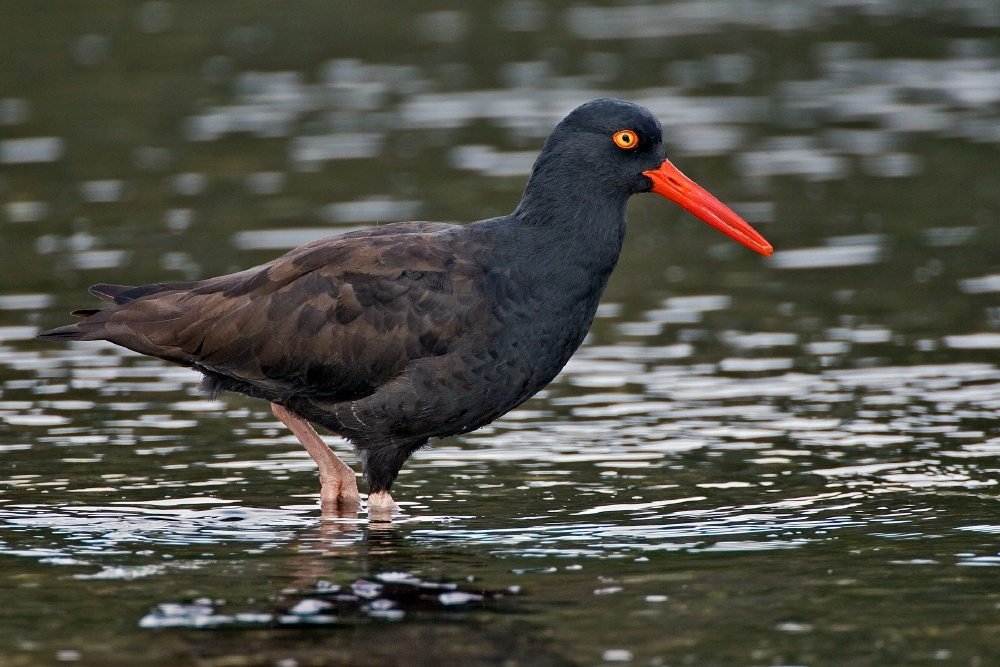

In [ ]:
# ==========================================================
# Display one cached WebQA image
# ==========================================================

from IPython.display import display

successful_result = next(
    (
        result
        for result in download_results
        if result["success"]
    ),
    None,
)

if successful_result is None:
    print("No image was downloaded successfully.")
else:
    image = Image.open(
        successful_result["local_path"]
    )

    print("Source:", successful_result["source_id"])
    print("Size:", image.size)
    print("Path:", successful_result["local_path"])

    display(image)

In [ ]:
print("Attempted images:", len(download_results))
print(
    "Successful:",
    sum(result["success"] for result in download_results),
)
print(
    "Failed:",
    sum(not result["success"] for result in download_results),
)

Attempted images: 30
Successful: 4
Failed: 26


In [ ]:
# ==========================================================
# Diagnose WebQA image download failures
# ==========================================================

from collections import Counter

failure_types = Counter()

for result in download_results:
    if result["success"]:
        continue

    error = str(result.get("error", "unknown_error"))

    if "429" in error:
        category = "HTTP 429 rate limit"
    elif "403" in error:
        category = "HTTP 403 forbidden"
    elif "404" in error:
        category = "HTTP 404 not found"
    elif "Timeout" in error or "timed out" in error:
        category = "timeout"
    elif "UnidentifiedImageError" in error:
        category = "invalid image response"
    elif "ConnectionError" in error:
        category = "connection error"
    else:
        category = error.split(":")[0]

    failure_types[category] += 1


print("Failure summary")
print("=" * 60)

for category, count in failure_types.most_common():
    print(f"{category:<35} {count}")


print("\nFirst 10 detailed failures")
print("=" * 60)

shown = 0

for result in download_results:
    if result["success"]:
        continue

    print("Source:", result["source_id"])
    print("Error:", result["error"])
    print("-" * 60)

    shown += 1

    if shown >= 10:
        break

Failure summary
HTTPError                           23
HTTP 429 rate limit                 3

First 10 detailed failures
Source: img_30104450
Error: HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/b/b8/Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg/800px-Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg
------------------------------------------------------------
Source: img_30338893
Error: HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Georgia_Tech_Student_Center.jpg/800px-Georgia_Tech_Student_Center.jpg
------------------------------------------------------------
Source: img_30224457
Error: HTTPError: 400 Client Error: Use thumbnail sizes listed on https://w.wiki/GHai for url: https://upload.wikimedia.org/wikipedia/commons/thumb/3/3c/Georgia_Tech_CRC_Front.jp

In [ ]:
# ==========================================================
# Fast Wikimedia thumbnail downloader
# ==========================================================

from pathlib import Path
from urllib.parse import urlsplit, urlunsplit
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import hashlib
import io
import requests
from PIL import Image

IMAGE_CACHE_DIR = Path(
    "/content/drive/MyDrive/webqa_selected_image_cache"
)
IMAGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def standardize_wikimedia_thumbnail(
    url,
    width=960,
):
    """
    Replace an existing Wikimedia thumbnail width, such as
    800px-Filename.jpg, with a supported standard width.
    """
    if not url:
        return url

    parsed = urlsplit(url)
    path_parts = parsed.path.split("/")

    if "thumb" not in path_parts:
        return url

    if not path_parts:
        return url

    filename = path_parts[-1]

    if "px-" in filename:
        original_name = filename.split("px-", 1)[1]
        path_parts[-1] = f"{width}px-{original_name}"

    new_path = "/".join(path_parts)

    return urlunsplit((
        parsed.scheme,
        parsed.netloc,
        new_path,
        parsed.query,
        parsed.fragment,
    ))


fast_retry_policy = Retry(
    total=2,
    connect=2,
    read=2,
    status=2,
    backoff_factor=0.5,
    status_forcelist=[
        429,
        500,
        502,
        503,
        504,
    ],
    allowed_methods=["GET"],
    respect_retry_after_header=True,
)

fast_http_session = requests.Session()

fast_http_session.mount(
    "https://",
    HTTPAdapter(max_retries=fast_retry_policy),
)

fast_http_session.headers.update({
    "User-Agent": (
        "HANIA-WebQA/1.0 "
        "(academic multimodal QA research)"
    ),
    "Accept": "image/*",
})


def fast_image_cache_path(source):
    source_id = str(source["source_id"])

    resolved_url = standardize_wikimedia_thumbnail(
        str(source.get("url", "")),
        width=960,
    )

    url_hash = hashlib.md5(
        resolved_url.encode("utf-8")
    ).hexdigest()[:10]

    return (
        IMAGE_CACHE_DIR
        / f"{source_id}_{url_hash}.jpg"
    )


def download_and_cache_image_fast(
    source,
    timeout=20,
):
    original_url = str(
        source.get("url", "")
    ).strip()

    if not original_url:
        return {
            "success": False,
            "error": "empty_url",
            "local_path": None,
            "resolved_url": None,
        }

    resolved_url = standardize_wikimedia_thumbnail(
        original_url,
        width=960,
    )

    output_path = fast_image_cache_path(source)

    if output_path.is_file():
        return {
            "success": True,
            "error": None,
            "local_path": str(output_path),
            "resolved_url": resolved_url,
        }

    try:
        response = fast_http_session.get(
            resolved_url,
            timeout=timeout,
        )
        response.raise_for_status()

        image = Image.open(
            io.BytesIO(response.content)
        ).convert("RGB")

        image.save(
            output_path,
            format="JPEG",
            quality=90,
        )

        return {
            "success": True,
            "error": None,
            "local_path": str(output_path),
            "resolved_url": resolved_url,
        }

    except Exception as error:
        return {
            "success": False,
            "error": (
                f"{type(error).__name__}: {error}"
            ),
            "local_path": None,
            "resolved_url": resolved_url,
        }

In [ ]:
# ==========================================================
# Fast test on five selected images
# ==========================================================

test_sources = [
    source
    for record in hybrid_processing_records
    for source in record["image_sources"]
][:5]

fast_download_results = []

for source in test_sources:
    result = download_and_cache_image_fast(source)

    source["local_image_path"] = result["local_path"]
    source["resolved_url"] = result["resolved_url"]
    source["download_error"] = result["error"]

    fast_download_results.append({
        "source_id": source["source_id"],
        **result,
    })

    print(
        source["source_id"],
        "->",
        "success" if result["success"] else result["error"],
    )


print("\nAttempted:", len(fast_download_results))
print(
    "Successful:",
    sum(
        result["success"]
        for result in fast_download_results
    ),
)
print(
    "Failed:",
    sum(
        not result["success"]
        for result in fast_download_results
    ),
)

img_30104450 -> success
img_30338893 -> success
img_30224457 -> success
img_30069935 -> RetryError: HTTPSConnectionPool(host='upload.wikimedia.org', port=443): Max retries exceeded with url: /wikipedia/commons/thumb/2/2c/Howey_Physics_Building%2C_Georgia_Tech..jpg/960px-Howey_Physics_Building%2C_Georgia_Tech..jpg (Caused by ResponseError('too many 429 error responses'))
img_30287519 -> RetryError: HTTPSConnectionPool(host='upload.wikimedia.org', port=443): Max retries exceeded with url: /wikipedia/commons/thumb/6/65/Georgia_Tech%2C_Atlanta%2C_GA%2C_USA_-_panoramio_-_Idawriter_%285%29.jpg/960px-Georgia_Tech%2C_Atlanta%2C_GA%2C_USA_-_panoramio_-_Idawriter_%285%29.jpg (Caused by ResponseError('too many 429 error responses'))

Attempted: 5
Successful: 3
Failed: 2


In [ ]:
# ==========================================================
# Inspect WebQA release directory
# ==========================================================

from pathlib import Path

WEBQA_DIR = Path(TRAIN_VAL_PATH).parent

print("WebQA directory:", WEBQA_DIR)
print("=" * 80)

for path in sorted(WEBQA_DIR.iterdir()):
    if path.is_file():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"FILE   {path.name:<45} {size_mb:.2f} MB")
    else:
        print(f"FOLDER {path.name}")

WebQA directory: /content/drive/MyDrive/plant imaes/WebQA_data_first_release
FILE   WebQA_test.json                               111.32 MB
FILE   WebQA_train_val.json                          631.26 MB
FILE   license.txt                                   0.00 MB


In [ ]:
# ==========================================================
# Search for local WebQA image resources
# ==========================================================

search_root = WEBQA_DIR.parent

image_directories = []
archives = []

for path in search_root.rglob("*"):
    name = path.name.lower()

    if path.is_dir() and any(
        token in name
        for token in ["image", "images", "img", "imgs"]
    ):
        image_directories.append(path)

    elif path.is_file() and path.suffix.lower() in {
        ".zip", ".tar", ".gz", ".tgz"
    }:
        archives.append(path)

print("Possible image directories:")
for path in image_directories[:30]:
    print(path)

print("\nPossible archives:")
for path in archives[:30]:
    print(path)

Possible image directories:

Possible archives:


In [ ]:
# ==========================================================
# Check Colab and Google Drive storage
# ==========================================================

!df -h /content
!df -h "/content/drive/MyDrive"

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   52G   62G  46% /
Filesystem      Size  Used Avail Use% Mounted on
drive            15G   11G  5.0G  68% /content/drive


In [ ]:
# ==========================================================
# Count unique images required for the 300-question experiment
# ==========================================================

all_selected_images = [
    source
    for record in hybrid_processing_records
    for source in record["image_sources"]
]

unique_images = {}

for source in all_selected_images:
    key = source.get("url") or source["source_id"]
    unique_images[key] = source

print("Total selected image references:", len(all_selected_images))
print("Unique images to download:", len(unique_images))

Total selected image references: 1083
Unique images to download: 1077


In [ ]:
# ==========================================================
# Evaluate raw-vision image budget
# ==========================================================

import numpy as np

IMAGE_BUDGETS = [1, 2, 3, 4, 5]

vision_budget_results = {
    budget: {
        "recall": [],
        "selected_count": [],
        "unique_urls": set(),
    }
    for budget in IMAGE_BUDGETS
}

image_question_count = 0

for record in ranked_validation_random:
    ranked_sources = record["ranked_sources"]

    gold_image_ids = {
        source["source_id"]
        for source in ranked_sources
        if (
            source.get("label") == 1
            and source["modality"] == "image"
        )
    }

    # Evaluate only questions whose gold evidence is visual.
    if not gold_image_ids:
        continue

    image_question_count += 1

    ranked_images = [
        source
        for source in ranked_sources
        if source["modality"] == "image"
    ]

    for budget in IMAGE_BUDGETS:
        selected_images = ranked_images[:budget]

        selected_ids = {
            source["source_id"]
            for source in selected_images
        }

        recall = (
            len(gold_image_ids & selected_ids)
            / len(gold_image_ids)
        )

        vision_budget_results[budget]["recall"].append(
            recall
        )

        vision_budget_results[budget][
            "selected_count"
        ].append(len(selected_images))

        for source in selected_images:
            url = str(source.get("url", "")).strip()

            if url:
                vision_budget_results[budget][
                    "unique_urls"
                ].add(url)


print("Image-evidence questions:", image_question_count)
print("=" * 80)

for budget in IMAGE_BUDGETS:
    result = vision_budget_results[budget]

    print(
        f"Top-{budget} images | "
        f"Image recall={np.mean(result['recall']):.4f} | "
        f"AvgImages={np.mean(result['selected_count']):.2f} | "
        f"UniqueDownloads={len(result['unique_urls'])}"
    )

Image-evidence questions: 161
Top-1 images | Image recall=0.5683 | AvgImages=1.00 | UniqueDownloads=161
Top-2 images | Image recall=0.7795 | AvgImages=2.00 | UniqueDownloads=321
Top-3 images | Image recall=0.8602 | AvgImages=3.00 | UniqueDownloads=482
Top-4 images | Image recall=0.9161 | AvgImages=4.00 | UniqueDownloads=643
Top-5 images | Image recall=0.9379 | AvgImages=5.00 | UniqueDownloads=802


In [ ]:
# ==========================================================
# Evaluate raw-vision caps within the hybrid pool
# ==========================================================

import numpy as np

VISION_CAPS = [1, 2, 3, 4, 5]

cap_results = {
    cap: {
        "image_recall": [],
        "image_counts": [],
        "unique_urls": set(),
    }
    for cap in VISION_CAPS
}

for record in ranked_validation_random:
    ranked = record["ranked_sources"]

    # Existing adaptive-image + fixed-text selection
    hybrid_sources = select_hybrid_processing_pool(ranked)

    hybrid_images = [
        source
        for source in hybrid_sources
        if source["modality"] == "image"
    ]

    gold_image_ids = {
        source["source_id"]
        for source in ranked
        if (
            source.get("label") == 1
            and source["modality"] == "image"
        )
    }

    for cap in VISION_CAPS:
        selected_images = hybrid_images[:cap]

        cap_results[cap]["image_counts"].append(
            len(selected_images)
        )

        for source in selected_images:
            url = str(source.get("url", "")).strip()

            if url:
                cap_results[cap]["unique_urls"].add(url)

        # Evaluate recall only for image-evidence questions
        if gold_image_ids:
            selected_ids = {
                source["source_id"]
                for source in selected_images
            }

            recall = (
                len(gold_image_ids & selected_ids)
                / len(gold_image_ids)
            )

            cap_results[cap]["image_recall"].append(
                recall
            )


print("Hybrid raw-vision budget comparison")
print("=" * 85)

for cap in VISION_CAPS:
    result = cap_results[cap]

    print(
        f"Cap={cap} | "
        f"ImageRecall={np.mean(result['image_recall']):.4f} | "
        f"AvgImagesAllQuestions="
        f"{np.mean(result['image_counts']):.2f} | "
        f"ActualUniqueDownloads="
        f"{len(result['unique_urls'])}"
    )

Hybrid raw-vision budget comparison
Cap=1 | ImageRecall=0.5683 | AvgImagesAllQuestions=0.99 | ActualUniqueDownloads=297
Cap=2 | ImageRecall=0.7764 | AvgImagesAllQuestions=1.85 | ActualUniqueDownloads=553
Cap=3 | ImageRecall=0.8571 | AvgImagesAllQuestions=2.58 | ActualUniqueDownloads=770
Cap=4 | ImageRecall=0.9037 | AvgImagesAllQuestions=3.19 | ActualUniqueDownloads=952
Cap=5 | ImageRecall=0.9224 | AvgImagesAllQuestions=3.61 | ActualUniqueDownloads=1077


In [ ]:
# ==========================================================
# Final raw-vision policy: maximum four images per question
# ==========================================================

import json
import os
import numpy as np

MAX_RAW_IMAGES = 4

vision_processing_records = []

for record in hybrid_processing_records:
    raw_image_sources = record["image_sources"][:MAX_RAW_IMAGES]
    caption_only_sources = record["image_sources"][MAX_RAW_IMAGES:]

    vision_processing_records.append({
        "dataset_index": record["dataset_index"],
        "guid": record["guid"],
        "question": record["question"],
        "answers": record["answers"],          # evaluation only
        "q_category": record["q_category"],
        "raw_image_sources": raw_image_sources,
        "caption_only_image_sources": caption_only_sources,
        "text_sources": record["text_sources"],
    })


unique_vision_sources = {}

for record in vision_processing_records:
    for source in record["raw_image_sources"]:
        key = source.get("url") or source["source_id"]
        unique_vision_sources[key] = source


print("Questions:", len(vision_processing_records))
print(
    "Average raw images:",
    np.mean([
        len(record["raw_image_sources"])
        for record in vision_processing_records
    ]),
)
print(
    "Average caption-only images:",
    np.mean([
        len(record["caption_only_image_sources"])
        for record in vision_processing_records
    ]),
)
print("Unique raw images:", len(unique_vision_sources))


VISION_MANIFEST_PATH = (
    "/content/drive/MyDrive/"
    "webqa_val_vision_manifest_cap4_random_300.json"
)

with open(VISION_MANIFEST_PATH, "w", encoding="utf-8") as file:
    json.dump(
        vision_processing_records,
        file,
        ensure_ascii=False,
    )

print("Saved:", VISION_MANIFEST_PATH)
print("File exists:", os.path.isfile(VISION_MANIFEST_PATH))

Questions: 300
Average raw images: 3.1933333333333334
Average caption-only images: 0.4166666666666667
Unique raw images: 952
Saved: /content/drive/MyDrive/webqa_val_vision_manifest_cap4_random_300.json
File exists: True


In [ ]:
# ==========================================================
# Deduplicated image-download manifest
# ==========================================================

vision_download_manifest = list(
    unique_vision_sources.values()
)

vision_download_manifest.sort(
    key=lambda source: (
        source.get("global_rank", 9999),
        source["source_id"],
    )
)

print("Images requiring download:", len(vision_download_manifest))
print("First source:", vision_download_manifest[0]["source_id"])

Images requiring download: 952
First source: img_30010181


In [ ]:
# ==========================================================
# Install Hugging Face datasets
# ==========================================================

!pip -q install -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.4 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# Check selected-image coverage in the WebQA HF mirror
# ==========================================================

from datasets import load_dataset, Image as HFImage
from tqdm.auto import tqdm

needed_image_ids = {
    str(source["official_id"])
    for source in vision_download_manifest
}

print("Needed image IDs:", len(needed_image_ids))

found_image_ids = set()
found_split_by_id = {}

for split_name in ["train", "test"]:
    stream = load_dataset(
        "Veblen34/webqa",
        split=split_name,
        streaming=True,
    )

    # Avoid decoding every image during the coverage scan
    stream = stream.cast_column(
        "image",
        HFImage(decode=False),
    )

    for row in tqdm(
        stream,
        desc=f"Scanning {split_name}",
    ):
        image_id = str(row["image_filename"]).strip()

        if image_id in needed_image_ids:
            found_image_ids.add(image_id)
            found_split_by_id.setdefault(
                image_id,
                split_name,
            )

        if len(found_image_ids) == len(needed_image_ids):
            break


missing_image_ids = (
    needed_image_ids - found_image_ids
)

print("\nCoverage summary")
print("=" * 60)
print("Needed:", len(needed_image_ids))
print("Found:", len(found_image_ids))
print("Missing:", len(missing_image_ids))
print(
    "Coverage:",
    f"{len(found_image_ids) / len(needed_image_ids):.4f}",
)

Needed image IDs: 952


README.md:   0%|          | 0.00/542 [00:00<?, ?B/s]

Scanning train: 0it [00:00, ?it/s]

Scanning test: 0it [00:00, ?it/s]


Coverage summary
Needed: 952
Found: 168
Missing: 784
Coverage: 0.1765


In [ ]:
# ==========================================================
# Save the 168 covered Hugging Face images locally
# ==========================================================

from pathlib import Path
from datasets import load_dataset
from tqdm.auto import tqdm

HF_IMAGE_CACHE_DIR = Path(
    "/content/webqa_hf_image_cache"
)
HF_IMAGE_CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

saved_image_ids = set()
failed_hf_images = {}


for split_name in ["train", "test"]:
    target_ids = {
        image_id
        for image_id, split in found_split_by_id.items()
        if split == split_name
    }

    if not target_ids:
        continue

    stream = load_dataset(
        "Veblen34/webqa",
        split=split_name,
        streaming=True,
    )

    remaining_ids = set(target_ids)

    for row in tqdm(
        stream,
        desc=f"Saving {split_name} images",
    ):
        image_id = str(
            row["image_filename"]
        ).strip()

        if image_id not in remaining_ids:
            continue

        output_path = (
            HF_IMAGE_CACHE_DIR
            / f"{image_id}.jpg"
        )

        try:
            image = row["image"]

            if hasattr(image, "convert"):
                image = image.convert("RGB")
            else:
                raise TypeError(
                    f"Unexpected image type: {type(image)}"
                )

            image.save(
                output_path,
                format="JPEG",
                quality=92,
            )

            saved_image_ids.add(image_id)
            remaining_ids.remove(image_id)

        except Exception as error:
            failed_hf_images[image_id] = (
                f"{type(error).__name__}: {error}"
            )
            remaining_ids.remove(image_id)

        if not remaining_ids:
            break


print("Covered IDs:", len(found_image_ids))
print("Successfully saved:", len(saved_image_ids))
print("Failed to save:", len(failed_hf_images))
print("Cache directory:", HF_IMAGE_CACHE_DIR)

Saving train images: 0it [00:00, ?it/s]

Saving test images: 0it [00:00, ?it/s]

Covered IDs: 168
Successfully saved: 168
Failed to save: 0
Cache directory: /content/webqa_hf_image_cache


In [ ]:
# ==========================================================
# Attach Hugging Face image paths to the vision manifest
# ==========================================================

available_raw_references = 0
missing_raw_references = 0

for record in vision_processing_records:
    for source in record["raw_image_sources"]:
        image_id = str(source["official_id"])

        local_path = (
            HF_IMAGE_CACHE_DIR
            / f"{image_id}.jpg"
        )

        if local_path.is_file():
            source["local_image_path"] = str(local_path)
            source["image_origin"] = "huggingface_mirror"
            available_raw_references += 1
        else:
            source["local_image_path"] = None
            source["image_origin"] = None
            missing_raw_references += 1


print("Available raw-image references:", available_raw_references)
print("Missing raw-image references:", missing_raw_references)

Available raw-image references: 168
Missing raw-image references: 790


In [ ]:
# ==========================================================
# Question-level visual coverage
# ==========================================================

questions_with_any_image = 0
questions_with_all_images = 0
questions_without_images = 0

for record in vision_processing_records:
    raw_sources = record["raw_image_sources"]

    available_count = sum(
        source.get("local_image_path") is not None
        for source in raw_sources
    )

    if available_count == 0:
        questions_without_images += 1
    else:
        questions_with_any_image += 1

    if raw_sources and available_count == len(raw_sources):
        questions_with_all_images += 1


print("Total questions:", len(vision_processing_records))
print(
    "Questions with at least one available image:",
    questions_with_any_image,
)
print(
    "Questions with all selected images available:",
    questions_with_all_images,
)
print(
    "Questions without available selected images:",
    questions_without_images,
)

Total questions: 300
Questions with at least one available image: 147
Questions with all selected images available: 31
Questions without available selected images: 153


In [ ]:
# ==========================================================
# Measure gold-image coverage in the local image cache
# ==========================================================

import numpy as np

local_image_ids = {
    path.stem
    for path in HF_IMAGE_CACHE_DIR.glob("*.jpg")
}

# The filenames are official image IDs, e.g. 30104450.jpg
questions_with_gold_images = 0
questions_with_any_gold_available = 0
questions_with_all_gold_available = 0

gold_image_recall_values = []

for record in ranked_validation_random:
    ranked_sources = record["ranked_sources"]

    gold_image_ids = {
        str(source["official_id"])
        for source in ranked_sources
        if (
            source.get("label") == 1
            and source["modality"] == "image"
        )
    }

    if not gold_image_ids:
        continue

    questions_with_gold_images += 1

    available_gold_ids = (
        gold_image_ids & local_image_ids
    )

    if available_gold_ids:
        questions_with_any_gold_available += 1

    if available_gold_ids == gold_image_ids:
        questions_with_all_gold_available += 1

    gold_image_recall_values.append(
        len(available_gold_ids) / len(gold_image_ids)
    )


print("Image-evidence questions:", questions_with_gold_images)
print(
    "Questions with at least one gold image available:",
    questions_with_any_gold_available,
)
print(
    "Questions with all gold images available:",
    questions_with_all_gold_available,
)
print(
    "Local gold-image recall:",
    f"{np.mean(gold_image_recall_values):.4f}",
)

Image-evidence questions: 161
Questions with at least one gold image available: 146
Questions with all gold images available: 101
Local gold-image recall: 0.7671


In [ ]:
# ==========================================================
# Build partial and complete visual test subsets
# ==========================================================

partial_visual_test_records = []
complete_visual_test_records = []

for record in vision_processing_records:
    available_images = [
        source
        for source in record["raw_image_sources"]
        if source.get("local_image_path")
    ]

    unavailable_images = [
        source
        for source in record["raw_image_sources"]
        if not source.get("local_image_path")
    ]

    if available_images:
        partial_visual_test_records.append({
            "dataset_index": record["dataset_index"],
            "guid": record["guid"],
            "question": record["question"],
            "answers": record["answers"],  # evaluation only
            "q_category": record["q_category"],
            "raw_image_sources": available_images,
            "unavailable_image_sources": unavailable_images,
            "caption_only_image_sources":
                record["caption_only_image_sources"],
            "text_sources": record["text_sources"],
        })

    if (
        record["raw_image_sources"]
        and not unavailable_images
    ):
        complete_visual_test_records.append({
            "dataset_index": record["dataset_index"],
            "guid": record["guid"],
            "question": record["question"],
            "answers": record["answers"],  # evaluation only
            "q_category": record["q_category"],
            "raw_image_sources": available_images,
            "caption_only_image_sources":
                record["caption_only_image_sources"],
            "text_sources": record["text_sources"],
        })


print("Partial visual subset:", len(partial_visual_test_records))
print("Complete visual subset:", len(complete_visual_test_records))

Partial visual subset: 147
Complete visual subset: 31


GUID: d5c468d80dba11ecb1e81171463288e9
Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Category: choose
Raw images: 1
Text sources: 5

Image: 1
Source ID: img_30104450
Global rank: 1
Caption: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)
Path exists: True
Path: /content/webqa_hf_image_cache/30104450.jpg
Size: (800, 532)


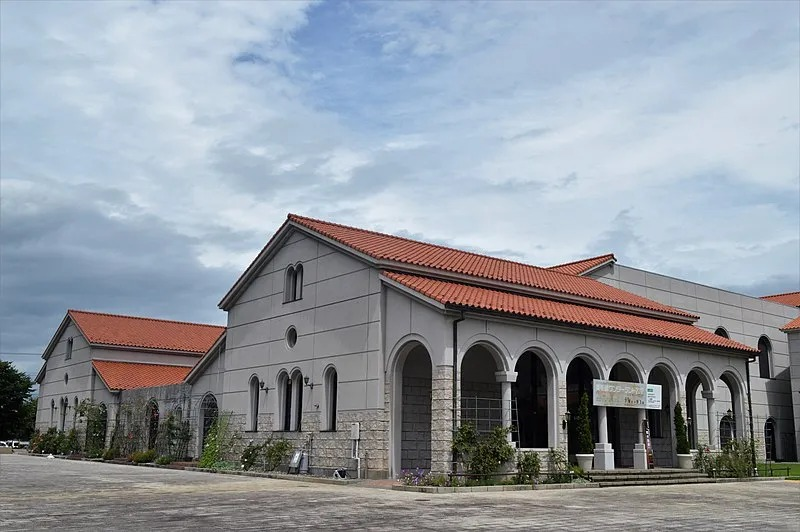

In [ ]:
# ==========================================================
# Inspect one complete visual example
# ==========================================================

from pathlib import Path
from PIL import Image
from IPython.display import display

example = complete_visual_test_records[0]

print("GUID:", example["guid"])
print("Question:", example["question"])
print("Category:", example["q_category"])
print("Raw images:", len(example["raw_image_sources"]))
print("Text sources:", len(example["text_sources"]))

for index, source in enumerate(
    example["raw_image_sources"],
    start=1,
):
    image_path = Path(source["local_image_path"])

    print("\n" + "=" * 70)
    print("Image:", index)
    print("Source ID:", source["source_id"])
    print("Global rank:", source.get("global_rank"))
    print("Caption:", source.get("caption", ""))
    print("Path exists:", image_path.is_file())
    print("Path:", image_path)

    if image_path.is_file():
        image = Image.open(image_path).convert("RGB")
        print("Size:", image.size)
        display(image)

In [ ]:
# ==========================================================
# Check existing vision-model variables
# ==========================================================

for variable_name in [
    "processor",
    "vision_processor",
    "vision_model",
    "vl_model",
    "qwen_model",
]:
    if variable_name in globals():
        value = globals()[variable_name]
        print(
            variable_name,
            "->",
            type(value).__name__,
        )
    else:
        print(variable_name, "-> not defined")

processor -> ellipsis
vision_processor -> not defined
vision_model -> ellipsis
vl_model -> not defined
qwen_model -> not defined


In [ ]:
# ==========================================================
# Remove accidental ellipsis placeholders
# ==========================================================

for variable_name in ["processor", "vision_model"]:
    if variable_name in globals():
        del globals()[variable_name]

print("processor defined:", "processor" in globals())
print("vision_model defined:", "vision_model" in globals())

processor defined: False
vision_model defined: False


In [ ]:
# ==========================================================
# Check GPU before loading Qwen3-VL
# ==========================================================

import torch

if torch.cuda.is_available():
    gpu_properties = torch.cuda.get_device_properties(0)

    print("GPU:", gpu_properties.name)
    print(
        "GPU memory:",
        round(gpu_properties.total_memory / (1024 ** 3), 2),
        "GB",
    )
else:
    print("CUDA is not available.")

GPU: Tesla T4
GPU memory: 14.56 GB


In [ ]:
# ==========================================================
# Install Qwen3-VL dependencies
# ==========================================================

!pip -q install -U \
    "transformers>=4.57.0" \
    accelerate \
    bitsandbytes \
    qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 26.6 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# Check Qwen3-VL compatibility without restarting
# ==========================================================

import transformers
import torch

print("Transformers version:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

try:
    from transformers import (
        AutoProcessor,
        AutoModelForImageTextToText,
    )
    print("AutoModelForImageTextToText: available")
except ImportError as error:
    print("AutoModelForImageTextToText: unavailable")
    print(error)

try:
    from transformers import (
        Qwen3VLForConditionalGeneration,
    )
    print("Qwen3VLForConditionalGeneration: available")
except ImportError as error:
    print("Qwen3VLForConditionalGeneration: unavailable")
    print(error)

Transformers version: 5.14.1
CUDA available: True
AutoModelForImageTextToText: available
Qwen3VLForConditionalGeneration: available


In [ ]:
# ==========================================================
# Back up current visual subsets before loading the model
# ==========================================================

import json
import os

SUBSET_BACKUPS = {
    "webqa_partial_visual_subset_147.json":
        partial_visual_test_records,

    "webqa_complete_visual_subset_31.json":
        complete_visual_test_records,
}

for filename, records in SUBSET_BACKUPS.items():
    output_path = (
        f"/content/drive/MyDrive/{filename}"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            records,
            file,
            ensure_ascii=False,
        )

    print(
        filename,
        "->",
        os.path.isfile(output_path),
    )

webqa_partial_visual_subset_147.json -> True
webqa_complete_visual_subset_31.json -> True


In [ ]:
# ==========================================================
# Ensure 4-bit quantization dependencies are available
# ==========================================================

import importlib.util
import subprocess
import sys

required_packages = [
    "bitsandbytes",
    "accelerate",
]

missing_packages = [
    package
    for package in required_packages
    if importlib.util.find_spec(package) is None
]

if missing_packages:
    print("Installing:", missing_packages)

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing_packages,
    ])
else:
    print("Required packages are already installed.")

import bitsandbytes
import accelerate

print("bitsandbytes:", bitsandbytes.__version__)
print("accelerate:", accelerate.__version__)

Required packages are already installed.
bitsandbytes: 0.49.2
accelerate: 1.14.0


In [ ]:
# ==========================================================
# Free GPU memory without restarting the runtime
# ==========================================================

import gc
import torch

heavy_model_variables = [
    "source_reranker",
    "glirel_model",
    "vision_model",
    "vision_processor",
]

for variable_name in heavy_model_variables:
    if variable_name in globals():
        del globals()[variable_name]
        print("Removed:", variable_name)

gc.collect()
torch.cuda.empty_cache()

free_memory, total_memory = torch.cuda.mem_get_info()

print(
    "Free GPU memory:",
    round(free_memory / (1024 ** 3), 2),
    "GB",
)

print(
    "Total GPU memory:",
    round(total_memory / (1024 ** 3), 2),
    "GB",
)

print("Visual subset records:", len(complete_visual_test_records))
print("Cached images:", len(list(HF_IMAGE_CACHE_DIR.glob('*.jpg'))))

Removed: source_reranker
Removed: glirel_model
Free GPU memory: 14.41 GB
Total GPU memory: 14.56 GB
Visual subset records: 31
Cached images: 168


In [ ]:
# ==========================================================
# Load Qwen3-VL-8B-Instruct in 4-bit on Tesla T4
# ==========================================================

import torch

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
)

VISION_MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading processor...")

vision_processor = AutoProcessor.from_pretrained(
    VISION_MODEL_NAME,

    # Constrain visual resolution for the T4.
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,
)

print("Loading 4-bit model...")

vision_model = (
    Qwen3VLForConditionalGeneration.from_pretrained(
        VISION_MODEL_NAME,
        quantization_config=quantization_config,
        device_map="auto",
        dtype=torch.float16,
        attn_implementation="sdpa",
        low_cpu_mem_usage=True,
    )
)

vision_model.eval()

print("Vision model loaded successfully.")
print(
    "First model device:",
    next(vision_model.parameters()).device,
)

Loading processor...


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.47k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Vision model loaded successfully.
First model device: cuda:0


In [ ]:
# ==========================================================
# Load Qwen3-VL-8B-Instruct in 4-bit on Tesla T4
# ==========================================================

import torch

from transformers import (
    AutoProcessor,
    BitsAndBytesConfig,
    Qwen3VLForConditionalGeneration,
)

VISION_MODEL_NAME = "Qwen/Qwen3-VL-8B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

print("Loading processor...")

vision_processor = AutoProcessor.from_pretrained(
    VISION_MODEL_NAME,

    # Constrain visual resolution for the T4.
    min_pixels=256 * 28 * 28,
    max_pixels=512 * 28 * 28,
)

print("Loading 4-bit model...")

vision_model = (
    Qwen3VLForConditionalGeneration.from_pretrained(
        VISION_MODEL_NAME,
        quantization_config=quantization_config,
        device_map="auto",
        dtype=torch.float16,
        attn_implementation="sdpa",
        low_cpu_mem_usage=True,
    )
)

vision_model.eval()

print("Vision model loaded successfully.")
print(
    "First model device:",
    next(vision_model.parameters()).device,
)

Loading processor...
Loading 4-bit model...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

Vision model loaded successfully.
First model device: cuda:0


In [ ]:
# ==========================================================
# Test one image with Qwen3-VL
# ==========================================================

import gc
import torch
from PIL import Image

test_record = complete_visual_test_records[0]
test_source = test_record["raw_image_sources"][0]

question = test_record["question"]
caption = test_source.get("caption", "")
image_path = test_source["local_image_path"]

test_image = Image.open(image_path).convert("RGB")

prompt = f"""
Question: {question}

Existing caption: {caption}

Inspect the image and extract only the visible evidence needed to
answer the question.

Rules:
- Use only what is visible in the image.
- Do not use outside knowledge.
- Do not guess if the relevant detail is unclear.
- Do not provide a final long explanation.
- Respond in one concise sentence.
""".strip()

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": test_image,
            },
            {
                "type": "text",
                "text": prompt,
            },
        ],
    }
]

inputs = vision_processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_dict=True,
    return_tensors="pt",
)

inputs = inputs.to(
    next(vision_model.parameters()).device
)

with torch.inference_mode():
    output_ids = vision_model.generate(
        **inputs,
        max_new_tokens=64,
        do_sample=False,
        use_cache=True,
    )

generated_only = output_ids[
    :,
    inputs["input_ids"].shape[-1]:
]

visual_evidence = vision_processor.batch_decode(
    generated_only,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0].strip()

print("Question:", question)
print("Source ID:", test_source["source_id"])
print("Caption:", caption)
print("\nVisual evidence:")
print(visual_evidence)

# Release inference tensors while preserving the model
del inputs, output_ids, generated_only
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source ID: img_30104450
Caption: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)

Visual evidence:
The roof of the Azumino Municipal Museum of Modern Art is tiered, as visible sections rise at different levels.


In [ ]:
# ==========================================================
# Reusable question-aware visual evidence extractor
# ==========================================================

import gc
import torch
from PIL import Image


def extract_visual_evidence(
    question,
    source,
    max_new_tokens=64,
):
    image_path = source.get("local_image_path")

    if not image_path:
        return {
            "success": False,
            "visual_evidence": "",
            "error": "missing_local_image_path",
        }

    caption = str(
        source.get("caption", "")
    ).strip()

    prompt = f"""
Question: {question}

Existing caption: {caption}

Inspect this image and extract only the visible evidence needed to
answer the question.

Rules:
- Use only visible image content.
- Do not use outside knowledge.
- Do not guess when the relevant detail is unclear.
- Do not provide unrelated background.
- Respond in one concise sentence.
""".strip()

    try:
        with Image.open(image_path) as image_file:
            image = image_file.convert("RGB").copy()

        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            }
        ]

        inputs = vision_processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt",
        )

        model_device = next(
            vision_model.parameters()
        ).device

        inputs = inputs.to(model_device)

        with torch.inference_mode():
            output_ids = vision_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )

        generated_only = output_ids[
            :,
            inputs["input_ids"].shape[-1]:
        ]

        evidence = vision_processor.batch_decode(
            generated_only,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()

        del inputs, output_ids, generated_only, image
        gc.collect()
        torch.cuda.empty_cache()

        return {
            "success": True,
            "visual_evidence": evidence,
            "error": None,
        }

    except Exception as error:
        gc.collect()
        torch.cuda.empty_cache()

        return {
            "success": False,
            "visual_evidence": "",
            "error": (
                f"{type(error).__name__}: {error}"
            ),
        }

In [ ]:
# ==========================================================
# Updated question-aware visual evidence extractor
# ==========================================================

import gc
import torch
from PIL import Image


def extract_visual_evidence(
    question,
    source,
    max_new_tokens=64,
):
    image_path = source.get("local_image_path")

    if not image_path:
        return {
            "success": False,
            "visual_evidence": "",
            "error": "missing_local_image_path",
        }

    caption = str(
        source.get("caption", "")
    ).strip()

    prompt = f"""
Question: {question}

Image caption: {caption}

Extract only the visual evidence in this single image that is relevant
to answering the question.

Rules:
- Use only information that is visibly supported by the image.
- Use the caption only to identify the depicted scene; do not treat it
  as proof of the answer.
- Do not use outside knowledge.
- Do not infer nationality, identity, date, location, occupation, or
  event participation unless it is explicitly supported by visible
  text, flags, uniforms, labels, or other unambiguous visual evidence.
- Do not interpret the absence of a visible person or object as a count
  of zero unless the complete relevant scene is clearly visible.
- Do not combine information from other images.
- If the requested fact cannot be established from this image, respond
  exactly: Not determinable from this image.
- Otherwise, respond with one concise evidence sentence.
""".strip()

    inputs = None
    output_ids = None
    generated_only = None
    image = None

    try:
        with Image.open(image_path) as image_file:
            image = image_file.convert("RGB").copy()

        messages = [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image",
                        "image": image,
                    },
                    {
                        "type": "text",
                        "text": prompt,
                    },
                ],
            }
        ]

        inputs = vision_processor.apply_chat_template(
            messages,
            tokenize=True,
            add_generation_prompt=True,
            return_dict=True,
            return_tensors="pt",
        )

        model_device = next(
            vision_model.parameters()
        ).device

        inputs = inputs.to(model_device)

        with torch.inference_mode():
            output_ids = vision_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
            )

        input_length = inputs["input_ids"].shape[-1]

        generated_only = output_ids[:, input_length:]

        evidence = vision_processor.batch_decode(
            generated_only,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=False,
        )[0].strip()

        if not evidence:
            evidence = "Not determinable from this image."

        return {
            "success": True,
            "visual_evidence": evidence,
            "error": None,
        }

    except Exception as error:
        return {
            "success": False,
            "visual_evidence": "",
            "error": f"{type(error).__name__}: {error}",
        }

    finally:
        del inputs, output_ids, generated_only, image
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

In [ ]:
# ==========================================================
# Reprocess first three questions with updated extractor
# ==========================================================

import json
import os
from tqdm.auto import tqdm

VISUAL_EVIDENCE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_qwen_visual_evidence_complete31.json"
)

if os.path.isfile(VISUAL_EVIDENCE_PATH):
    with open(
        VISUAL_EVIDENCE_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        visual_evidence_cache = json.load(file)
else:
    visual_evidence_cache = {}


PILOT_QUESTION_COUNT = 3

for record in tqdm(
    complete_visual_test_records[:PILOT_QUESTION_COUNT],
    desc="Reprocessing visual evidence",
):
    guid = record["guid"]
    question = record["question"]

    # Overwrite earlier results for this question
    visual_evidence_cache[guid] = {
        "guid": guid,
        "question": question,
        "q_category": record["q_category"],
        "sources": {},
    }

    for source in record["raw_image_sources"]:
        source_id = source["source_id"]

        result = extract_visual_evidence(
            question=question,
            source=source,
        )

        visual_evidence_cache[guid]["sources"][source_id] = {
            "source_id": source_id,
            "official_id": source.get("official_id"),
            "global_rank": source.get("global_rank"),
            "source_score": source.get("source_score"),
            "caption": source.get("caption", ""),
            "local_image_path": source.get(
                "local_image_path"
            ),
            **result,
        }

        print("\nQuestion:", question)
        print("Source:", source_id)

        if result["success"]:
            print(
                "Evidence:",
                result["visual_evidence"],
            )
        else:
            print(
                "Error:",
                result["error"],
            )

    # Save after every question
    with open(
        VISUAL_EVIDENCE_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            visual_evidence_cache,
            file,
            ensure_ascii=False,
            indent=2,
        )


print("\nProcessed questions:", PILOT_QUESTION_COUNT)
print("Saved:", VISUAL_EVIDENCE_PATH)

Reprocessing visual evidence:   0%|          | 0/3 [00:00<?, ?it/s]


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Evidence: The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.

Question: Does Welcome to Erith maintain a consistent width from top to bottom?
Source: img_30160387
Evidence: No, the sculpture narrows toward the top and widens toward the base.

Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
Source: img_30353588
Evidence: Two athletes are visibly wearing jackets with the word "GERMANY" on them.

Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
Source: img_30174907
Evidence: Not determinable from this image.

Processed questions: 3
Saved: /content/drive/MyDrive/webqa_qwen_visual_evidence_complete31.json


In [ ]:
# ==========================================================
# Process all 31 complete visual questions
# ==========================================================

import json
import os
from tqdm.auto import tqdm

VISUAL_EVIDENCE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_qwen_visual_evidence_complete31.json"
)

# Load previously processed results
if os.path.isfile(VISUAL_EVIDENCE_PATH):
    with open(
        VISUAL_EVIDENCE_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        visual_evidence_cache = json.load(file)
else:
    visual_evidence_cache = {}


for record in tqdm(
    complete_visual_test_records,
    desc="Processing complete visual subset",
):
    guid = str(record["guid"])
    question = record["question"]

    # Preserve already processed sources
    if guid not in visual_evidence_cache:
        visual_evidence_cache[guid] = {
            "guid": guid,
            "question": question,
            "q_category": record.get("q_category"),
            "sources": {},
        }

    for source in record["raw_image_sources"]:
        source_id = source["source_id"]

        existing_result = (
            visual_evidence_cache[guid]
            .get("sources", {})
            .get(source_id)
        )

        # Skip successful previous inference
        if (
            existing_result is not None
            and existing_result.get("success") is True
        ):
            continue

        result = extract_visual_evidence(
            question=question,
            source=source,
        )

        visual_evidence_cache[guid]["sources"][
            source_id
        ] = {
            "source_id": source_id,
            "official_id": source.get("official_id"),
            "global_rank": source.get("global_rank"),
            "source_score": source.get("source_score"),
            "title": source.get("title", ""),
            "caption": source.get("caption", ""),
            "local_image_path": source.get(
                "local_image_path"
            ),
            **result,
        }

        print("\nQuestion:", question)
        print("Source:", source_id)

        if result["success"]:
            print(
                "Evidence:",
                result["visual_evidence"],
            )
        else:
            print(
                "Error:",
                result["error"],
            )

        # Save after every image source
        with open(
            VISUAL_EVIDENCE_PATH,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                visual_evidence_cache,
                file,
                ensure_ascii=False,
                indent=2,
            )


print("\nProcessing completed.")
print("Saved:", VISUAL_EVIDENCE_PATH)

Processing complete visual subset:   0%|          | 0/31 [00:00<?, ?it/s]


Question: Are there at least 10 people and animals represented on the front doors of the Brooklyn Public Library?
Source: img_30261968
Evidence: Not determinable from this image.

Question: Which word is written on the side of the Elks building?
Source: img_30231274
Evidence: The word "POE" is written on the side of the building.

Question: Is it the male or female outfit at a traditional Shinto wedding that features a hood?
Source: img_30172838
Evidence: The woman in the center is wearing a white kimono with a red sash and a white hood, while the man to her left is wearing a white kimono without a hood.

Question: Are there any trees near the Garden pavilion in Rogów Opolski which are taller than the pavilion?
Source: img_30023895
Evidence: Yes, a tree with a thick trunk and visible height is standing to the left of the pavilion, and its top is above the roofline of the pavilion.

Question: Do Vilnius Cathedral and the Kurhaus both have four or more architectural columns?
Source: img

In [ ]:
# ==========================================================
# Summarize visual evidence extraction
# ==========================================================

total_questions = len(visual_evidence_cache)
total_sources = 0
successful_sources = 0
failed_sources = 0
not_determinable_sources = 0

for record in visual_evidence_cache.values():
    for source in record.get("sources", {}).values():
        total_sources += 1

        if source.get("success"):
            successful_sources += 1

            evidence = source.get(
                "visual_evidence",
                "",
            ).strip().lower()

            if evidence.startswith(
                "not determinable from this image"
            ):
                not_determinable_sources += 1
        else:
            failed_sources += 1


print("Questions:", total_questions)
print("Image sources:", total_sources)
print("Successful extractions:", successful_sources)
print("Not determinable:", not_determinable_sources)
print("Failed extractions:", failed_sources)

Questions: 31
Image sources: 33
Successful extractions: 33
Not determinable: 6
Failed extractions: 0


In [ ]:
# ==========================================================
# Process all locally available images in partial subset
# ==========================================================

import json
import os
from pathlib import Path
from tqdm.auto import tqdm

PARTIAL_EVIDENCE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_qwen_visual_evidence_partial147.json"
)

COMPLETE_EVIDENCE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_qwen_visual_evidence_complete31.json"
)

# Resume an existing partial run, or initialize it using
# the already completed 31-question cache.
if os.path.isfile(PARTIAL_EVIDENCE_PATH):
    with open(
        PARTIAL_EVIDENCE_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        partial_visual_evidence_cache = json.load(file)

elif os.path.isfile(COMPLETE_EVIDENCE_PATH):
    with open(
        COMPLETE_EVIDENCE_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        partial_visual_evidence_cache = json.load(file)

else:
    partial_visual_evidence_cache = {}


for record in tqdm(
    partial_visual_test_records,
    desc="Processing partial visual subset",
):
    guid = str(record["guid"])
    question = record["question"]

    partial_visual_evidence_cache.setdefault(
        guid,
        {
            "guid": guid,
            "question": question,
            "q_category": record.get("q_category"),
            "sources": {},
        },
    )

    for source in record.get("raw_image_sources", []):
        source_id = source["source_id"]
        image_path = source.get("local_image_path")

        # Process only genuinely available local images.
        if (
            not image_path
            or not Path(image_path).is_file()
        ):
            continue

        existing = (
            partial_visual_evidence_cache[guid]
            .get("sources", {})
            .get(source_id)
        )

        # Safely resume without repeating successful inference.
        if (
            existing is not None
            and existing.get("success") is True
        ):
            continue

        result = extract_visual_evidence(
            question=question,
            source=source,
        )

        partial_visual_evidence_cache[guid][
            "sources"
        ][source_id] = {
            "source_id": source_id,
            "official_id": source.get("official_id"),
            "global_rank": source.get("global_rank"),
            "source_score": source.get("source_score"),
            "title": source.get("title", ""),
            "caption": source.get("caption", ""),
            "local_image_path": image_path,
            **result,
        }

        print("\nQuestion:", question)
        print("Source:", source_id)

        if result["success"]:
            print(
                "Evidence:",
                result["visual_evidence"],
            )
        else:
            print("Error:", result["error"])

        # Save after every inference.
        with open(
            PARTIAL_EVIDENCE_PATH,
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(
                partial_visual_evidence_cache,
                file,
                ensure_ascii=False,
                indent=2,
            )


print("\nProcessing complete.")
print("Saved:", PARTIAL_EVIDENCE_PATH)

Processing partial visual subset:   0%|          | 0/147 [00:00<?, ?it/s]


Question: What material is the Georgia Tech Student Center made out of?
Source: img_30338893
Evidence: The Georgia Tech Student Center is visibly constructed primarily of red brick.

Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
Source: img_30087112
Evidence: The beak of the bird in the image appears relatively short and slender compared to its head and body size.

Question: Which police department is across the street from jvc?
Source: img_30277520
Evidence: Not determinable from this image.

Question: Are there any definite shapes in the painting by ravi mandlik or Abstract Number 25 by Carle Hessay?
Source: img_30022354
Evidence: The painting contains only abstract forms and colors with no definite shapes.

Question: What material makes up the exterior of the Times Square Tower?
Source: img_30091171
Evidence: The exterior of the Times Square Tower is visibly composed of reflective glass panels arran

In [ ]:
# ==========================================================
# Summarize partial-subset visual extraction
# ==========================================================

questions_with_evidence = 0
source_occurrences = 0
successful = 0
not_determinable = 0
failed = 0
unique_image_ids = set()

for record in partial_visual_evidence_cache.values():
    sources = record.get("sources", {})

    if sources:
        questions_with_evidence += 1

    for source_id, source in sources.items():
        source_occurrences += 1
        unique_image_ids.add(source_id)

        if source.get("success") is True:
            successful += 1

            evidence = str(
                source.get("visual_evidence", "")
            ).strip().lower()

            if evidence.startswith(
                "not determinable from this image"
            ):
                not_determinable += 1
        else:
            failed += 1


print(
    "Questions with visual evidence:",
    questions_with_evidence,
)
print("Image-source occurrences:", source_occurrences)
print("Unique image sources:", len(unique_image_ids))
print("Successful extractions:", successful)
print("Not determinable:", not_determinable)
print("Failed extractions:", failed)

Questions with visual evidence: 147
Image-source occurrences: 168
Unique image sources: 168
Successful extractions: 168
Not determinable: 44
Failed extractions: 0


In [ ]:
# ==========================================================
# Build source-local evidence documents with provenance
# ==========================================================

import json
import os
import re

PARTIAL_EVIDENCE_PATH = (
    "/content/drive/MyDrive/"
    "webqa_qwen_visual_evidence_partial147.json"
)

SOURCE_DOCUMENTS_PATH = (
    "/content/drive/MyDrive/"
    "webqa_partial147_source_local_documents.json"
)

with open(
    PARTIAL_EVIDENCE_PATH,
    "r",
    encoding="utf-8",
) as file:
    partial_visual_evidence_cache = json.load(file)


def normalize_evidence_text(value):
    value = str(value or "")
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def is_visual_abstention(evidence):
    evidence = normalize_evidence_text(
        evidence
    ).lower()

    return evidence.startswith(
        "not determinable from this image"
    )


def build_source_document(
    source,
    source_kind,
    visual_result=None,
):
    source_id = str(source["source_id"])

    title = normalize_evidence_text(
        source.get("title", "")
    )

    caption = normalize_evidence_text(
        source.get("caption", "")
    )

    text = normalize_evidence_text(
        source.get(
            "text",
            source.get("snippet", ""),
        )
    )

    visual_evidence = ""
    visual_available = False
    visual_abstained = False

    if visual_result:
        visual_evidence = normalize_evidence_text(
            visual_result.get(
                "visual_evidence",
                "",
            )
        )

        visual_abstained = is_visual_abstention(
            visual_evidence
        )

        visual_available = (
            visual_result.get("success") is True
            and bool(visual_evidence)
            and not visual_abstained
        )

    evidence_parts = []

    if title:
        evidence_parts.append(
            f"Title: {title}"
        )

    if source_kind == "text":
        if text:
            evidence_parts.append(
                f"Text: {text}"
            )

    else:
        if caption:
            evidence_parts.append(
                f"Image caption: {caption}"
            )

        if visual_available:
            evidence_parts.append(
                f"Visible evidence: {visual_evidence}"
            )

    return {
        "source_id": source_id,
        "official_id": str(
            source.get("official_id", "")
        ),
        "source_kind": source_kind,
        "title": title,
        "caption": caption,
        "text": text,
        "visual_evidence": (
            visual_evidence
            if visual_available
            else ""
        ),
        "visual_available": visual_available,
        "visual_abstained": visual_abstained,
        "evidence_text": "\n".join(
            evidence_parts
        ).strip(),
        "source_score": source.get(
            "source_score"
        ),
        "global_rank": source.get(
            "global_rank"
        ),
        "local_image_path": source.get(
            "local_image_path"
        ),
    }

In [ ]:
# ==========================================================
# Construct source-local documents for all 147 questions
# ==========================================================

partial_source_document_records = []

for record in partial_visual_test_records:
    guid = str(record["guid"])
    question = normalize_evidence_text(
        record["question"]
    )

    cached_question = (
        partial_visual_evidence_cache.get(
            guid,
            {},
        )
    )

    cached_sources = cached_question.get(
        "sources",
        {},
    )

    source_documents = []
    seen_source_ids = set()

    # --------------------------------------
    # Raw image sources
    # --------------------------------------
    for source in record.get(
        "raw_image_sources",
        [],
    ):
        source_id = str(source["source_id"])

        if source_id in seen_source_ids:
            continue

        source_documents.append(
            build_source_document(
                source=source,
                source_kind="image_visual",
                visual_result=cached_sources.get(
                    source_id
                ),
            )
        )

        seen_source_ids.add(source_id)

    # --------------------------------------
    # Caption-only image sources
    # --------------------------------------
    for source in record.get(
        "caption_only_image_sources",
        [],
    ):
        source_id = str(source["source_id"])

        if source_id in seen_source_ids:
            continue

        source_documents.append(
            build_source_document(
                source=source,
                source_kind="image_caption",
                visual_result=None,
            )
        )

        seen_source_ids.add(source_id)

    # --------------------------------------
    # Text sources
    # --------------------------------------
    for source in record.get(
        "text_sources",
        [],
    ):
        source_id = str(source["source_id"])

        if source_id in seen_source_ids:
            continue

        source_documents.append(
            build_source_document(
                source=source,
                source_kind="text",
                visual_result=None,
            )
        )

        seen_source_ids.add(source_id)

    partial_source_document_records.append({
        "guid": guid,
        "question": question,
        "q_category": record.get(
            "q_category"
        ),
        "source_documents": source_documents,
    })


with open(
    SOURCE_DOCUMENTS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        partial_source_document_records,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Questions:",
    len(partial_source_document_records),
)
print("Saved:", SOURCE_DOCUMENTS_PATH)

Questions: 147
Saved: /content/drive/MyDrive/webqa_partial147_source_local_documents.json


In [ ]:
# ==========================================================
# Verify source-local evidence documents
# ==========================================================

total_documents = 0
raw_image_documents = 0
caption_only_documents = 0
text_documents = 0
usable_visual_evidence = 0
visual_abstentions = 0
empty_documents = 0

for record in partial_source_document_records:
    for source in record.get("source_documents", []):
        total_documents += 1
        source_kind = source.get("source_kind")

        if source_kind == "image_visual":
            raw_image_documents += 1

            if source.get("visual_available"):
                usable_visual_evidence += 1

            if source.get("visual_abstained"):
                visual_abstentions += 1

        elif source_kind == "image_caption":
            caption_only_documents += 1

        elif source_kind == "text":
            text_documents += 1

        if not str(
            source.get("evidence_text", "")
        ).strip():
            empty_documents += 1


print("Questions:", len(partial_source_document_records))
print("Total source documents:", total_documents)
print("Raw-image documents:", raw_image_documents)
print("Caption-only image documents:", caption_only_documents)
print("Text documents:", text_documents)
print("Usable visual evidence:", usable_visual_evidence)
print("Visual abstentions:", visual_abstentions)
print("Empty documents:", empty_documents)

Questions: 147
Total source documents: 932
Raw-image documents: 168
Caption-only image documents: 49
Text documents: 715
Usable visual evidence: 124
Visual abstentions: 44
Empty documents: 0


In [ ]:
# ==========================================================
# Release vision-model GPU memory
# ==========================================================

import gc
import torch

for variable_name in [
    "vision_model",
    "vision_processor",
    "test_image",
]:
    if variable_name in globals():
        del globals()[variable_name]
        print("Removed:", variable_name)

gc.collect()
torch.cuda.empty_cache()

free_gb, total_gb = torch.cuda.mem_get_info()

print(
    "Free GPU memory:",
    round(free_gb / (1024 ** 3), 2),
    "GB",
)

print(
    "Total GPU memory:",
    round(total_gb / (1024 ** 3), 2),
    "GB",
)

Removed: vision_model
Removed: vision_processor
Removed: test_image
Free GPU memory: 14.41 GB
Total GPU memory: 14.56 GB


In [ ]:
# ==========================================================
# Load source-local entity and relation extractors
# ==========================================================

import gc
import spacy
import torch
from glirel import GLiREL

if "nlp" not in globals():
    nlp = spacy.load("en_core_web_sm")

print("spaCy loaded.")

GLIREL_MODEL_NAME = "jackboyla/glirel-large-v0"

try:
    glirel_model = GLiREL.from_pretrained(
        GLIREL_MODEL_NAME,
        local_files_only=True,
        proxies=None,
        resume_download=False,
    )
    print("GLiREL loaded from local cache.")

except Exception as error:
    print("Local-cache loading failed:", error)

    glirel_model = GLiREL.from_pretrained(
        GLIREL_MODEL_NAME,
        local_files_only=False,
        proxies=None,
        resume_download=False,
    )
    print("GLiREL loaded from Hugging Face.")

if torch.cuda.is_available():
    try:
        glirel_model = glirel_model.to("cuda")
    except Exception as error:
        print("Could not move GLiREL to GPU:", error)

glirel_model.eval()

print(
    "GLiREL device:",
    next(glirel_model.parameters()).device,
)

spaCy loaded.
Local-cache loading failed: Cannot find the requested files in the disk cache and outgoing traffic has been disabled. To enable hf.co look-ups and downloads online, set 'local_files_only' to False.


TypeError: GLiREL._from_pretrained() missing 2 required keyword-only arguments: 'proxies' and 'resume_download'

In [ ]:
# ==========================================================
# Load source-local entity and relation extractors
# ==========================================================

import gc
import spacy
import torch
from glirel import GLiREL

# Reuse spaCy if it is still in memory.
if "nlp" not in globals():
    nlp = spacy.load("en_core_web_sm")

print("spaCy loaded.")

GLIREL_MODEL_NAME = "jackboyla/glirel-large-v0"

# The model should already exist in the Colab cache.
try:
    glirel_model = GLiREL.from_pretrained(
        GLIREL_MODEL_NAME,
        local_files_only=True,
    )
    print("GLiREL loaded from local cache.")

except Exception:
    glirel_model = GLiREL.from_pretrained(
        GLIREL_MODEL_NAME,
        proxies=None,
        resume_download=False,
    )
    print("GLiREL loaded from Hugging Face.")

if torch.cuda.is_available():
    try:
        glirel_model = glirel_model.to("cuda")
    except Exception:
        pass

glirel_model.eval()

print(
    "GLiREL device:",
    next(glirel_model.parameters()).device,
)

spaCy loaded.


TypeError: GLiREL._from_pretrained() missing 2 required keyword-only arguments: 'proxies' and 'resume_download'

In [ ]:
# ==========================================================
# Relation labels for WebQA source-local graphs
# ==========================================================

WEBQA_RELATION_LABELS = [
    "is a",
    "type of",
    "part of",
    "located in",
    "contains",
    "depicts",
    "has property",
    "has color",
    "has shape",
    "has count",
    "made of",
    "used for",
    "associated with",
    "participated in",
    "wears",
    "above",
    "below",
    "next to",
    "wider than",
    "narrower than",
    "same as",
    "different from",
]

print("Relation labels:", len(WEBQA_RELATION_LABELS))

Relation labels: 22


In [ ]:
# ==========================================================
# Source-local entity extraction
# ==========================================================

def extract_entity_spans(
    text,
    max_entities=30,
):
    doc = nlp(text)
    candidates = []

    # Named entities
    for entity in doc.ents:
        candidates.append({
            "start": entity.start,
            "end": entity.end,
            "text": entity.text.strip(),
            "entity_type": entity.label_ or "ENTITY",
            "priority": 1,
        })

    # Noun phrases
    for chunk in doc.noun_chunks:
        cleaned = chunk.text.strip()

        if (
            cleaned
            and 1 <= len(chunk) <= 7
            and not all(token.is_stop for token in chunk)
        ):
            candidates.append({
                "start": chunk.start,
                "end": chunk.end,
                "text": cleaned,
                "entity_type": "NOUN_PHRASE",
                "priority": 2,
            })

    # Properties, colors, shapes, numbers, etc.
    for token in doc:
        if (
            token.pos_ in {"ADJ", "NUM"}
            and not token.is_stop
            and not token.is_punct
        ):
            candidates.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text.strip(),
                "entity_type": (
                    "NUMBER"
                    if token.pos_ == "NUM"
                    else "PROPERTY"
                ),
                "priority": 3,
            })

    # Remove exact duplicate spans
    unique = {}

    for candidate in candidates:
        key = (
            candidate["start"],
            candidate["end"],
        )

        if (
            key not in unique
            or candidate["priority"]
            < unique[key]["priority"]
        ):
            unique[key] = candidate

    entities = sorted(
        unique.values(),
        key=lambda item: (
            item["start"],
            item["end"],
            item["priority"],
        ),
    )

    entities = entities[:max_entities]

    return doc, entities

In [ ]:
# ==========================================================
# Extract one source-local graph
# ==========================================================

def extract_source_local_graph(
    question_guid,
    question,
    source,
    relation_threshold=0.35,
):
    source_id = str(source["source_id"])
    text = str(
        source.get("evidence_text", "")
    ).strip()

    graph = {
        "guid": str(question_guid),
        "question": question,
        "source_id": source_id,
        "official_id": source.get("official_id"),
        "source_kind": source.get("source_kind"),
        "source_score": source.get("source_score"),
        "global_rank": source.get("global_rank"),
        "evidence_text": text,
        "nodes": [],
        "edges": [],
    }

    if not text:
        return graph

    doc, entities = extract_entity_spans(text)

    if not entities:
        return graph

    tokens = [token.text for token in doc]

    span_to_node = {}

    for index, entity in enumerate(entities):
        node_id = f"{source_id}::entity_{index}"

        graph["nodes"].append({
            "node_id": node_id,
            "text": entity["text"],
            "entity_type": entity["entity_type"],
            "token_start": entity["start"],
            "token_end": entity["end"],
            "source_id": source_id,
        })

        span_to_node[
            (
                entity["start"],
                entity["end"],
            )
        ] = node_id

    if len(entities) < 2:
        return graph

    # GLiREL expects inclusive entity-end positions.
    glirel_ner = [
        [
            entity["start"],
            entity["end"] - 1,
            entity["entity_type"],
            entity["text"],
        ]
        for entity in entities
    ]

    relations = glirel_model.predict_relations(
        tokens,
        WEBQA_RELATION_LABELS,
        threshold=relation_threshold,
        ner=glirel_ner,
        top_k=1,
    )

    for relation_index, relation in enumerate(relations):
        head_pos = tuple(
            relation.get("head_pos", [])
        )
        tail_pos = tuple(
            relation.get("tail_pos", [])
        )

        if len(head_pos) != 2 or len(tail_pos) != 2:
            continue

        head_text = relation.get("head_text", "")
        tail_text = relation.get("tail_text", "")

        if isinstance(head_text, list):
            head_text = " ".join(head_text)

        if isinstance(tail_text, list):
            tail_text = " ".join(tail_text)

        # GLiREL outputs end-exclusive relation spans.
        head_node_id = span_to_node.get(head_pos)
        tail_node_id = span_to_node.get(tail_pos)

        if (
            head_text.strip().lower()
            == tail_text.strip().lower()
        ):
            continue

        graph["edges"].append({
            "edge_id":
                f"{source_id}::relation_{relation_index}",
            "head_node_id": head_node_id,
            "tail_node_id": tail_node_id,
            "head_text": head_text.strip(),
            "relation": relation.get("label"),
            "tail_text": tail_text.strip(),
            "score": float(
                relation.get("score", 0.0)
            ),
            "source_id": source_id,
        })

    graph["edges"] = sorted(
        graph["edges"],
        key=lambda edge: edge["score"],
        reverse=True,
    )

    return graph

In [ ]:
# ==========================================================
# Pilot source-local graph extraction
# ==========================================================

import json

pilot_sources = []

desired_counts = {
    "image_visual": 2,
    "image_caption": 1,
    "text": 2,
}

selected_counts = {
    key: 0
    for key in desired_counts
}

for record in partial_source_document_records:
    for source in record["source_documents"]:
        source_kind = source.get("source_kind")

        if (
            source_kind in desired_counts
            and selected_counts[source_kind]
            < desired_counts[source_kind]
            and source.get("evidence_text", "").strip()
        ):
            pilot_sources.append(
                (
                    record,
                    source,
                )
            )

            selected_counts[source_kind] += 1

        if len(pilot_sources) >= 5:
            break

    if len(pilot_sources) >= 5:
        break


pilot_source_graphs = []

for record, source in pilot_sources:
    graph = extract_source_local_graph(
        question_guid=record["guid"],
        question=record["question"],
        source=source,
        relation_threshold=0.35,
    )

    pilot_source_graphs.append(graph)

    print("\n" + "=" * 70)
    print("Question:", graph["question"])
    print("Source:", graph["source_id"])
    print("Kind:", graph["source_kind"])
    print("Nodes:", len(graph["nodes"]))
    print("Edges:", len(graph["edges"]))

    for edge in graph["edges"][:8]:
        print(
            f"- {edge['head_text']} "
            f"--{edge['relation']}--> "
            f"{edge['tail_text']} "
            f"({edge['score']:.3f})"
        )


PILOT_GRAPH_PATH = (
    "/content/drive/MyDrive/"
    "webqa_source_local_graph_pilot5.json"
)

with open(
    PILOT_GRAPH_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        pilot_source_graphs,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved:", PILOT_GRAPH_PATH)


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Kind: image_visual
Nodes: 19
Edges: 69
- Title --located in--> TOYOSHINA ac (0.601)
- Modern Art --located in--> TOYOSHINA ac (0.590)
- Modern Art --located in--> TOYOSHINA ac (0.587)
- Azumino Municipal Museum --located in--> TOYOSHINA ac (0.583)
- Azumino Municipal Museum --located in--> TOYOSHINA ac (0.580)
- TOYOSHINA ac --located in--> Azumino Municipal Museum (0.561)
- TOYOSHINA ac --located in--> Azumino Municipal Museum (0.559)
- TOYOSHINA ac --located in--> Modern Art (0.558)

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_4
Kind: text
Nodes: 12
Edges: 89
- Title --located in--> Midtown Manhattan (0.898)
- an art museum --located in--> Midtown Manhattan (0.893)
- The Museum --located in--> Midtown Manhattan (0.890)
- The Museum of Modern Art ( MoMA --located in--> Midtown Manhattan (0.890)
- 

In [ ]:
# ==========================================================
# Question-aware relation labels and graph text
# ==========================================================

import re
import spacy


GENERIC_GRAPH_TERMS = {
    "title",
    "text",
    "caption",
    "image",
    "visible",
    "evidence",
    "information",
    "thing",
    "something",
    "it",
    "this",
    "that",
}


def normalize_graph_text(value):
    value = str(value or "")
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def get_source_graph_text(source):
    """
    Use only the actual source evidence for relation extraction.
    Titles remain metadata and are not treated as factual sentences.
    """

    source_kind = source.get("source_kind")

    if source_kind == "image_visual":
        visual_evidence = normalize_graph_text(
            source.get("visual_evidence", "")
        )

        if visual_evidence:
            return visual_evidence

        return normalize_graph_text(
            source.get("caption", "")
        )

    if source_kind == "image_caption":
        return normalize_graph_text(
            source.get("caption", "")
        )

    if source_kind == "text":
        return normalize_graph_text(
            source.get("text", "")
        )

    return normalize_graph_text(
        source.get("evidence_text", "")
    )


def select_relation_labels(question):
    """
    Select only relations relevant to the question type.
    """

    question_lower = question.lower()
    labels = []

    if any(term in question_lower for term in [
        "material",
        "made of",
        "made out of",
        "constructed from",
        "built from",
    ]):
        labels.extend([
            "made of",
            "has material",
        ])

    if any(term in question_lower for term in [
        "color",
        "colour",
    ]):
        labels.extend([
            "has color",
            "has property",
        ])

    if any(term in question_lower for term in [
        "how many",
        "number of",
        "count",
    ]):
        labels.extend([
            "has count",
            "participated in",
            "wears",
        ])

    if any(term in question_lower for term in [
        "larger",
        "smaller",
        "wider",
        "narrower",
        "relative to",
        "compared with",
        "compared to",
    ]):
        labels.extend([
            "larger than",
            "smaller than",
            "wider than",
            "narrower than",
            "same as",
            "different from",
            "has property",
        ])

    if any(term in question_lower for term in [
        "shape",
        "tiered",
        "even",
        "width",
        "height",
        "tall",
        "short",
        "appearance",
    ]):
        labels.extend([
            "has shape",
            "has property",
            "wider than",
            "narrower than",
            "same as",
            "different from",
        ])

    if any(term in question_lower for term in [
        "where",
        "located",
        "location",
        "country",
        "city",
        "place",
    ]):
        labels.extend([
            "located in",
            "part of",
        ])

    if any(term in question_lower for term in [
        "what type",
        "what kind",
        "which type",
    ]):
        labels.extend([
            "is a",
            "type of",
        ])

    if not labels:
        labels.extend([
            "has property",
            "is a",
            "part of",
            "contains",
            "associated with",
        ])

    return list(dict.fromkeys(labels))

In [ ]:
# ==========================================================
# Conservative source-local entity extraction
# ==========================================================

def extract_graph_entities(
    text,
    max_entities=16,
):
    doc = nlp(text)

    sentence_by_token = {}

    for sentence_index, sentence in enumerate(doc.sents):
        for token in sentence:
            sentence_by_token[token.i] = sentence_index

    candidates = []

    # Named entities
    for entity in doc.ents:
        candidates.append({
            "start": entity.start,
            "end": entity.end,
            "text": entity.text.strip(),
            "entity_type": entity.label_ or "ENTITY",
            "priority": 0,
        })

    # Noun heads, including nearby compound tokens
    for chunk in doc.noun_chunks:
        root = chunk.root

        left_tokens = [
            token.i
            for token in root.lefts
            if token.dep_ in {"compound", "poss"}
        ]

        start = min(
            left_tokens + [root.i]
        )

        end = root.i + 1
        phrase = doc[start:end].text.strip()

        candidates.append({
            "start": start,
            "end": end,
            "text": phrase,
            "entity_type": "OBJECT",
            "priority": 1,
        })

    # Explicit properties and quantities
    for token in doc:
        if (
            token.pos_ in {"ADJ", "NUM"}
            and not token.is_stop
            and not token.is_punct
        ):
            candidates.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text.strip(),
                "entity_type": (
                    "NUMBER"
                    if token.pos_ == "NUM"
                    else "PROPERTY"
                ),
                "priority": 2,
            })

    # Proper nouns not already captured
    for token in doc:
        if (
            token.pos_ == "PROPN"
            and not token.is_punct
        ):
            candidates.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text.strip(),
                "entity_type": "ENTITY",
                "priority": 3,
            })

    filtered = []

    for candidate in candidates:
        candidate_text = normalize_graph_text(
            candidate["text"]
        )

        if not candidate_text:
            continue

        if candidate_text.lower() in GENERIC_GRAPH_TERMS:
            continue

        if len(candidate_text) == 1:
            continue

        candidate["text"] = candidate_text
        candidate["sentence_id"] = sentence_by_token.get(
            candidate["start"],
            -1,
        )

        filtered.append(candidate)

    # Deduplicate exact spans
    span_map = {}

    for candidate in filtered:
        span_key = (
            candidate["start"],
            candidate["end"],
        )

        current = span_map.get(span_key)

        if (
            current is None
            or candidate["priority"] < current["priority"]
        ):
            span_map[span_key] = candidate

    candidates = sorted(
        span_map.values(),
        key=lambda item: (
            item["priority"],
            -(item["end"] - item["start"]),
            item["start"],
        ),
    )

    # Remove heavily overlapping duplicate mentions
    selected = []

    for candidate in candidates:
        overlaps = False

        for existing in selected:
            overlap_start = max(
                candidate["start"],
                existing["start"],
            )

            overlap_end = min(
                candidate["end"],
                existing["end"],
            )

            if overlap_start < overlap_end:
                # Keep separate adjectives and numbers.
                if candidate["entity_type"] not in {
                    "PROPERTY",
                    "NUMBER",
                }:
                    overlaps = True
                    break

        if not overlaps:
            selected.append(candidate)

        if len(selected) >= max_entities:
            break

    selected = sorted(
        selected,
        key=lambda item: (
            item["start"],
            item["end"],
        ),
    )

    return doc, selected

In [ ]:
# ==========================================================
# Dependency-based fallback facts
# ==========================================================

def find_node_for_token(nodes, token_index):
    matches = [
        node
        for node in nodes
        if (
            node["token_start"]
            <= token_index
            < node["token_end"]
        )
    ]

    if not matches:
        return None

    matches.sort(
        key=lambda node:
        node["token_end"] - node["token_start"]
    )

    return matches[0]


def build_fallback_edges(
    doc,
    nodes,
    relation_labels,
    question,
    source_id,
):
    fallback_edges = []
    edge_counter = 0
    question_lower = question.lower()

    def add_edge(
        head_token,
        relation,
        tail_token,
        score=1.0,
    ):
        nonlocal edge_counter

        if relation not in relation_labels:
            return

        head_node = find_node_for_token(
            nodes,
            head_token.i,
        )

        tail_node = find_node_for_token(
            nodes,
            tail_token.i,
        )

        if (
            head_node is None
            or tail_node is None
            or head_node["node_id"]
            == tail_node["node_id"]
        ):
            return

        fallback_edges.append({
            "edge_id":
                f"{source_id}::fallback_{edge_counter}",
            "head_node_id": head_node["node_id"],
            "tail_node_id": tail_node["node_id"],
            "head_text": head_node["text"],
            "relation": relation,
            "tail_text": tail_node["text"],
            "score": float(score),
            "source_id": source_id,
            "extraction_method": "dependency_fallback",
        })

        edge_counter += 1

    # Counts: "Two athletes ..."
    if "has count" in relation_labels:
        for token in doc:
            if token.pos_ != "NUM":
                continue

            noun = token.head

            if noun.pos_ in {"NOUN", "PROPN"}:
                add_edge(
                    noun,
                    "has count",
                    token,
                )

    for sentence in doc.sents:
        root = sentence.root

        subject = next(
            (
                child
                for child in root.children
                if child.dep_ in {
                    "nsubj",
                    "nsubjpass",
                }
            ),
            None,
        )

        # Copular property:
        # "The roof is tiered."
        has_copula = any(
            child.dep_ == "cop"
            for child in root.children
        )

        if (
            subject is not None
            and has_copula
            and root.pos_ == "ADJ"
        ):
            comparison_relation = {
                "larger": "larger than",
                "smaller": "smaller than",
                "wider": "wider than",
                "narrower": "narrower than",
            }.get(root.lemma_.lower())

            than_object = None

            for child in root.children:
                if child.dep_ == "prep" and child.lower_ == "than":
                    than_object = next(
                        (
                            grandchild
                            for grandchild in child.children
                            if grandchild.dep_ in {
                                "pobj",
                                "obj",
                            }
                        ),
                        None,
                    )

            if (
                comparison_relation
                and than_object is not None
            ):
                add_edge(
                    subject,
                    comparison_relation,
                    than_object,
                )

            else:
                if "color" in question_lower:
                    relation = "has color"
                elif "shape" in question_lower:
                    relation = "has shape"
                else:
                    relation = "has property"

                add_edge(
                    subject,
                    relation,
                    root,
                )

        # "X is made of Y."
        if root.lemma_.lower() == "make":
            material_object = None

            for child in root.children:
                if child.dep_ == "prep" and child.lower_ == "of":
                    material_object = next(
                        (
                            grandchild
                            for grandchild in child.children
                            if grandchild.dep_ in {
                                "pobj",
                                "obj",
                            }
                        ),
                        None,
                    )

            if (
                subject is not None
                and material_object is not None
            ):
                relation = (
                    "made of"
                    if "made of" in relation_labels
                    else "has material"
                )

                add_edge(
                    subject,
                    relation,
                    material_object,
                )

        # Wearing relation
        if root.lemma_.lower() == "wear":
            object_token = next(
                (
                    child
                    for child in root.children
                    if child.dep_ in {
                        "dobj",
                        "obj",
                    }
                ),
                None,
            )

            if (
                subject is not None
                and object_token is not None
            ):
                add_edge(
                    subject,
                    "wears",
                    object_token,
                )

    return fallback_edges

In [ ]:
# ==========================================================
# Conservative question-aware source graph extractor
# ==========================================================

def extract_source_local_graph(
    question_guid,
    question,
    source,
    relation_threshold=0.55,
    max_edges=8,
):
    source_id = str(source["source_id"])
    graph_text = get_source_graph_text(source)
    relation_labels = select_relation_labels(question)

    graph = {
        "guid": str(question_guid),
        "question": question,
        "source_id": source_id,
        "official_id": source.get("official_id"),
        "source_kind": source.get("source_kind"),
        "source_score": source.get("source_score"),
        "global_rank": source.get("global_rank"),
        "graph_text": graph_text,
        "relation_labels": relation_labels,
        "nodes": [],
        "edges": [],
    }

    if not graph_text:
        return graph

    doc, entities = extract_graph_entities(
        graph_text
    )

    if not entities:
        return graph

    span_to_node = {}

    for index, entity in enumerate(entities):
        node_id = (
            f"{source_id}::entity_{index}"
        )

        node = {
            "node_id": node_id,
            "text": entity["text"],
            "entity_type": entity["entity_type"],
            "token_start": entity["start"],
            "token_end": entity["end"],
            "sentence_id": entity["sentence_id"],
            "source_id": source_id,
        }

        graph["nodes"].append(node)

        # Store both exclusive and inclusive forms.
        span_to_node[
            (
                entity["start"],
                entity["end"],
            )
        ] = node

        span_to_node[
            (
                entity["start"],
                entity["end"] - 1,
            )
        ] = node

    if len(entities) >= 2:
        tokens = [
            token.text
            for token in doc
        ]

        glirel_ner = [
            [
                entity["start"],
                entity["end"] - 1,
                entity["entity_type"],
                entity["text"],
            ]
            for entity in entities
        ]

        try:
            predicted_relations = (
                glirel_model.predict_relations(
                    tokens,
                    relation_labels,
                    threshold=relation_threshold,
                    ner=glirel_ner,
                    top_k=1,
                )
            )
        except Exception as error:
            predicted_relations = []
            graph["glirel_error"] = (
                f"{type(error).__name__}: {error}"
            )

        candidate_edges = []

        for relation_index, relation in enumerate(
            predicted_relations
        ):
            score = float(
                relation.get("score", 0.0)
            )

            if score < relation_threshold:
                continue

            relation_label = relation.get("label")

            if relation_label not in relation_labels:
                continue

            head_pos = tuple(
                relation.get("head_pos", [])
            )

            tail_pos = tuple(
                relation.get("tail_pos", [])
            )

            head_node = span_to_node.get(head_pos)
            tail_node = span_to_node.get(tail_pos)

            if (
                head_node is None
                or tail_node is None
            ):
                continue

            if (
                head_node["node_id"]
                == tail_node["node_id"]
            ):
                continue

            if (
                head_node["sentence_id"]
                != tail_node["sentence_id"]
            ):
                continue

            head_text = head_node["text"]
            tail_text = tail_node["text"]

            if (
                head_text.lower()
                == tail_text.lower()
            ):
                continue

            if (
                head_text.lower()
                in GENERIC_GRAPH_TERMS
                or tail_text.lower()
                in GENERIC_GRAPH_TERMS
            ):
                continue

            # Strong orientation requirement for counts.
            if (
                relation_label == "has count"
                and tail_node["entity_type"] != "NUMBER"
            ):
                continue

            candidate_edges.append({
                "edge_id":
                    f"{source_id}::relation_{relation_index}",
                "head_node_id": head_node["node_id"],
                "tail_node_id": tail_node["node_id"],
                "head_text": head_text,
                "relation": relation_label,
                "tail_text": tail_text,
                "score": score,
                "source_id": source_id,
                "extraction_method": "glirel",
            })

        # Remove exact and reverse duplicates.
        deduplicated = {}

        for edge in candidate_edges:
            normalized_head = edge[
                "head_text"
            ].lower()

            normalized_tail = edge[
                "tail_text"
            ].lower()

            unordered_pair = tuple(
                sorted([
                    normalized_head,
                    normalized_tail,
                ])
            )

            key = (
                unordered_pair,
                edge["relation"],
            )

            current = deduplicated.get(key)

            if (
                current is None
                or edge["score"] > current["score"]
            ):
                deduplicated[key] = edge

        graph["edges"] = sorted(
            deduplicated.values(),
            key=lambda edge: edge["score"],
            reverse=True,
        )[:max_edges]

    # Add dependency facts that GLiREL may miss.
    fallback_edges = build_fallback_edges(
        doc=doc,
        nodes=graph["nodes"],
        relation_labels=relation_labels,
        question=question,
        source_id=source_id,
    )

    existing_triples = {
        (
            edge["head_text"].lower(),
            edge["relation"],
            edge["tail_text"].lower(),
        )
        for edge in graph["edges"]
    }

    for edge in fallback_edges:
        triple_key = (
            edge["head_text"].lower(),
            edge["relation"],
            edge["tail_text"].lower(),
        )

        if triple_key not in existing_triples:
            graph["edges"].append(edge)
            existing_triples.add(triple_key)

    graph["edges"] = graph["edges"][:max_edges]

    return graph

In [ ]:
# ==========================================================
# Rerun improved five-source pilot
# ==========================================================

import json

improved_pilot_graphs = []

for record, source in pilot_sources:
    graph = extract_source_local_graph(
        question_guid=record["guid"],
        question=record["question"],
        source=source,
        relation_threshold=0.55,
        max_edges=8,
    )

    improved_pilot_graphs.append(graph)

    print("\n" + "=" * 70)
    print("Question:", graph["question"])
    print("Source:", graph["source_id"])
    print("Kind:", graph["source_kind"])
    print("Graph text:", graph["graph_text"])
    print("Labels:", graph["relation_labels"])
    print("Nodes:", len(graph["nodes"]))
    print("Edges:", len(graph["edges"]))

    for edge in graph["edges"]:
        print(
            f"- {edge['head_text']} "
            f"--{edge['relation']}--> "
            f"{edge['tail_text']} "
            f"({edge['score']:.3f}, "
            f"{edge['extraction_method']})"
        )


IMPROVED_PILOT_PATH = (
    "/content/drive/MyDrive/"
    "webqa_source_local_graph_improved_pilot5.json"
)

with open(
    IMPROVED_PILOT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        improved_pilot_graphs,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved:", IMPROVED_PILOT_PATH)


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Kind: image_visual
Graph text: The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.
Labels: ['has shape', 'has property', 'wider than', 'narrower than', 'same as', 'different from']
Nodes: 8
Edges: 0

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_4
Kind: text
Graph text: The Museum of Modern Art (MoMA) is an art museum located in Midtown Manhattan, New York City, on 53rd Street between Fifth and Sixth Avenues.
Labels: ['has shape', 'has property', 'wider than', 'narrower than', 'same as', 'different from']
Nodes: 8
Edges: 0

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_12
Kind: text
Graph text: At the time, it was America's premier museum devoted 

In [ ]:
# ==========================================================
# Deterministic triples from controlled visual evidence
# ==========================================================

import re


NUMBER_WORDS = {
    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
}


def clean_graph_phrase(text):
    text = normalize_graph_text(text)

    text = re.sub(
        r"^(?:the|a|an)\s+",
        "",
        text,
        flags=re.IGNORECASE,
    )

    return text.strip(" ,.;:")


def ensure_graph_node(
    graph,
    doc,
    phrase,
    entity_type="ENTITY",
):
    phrase = clean_graph_phrase(phrase)

    if not phrase:
        return None

    phrase_lower = phrase.lower()

    # Reuse an existing compatible node.
    for node in graph["nodes"]:
        node_text = clean_graph_phrase(
            node["text"]
        ).lower()

        if (
            node_text == phrase_lower
            or node_text in phrase_lower
            or phrase_lower in node_text
        ):
            return node

    graph_text = graph["graph_text"]
    start_char = graph_text.lower().find(
        phrase_lower
    )

    token_start = -1
    token_end = -1
    sentence_id = -1

    if start_char >= 0:
        span = doc.char_span(
            start_char,
            start_char + len(phrase),
            alignment_mode="expand",
        )

        if span is not None:
            token_start = span.start
            token_end = span.end

            for index, sentence in enumerate(
                doc.sents
            ):
                if (
                    sentence.start
                    <= span.start
                    < sentence.end
                ):
                    sentence_id = index
                    break

    node = {
        "node_id": (
            f"{graph['source_id']}::"
            f"entity_{len(graph['nodes'])}"
        ),
        "text": phrase,
        "entity_type": entity_type,
        "token_start": token_start,
        "token_end": token_end,
        "sentence_id": sentence_id,
        "source_id": graph["source_id"],
    }

    graph["nodes"].append(node)

    return node


def add_deterministic_edge(
    graph,
    head_node,
    relation,
    tail_node,
    score=1.0,
):
    if (
        head_node is None
        or tail_node is None
        or head_node["node_id"]
        == tail_node["node_id"]
    ):
        return

    triple = (
        head_node["text"].lower(),
        relation,
        tail_node["text"].lower(),
    )

    for edge in graph["edges"]:
        existing = (
            edge["head_text"].lower(),
            edge["relation"],
            edge["tail_text"].lower(),
        )

        if existing == triple:
            return

    graph["edges"].append({
        "edge_id": (
            f"{graph['source_id']}::"
            f"deterministic_{len(graph['edges'])}"
        ),
        "head_node_id": head_node["node_id"],
        "tail_node_id": tail_node["node_id"],
        "head_text": head_node["text"],
        "relation": relation,
        "tail_text": tail_node["text"],
        "score": float(score),
        "source_id": graph["source_id"],
        "extraction_method":
            "controlled_visual_rule",
    })

In [ ]:
# ==========================================================
# Parse controlled Qwen visual-evidence sentences
# ==========================================================

def extract_controlled_visual_edges(
    graph,
    doc,
):
    text = normalize_graph_text(
        graph["graph_text"]
    )

    question = graph["question"].lower()
    labels = set(graph["relation_labels"])

    if not text:
        return

    # ------------------------------------------------------
    # Material:
    # "The Student Center is constructed primarily of brick."
    # ------------------------------------------------------
    material_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|are|was|were)\s+"
        r"(?:visibly\s+)?"
        r"(?:constructed|made|built|composed|formed)\s+"
        r"(?:primarily\s+|mainly\s+|largely\s+)?"
        r"(?:of|from|with)\s+"
        r"(?P<tail>.+?)(?:[.,]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if material_match:
        head_node = ensure_graph_node(
            graph,
            doc,
            material_match.group("head"),
            "OBJECT",
        )

        tail_node = ensure_graph_node(
            graph,
            doc,
            material_match.group("tail"),
            "MATERIAL",
        )

        relation = (
            "made of"
            if "made of" in labels
            else "has material"
        )

        add_deterministic_edge(
            graph,
            head_node,
            relation,
            tail_node,
        )

    # ------------------------------------------------------
    # Explicit comparison:
    # "The first beak is larger than the second beak."
    # ------------------------------------------------------
    comparison_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|appears|looks)\s+"
        r"(?P<relation>"
        r"larger|smaller|wider|narrower"
        r")\s+than\s+"
        r"(?P<tail>.+?)(?:[.,]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if comparison_match:
        relation = (
            comparison_match
            .group("relation")
            .lower()
            + " than"
        )

        if relation in labels:
            head_node = ensure_graph_node(
                graph,
                doc,
                comparison_match.group("head"),
                "OBJECT",
            )

            tail_node = ensure_graph_node(
                graph,
                doc,
                comparison_match.group("tail"),
                "OBJECT",
            )

            add_deterministic_edge(
                graph,
                head_node,
                relation,
                tail_node,
            )

    # ------------------------------------------------------
    # Count:
    # "Two athletes are visibly wearing jackets..."
    # ------------------------------------------------------
    count_match = re.search(
        r"^(?P<count>"
        r"\d+|zero|one|two|three|four|five|"
        r"six|seven|eight|nine|ten"
        r")\s+"
        r"(?P<object>.+?)\s+"
        r"(?:is|are|was|were)\b",
        text,
        flags=re.IGNORECASE,
    )

    if count_match and "has count" in labels:
        object_node = ensure_graph_node(
            graph,
            doc,
            count_match.group("object"),
            "OBJECT",
        )

        count_node = ensure_graph_node(
            graph,
            doc,
            count_match.group("count"),
            "NUMBER",
        )

        add_deterministic_edge(
            graph,
            object_node,
            "has count",
            count_node,
        )

    # ------------------------------------------------------
    # Wearing:
    # "Two athletes are wearing jackets with GERMANY..."
    # ------------------------------------------------------
    wearing_match = re.search(
        r"^(?:\d+|zero|one|two|three|four|five|"
        r"six|seven|eight|nine|ten)?\s*"
        r"(?P<head>.+?)\s+"
        r"(?:is|are|was|were)\s+"
        r"(?:visibly\s+)?wearing\s+"
        r"(?P<tail>.+?)(?:[.,]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if wearing_match and "wears" in labels:
        head_node = ensure_graph_node(
            graph,
            doc,
            wearing_match.group("head"),
            "OBJECT",
        )

        tail_node = ensure_graph_node(
            graph,
            doc,
            wearing_match.group("tail"),
            "OBJECT",
        )

        add_deterministic_edge(
            graph,
            head_node,
            "wears",
            tail_node,
        )

    # ------------------------------------------------------
    # Copular property:
    # "The roof of the building is tiered..."
    # ------------------------------------------------------
    property_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|are|appears|appear|looks|look)\s+"
        r"(?:visibly\s+)?"
        r"(?P<property>"
        r"tiered|even|consistent|inconsistent|"
        r"wide|narrow|wider|narrower|"
        r"large|small|larger|smaller|"
        r"tall|short|round|square|flat|curved"
        r")\b",
        text,
        flags=re.IGNORECASE,
    )

    if property_match:
        property_text = (
            property_match
            .group("property")
            .lower()
        )

        if "shape" in question:
            relation = "has shape"
        else:
            relation = "has property"

        if relation in labels:
            head_node = ensure_graph_node(
                graph,
                doc,
                property_match.group("head"),
                "OBJECT",
            )

            property_node = ensure_graph_node(
                graph,
                doc,
                property_text,
                "PROPERTY",
            )

            add_deterministic_edge(
                graph,
                head_node,
                relation,
                property_node,
            )

    # ------------------------------------------------------
    # Directional width/property sentence:
    # "The sculpture narrows toward the top and widens..."
    # ------------------------------------------------------
    directional_match = re.search(
        r"^(?:no,\s*)?"
        r"(?P<head>.+?)\s+"
        r"(?P<property>"
        r"(?:narrows|widens|tapers|expands)"
        r".+?)(?:[.]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if (
        directional_match
        and "has property" in labels
    ):
        head_node = ensure_graph_node(
            graph,
            doc,
            directional_match.group("head"),
            "OBJECT",
        )

        property_node = ensure_graph_node(
            graph,
            doc,
            directional_match.group("property"),
            "PROPERTY",
        )

        add_deterministic_edge(
            graph,
            head_node,
            "has property",
            property_node,
        )

In [ ]:
    # Controlled Qwen visual evidence is sufficiently regular
    # for deterministic relation extraction.
    if (
        source.get("source_kind") == "image_visual"
        and source.get("visual_available") is True
    ):
        extract_controlled_visual_edges(
            graph=graph,
            doc=doc,
        )

    graph["edges"] = sorted(
        graph["edges"],
        key=lambda edge: (
            edge["extraction_method"]
            != "controlled_visual_rule",
            -edge["score"],
        ),
    )[:max_edges]

    return graph

NameError: name 'max_edges' is not defined

In [ ]:
# ==========================================================
# Corrected final source-local graph extractor
# ==========================================================

def extract_source_local_graph(
    question_guid,
    question,
    source,
    relation_threshold=0.55,
    max_edges=8,
):
    edge_limit = int(max_edges)

    source_id = str(source["source_id"])
    source_kind = source.get("source_kind")
    graph_text = get_source_graph_text(source)
    relation_labels = select_relation_labels(question)

    graph = {
        "guid": str(question_guid),
        "question": question,
        "source_id": source_id,
        "official_id": source.get("official_id"),
        "source_kind": source_kind,
        "source_score": source.get("source_score"),
        "global_rank": source.get("global_rank"),
        "graph_text": graph_text,
        "relation_labels": relation_labels,
        "nodes": [],
        "edges": [],
    }

    if not graph_text:
        return graph

    doc, entities = extract_graph_entities(
        graph_text
    )

    span_to_node = {}

    # ------------------------------------------------------
    # Create source-local nodes
    # ------------------------------------------------------
    for index, entity in enumerate(entities):
        node_id = (
            f"{source_id}::entity_{index}"
        )

        node = {
            "node_id": node_id,
            "text": entity["text"],
            "entity_type": entity["entity_type"],
            "token_start": entity["start"],
            "token_end": entity["end"],
            "sentence_id": entity["sentence_id"],
            "source_id": source_id,
        }

        graph["nodes"].append(node)

        # Support both possible GLiREL span conventions.
        span_to_node[
            (
                entity["start"],
                entity["end"],
            )
        ] = node

        span_to_node[
            (
                entity["start"],
                entity["end"] - 1,
            )
        ] = node

    usable_visual_evidence = (
        source_kind == "image_visual"
        and source.get("visual_available") is True
        and not graph_text.lower().startswith(
            "not determinable from this image"
        )
    )

    # ------------------------------------------------------
    # Controlled Qwen visual evidence
    # ------------------------------------------------------
    if usable_visual_evidence:
        extract_controlled_visual_edges(
            graph=graph,
            doc=doc,
        )

    # ------------------------------------------------------
    # Text and caption evidence through GLiREL
    # ------------------------------------------------------
    elif len(entities) >= 2:
        tokens = [
            token.text
            for token in doc
        ]

        glirel_ner = [
            [
                entity["start"],
                entity["end"] - 1,
                entity["entity_type"],
                entity["text"],
            ]
            for entity in entities
        ]

        try:
            predicted_relations = (
                glirel_model.predict_relations(
                    tokens,
                    relation_labels,
                    threshold=relation_threshold,
                    ner=glirel_ner,
                    top_k=1,
                )
            )

        except Exception as error:
            predicted_relations = []

            graph["glirel_error"] = (
                f"{type(error).__name__}: {error}"
            )

        candidate_edges = []

        for relation_index, relation in enumerate(
            predicted_relations
        ):
            score = float(
                relation.get("score", 0.0)
            )

            relation_label = relation.get("label")

            if score < relation_threshold:
                continue

            if relation_label not in relation_labels:
                continue

            head_pos = tuple(
                relation.get("head_pos", [])
            )

            tail_pos = tuple(
                relation.get("tail_pos", [])
            )

            head_node = span_to_node.get(head_pos)
            tail_node = span_to_node.get(tail_pos)

            if head_node is None or tail_node is None:
                continue

            if (
                head_node["node_id"]
                == tail_node["node_id"]
            ):
                continue

            if (
                head_node["sentence_id"]
                != tail_node["sentence_id"]
            ):
                continue

            head_text = head_node["text"].strip()
            tail_text = tail_node["text"].strip()

            if head_text.lower() == tail_text.lower():
                continue

            if (
                head_text.lower() in GENERIC_GRAPH_TERMS
                or tail_text.lower()
                in GENERIC_GRAPH_TERMS
            ):
                continue

            if (
                relation_label == "has count"
                and tail_node["entity_type"]
                != "NUMBER"
            ):
                continue

            candidate_edges.append({
                "edge_id": (
                    f"{source_id}::"
                    f"glirel_{relation_index}"
                ),
                "head_node_id":
                    head_node["node_id"],
                "tail_node_id":
                    tail_node["node_id"],
                "head_text": head_text,
                "relation": relation_label,
                "tail_text": tail_text,
                "score": score,
                "source_id": source_id,
                "extraction_method": "glirel",
            })

        # Keep the highest-scoring version of each triple.
        deduplicated_edges = {}

        for edge in candidate_edges:
            triple_key = (
                edge["head_text"].lower(),
                edge["relation"],
                edge["tail_text"].lower(),
            )

            previous = deduplicated_edges.get(
                triple_key
            )

            if (
                previous is None
                or edge["score"] > previous["score"]
            ):
                deduplicated_edges[
                    triple_key
                ] = edge

        graph["edges"].extend(
            deduplicated_edges.values()
        )

    # ------------------------------------------------------
    # Final ranking and edge limit
    # ------------------------------------------------------
    graph["edges"] = sorted(
        graph["edges"],
        key=lambda edge: (
            0
            if edge.get("extraction_method")
            == "controlled_visual_rule"
            else 1,
            -float(edge.get("score", 0.0)),
        ),
    )[:edge_limit]

    return graph

In [ ]:
updated_pilot_graphs = []

for record, source in pilot_sources:
    graph = extract_source_local_graph(
        question_guid=record["guid"],
        question=record["question"],
        source=source,
        relation_threshold=0.55,
        max_edges=8,
    )

    updated_pilot_graphs.append(graph)

    print("\n" + "=" * 70)
    print("Question:", graph["question"])
    print("Source:", graph["source_id"])
    print("Kind:", graph["source_kind"])
    print("Graph text:", graph["graph_text"])
    print("Nodes:", len(graph["nodes"]))
    print("Edges:", len(graph["edges"]))

    for edge in graph["edges"]:
        print(
            f"- {edge['head_text']} "
            f"--{edge['relation']}--> "
            f"{edge['tail_text']} "
            f"({edge['score']:.3f}, "
            f"{edge['extraction_method']})"
        )


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Kind: image_visual
Graph text: The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.
Nodes: 9
Edges: 1
- roof --has property--> tiered (1.000, controlled_visual_rule)

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_4
Kind: text
Graph text: The Museum of Modern Art (MoMA) is an art museum located in Midtown Manhattan, New York City, on 53rd Street between Fifth and Sixth Avenues.
Nodes: 8
Edges: 0

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_12
Kind: text
Graph text: At the time, it was America's premier museum devoted exclusively to modern art, and the first of its kind in Manhattan to exhibit European modernism.
Nodes: 9
Edges: 0

Question: What m

In [ ]:
# ==========================================================
# HANIA WebQA: source-local graph extraction
# Complete updated version
# ==========================================================

import re


assert "nlp" in globals(), (
    "spaCy model 'nlp' is not loaded."
)

assert "glirel_model" in globals(), (
    "GLiREL model 'glirel_model' is not loaded."
)


# ----------------------------------------------------------
# General utilities
# ----------------------------------------------------------

GENERIC_GRAPH_TERMS = {
    "title",
    "text",
    "caption",
    "image",
    "visible",
    "visible evidence",
    "evidence",
    "information",
    "thing",
    "something",
    "it",
    "this",
    "that",
}


def normalize_graph_text(value):
    value = str(value or "")
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def clean_graph_phrase(value):
    value = normalize_graph_text(value)

    value = re.sub(
        r"^(?:yes|no)\s*,\s*",
        "",
        value,
        flags=re.IGNORECASE,
    )

    value = re.sub(
        r"^(?:the|a|an)\s+",
        "",
        value,
        flags=re.IGNORECASE,
    )

    return value.strip(" \t\n,.;:")


def get_source_graph_text(source):
    """
    Return only the factual source content.

    Metadata prefixes such as:
    - Title:
    - Image caption:
    - Visible evidence:

    are not included in the graph text.
    """

    source_kind = source.get("source_kind")

    if source_kind == "image_visual":
        visual_evidence = normalize_graph_text(
            source.get("visual_evidence", "")
        )

        if visual_evidence:
            return visual_evidence

        return normalize_graph_text(
            source.get("caption", "")
        )

    if source_kind == "image_caption":
        return normalize_graph_text(
            source.get("caption", "")
        )

    if source_kind == "text":
        return normalize_graph_text(
            source.get("text", "")
        )

    return normalize_graph_text(
        source.get("evidence_text", "")
    )


# ----------------------------------------------------------
# Question-aware relation ontology
# ----------------------------------------------------------

def select_relation_labels(question):
    question_lower = question.lower()
    labels = []

    if any(term in question_lower for term in [
        "material",
        "made of",
        "made out of",
        "constructed from",
        "built from",
    ]):
        labels.extend([
            "made of",
            "has material",
        ])

    if any(term in question_lower for term in [
        "color",
        "colour",
    ]):
        labels.extend([
            "has color",
            "has property",
        ])

    if any(term in question_lower for term in [
        "how many",
        "number of",
        "count",
    ]):
        labels.extend([
            "has count",
            "participated in",
            "wears",
        ])

    if any(term in question_lower for term in [
        "larger",
        "smaller",
        "wider",
        "narrower",
        "relative to",
        "compared with",
        "compared to",
    ]):
        labels.extend([
            "larger than",
            "smaller than",
            "wider than",
            "narrower than",
            "same as",
            "different from",
            "has property",
        ])

    if any(term in question_lower for term in [
        "shape",
        "tiered",
        "even",
        "width",
        "height",
        "appearance",
        "consistent",
        "narrow",
        "wide",
    ]):
        labels.extend([
            "has property",
            "has shape",
            "wider than",
            "narrower than",
            "same as",
            "different from",
        ])

    if any(term in question_lower for term in [
        "where",
        "located",
        "location",
        "country",
        "city",
        "place",
    ]):
        labels.extend([
            "located in",
            "part of",
        ])

    if any(term in question_lower for term in [
        "what type",
        "what kind",
        "which type",
    ]):
        labels.extend([
            "is a",
            "type of",
        ])

    if not labels:
        labels.extend([
            "has property",
            "is a",
            "part of",
            "contains",
            "associated with",
        ])

    # Preserve order while removing duplicates.
    return list(dict.fromkeys(labels))


# ----------------------------------------------------------
# Conservative entity extraction
# ----------------------------------------------------------

def extract_graph_entities(
    text,
    max_entities=18,
):
    doc = nlp(text)

    sentence_by_token = {}

    for sentence_index, sentence in enumerate(
        doc.sents
    ):
        for token in sentence:
            sentence_by_token[token.i] = (
                sentence_index
            )

    candidates = []

    # Named entities
    for entity in doc.ents:
        candidates.append({
            "start": entity.start,
            "end": entity.end,
            "text": entity.text.strip(),
            "entity_type":
                entity.label_ or "ENTITY",
            "priority": 0,
        })

    # Noun phrases
    for chunk in doc.noun_chunks:
        chunk_text = chunk.text.strip()

        if (
            chunk_text
            and 1 <= len(chunk) <= 8
            and not all(
                token.is_stop
                for token in chunk
            )
        ):
            candidates.append({
                "start": chunk.start,
                "end": chunk.end,
                "text": chunk_text,
                "entity_type": "OBJECT",
                "priority": 1,
            })

    # Properties and numbers
    for token in doc:
        if (
            token.pos_ in {"ADJ", "NUM"}
            and not token.is_stop
            and not token.is_punct
        ):
            candidates.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text.strip(),
                "entity_type": (
                    "NUMBER"
                    if token.pos_ == "NUM"
                    else "PROPERTY"
                ),
                "priority": 2,
            })

    # Proper nouns not captured in larger spans
    for token in doc:
        if (
            token.pos_ == "PROPN"
            and not token.is_punct
        ):
            candidates.append({
                "start": token.i,
                "end": token.i + 1,
                "text": token.text.strip(),
                "entity_type": "ENTITY",
                "priority": 3,
            })

    filtered = []

    for candidate in candidates:
        candidate_text = normalize_graph_text(
            candidate["text"]
        )

        if not candidate_text:
            continue

        if (
            candidate_text.lower()
            in GENERIC_GRAPH_TERMS
        ):
            continue

        candidate["text"] = candidate_text

        candidate["sentence_id"] = (
            sentence_by_token.get(
                candidate["start"],
                -1,
            )
        )

        filtered.append(candidate)

    # Exact-span deduplication
    span_map = {}

    for candidate in filtered:
        key = (
            candidate["start"],
            candidate["end"],
        )

        previous = span_map.get(key)

        if (
            previous is None
            or candidate["priority"]
            < previous["priority"]
        ):
            span_map[key] = candidate

    ordered = sorted(
        span_map.values(),
        key=lambda item: (
            item["priority"],
            -(item["end"] - item["start"]),
            item["start"],
        ),
    )

    # Remove heavily overlapping duplicate phrases.
    selected = []

    for candidate in ordered:
        overlapping = False

        for existing in selected:
            overlap_start = max(
                candidate["start"],
                existing["start"],
            )

            overlap_end = min(
                candidate["end"],
                existing["end"],
            )

            if overlap_start < overlap_end:
                # Retain separate adjectives and numbers.
                if candidate["entity_type"] not in {
                    "PROPERTY",
                    "NUMBER",
                }:
                    overlapping = True
                    break

        if not overlapping:
            selected.append(candidate)

        if len(selected) >= max_entities:
            break

    selected.sort(
        key=lambda item: (
            item["start"],
            item["end"],
        )
    )

    return doc, selected


# ----------------------------------------------------------
# Graph node and edge utilities
# ----------------------------------------------------------

def ensure_graph_node(
    graph,
    doc,
    phrase,
    entity_type="ENTITY",
):
    phrase = clean_graph_phrase(phrase)

    if not phrase:
        return None

    phrase_lower = phrase.lower()

    # Reuse an existing normalized node.
    for node in graph["nodes"]:
        node_text = clean_graph_phrase(
            node["text"]
        ).lower()

        if node_text == phrase_lower:
            return node

    start_char = graph[
        "graph_text"
    ].lower().find(phrase_lower)

    token_start = -1
    token_end = -1
    sentence_id = -1

    if start_char >= 0:
        span = doc.char_span(
            start_char,
            start_char + len(phrase),
            alignment_mode="expand",
        )

        if span is not None:
            token_start = span.start
            token_end = span.end

            for index, sentence in enumerate(
                doc.sents
            ):
                if (
                    sentence.start
                    <= span.start
                    < sentence.end
                ):
                    sentence_id = index
                    break

    node = {
        "node_id": (
            f"{graph['source_id']}::"
            f"entity_{len(graph['nodes'])}"
        ),
        "text": phrase,
        "entity_type": entity_type,
        "token_start": token_start,
        "token_end": token_end,
        "sentence_id": sentence_id,
        "source_id": graph["source_id"],
    }

    graph["nodes"].append(node)

    return node


def add_graph_edge(
    graph,
    head_node,
    relation,
    tail_node,
    score=1.0,
    extraction_method=(
        "controlled_visual_rule"
    ),
):
    if (
        head_node is None
        or tail_node is None
        or head_node["node_id"]
        == tail_node["node_id"]
    ):
        return

    head_text = clean_graph_phrase(
        head_node["text"]
    )

    tail_text = clean_graph_phrase(
        tail_node["text"]
    )

    if not head_text or not tail_text:
        return

    triple_key = (
        head_text.lower(),
        relation,
        tail_text.lower(),
    )

    for edge in graph["edges"]:
        existing_key = (
            edge["head_text"].lower(),
            edge["relation"],
            edge["tail_text"].lower(),
        )

        if existing_key == triple_key:
            return

    graph["edges"].append({
        "edge_id": (
            f"{graph['source_id']}::"
            f"edge_{len(graph['edges'])}"
        ),
        "head_node_id": head_node["node_id"],
        "tail_node_id": tail_node["node_id"],
        "head_text": head_text,
        "relation": relation,
        "tail_text": tail_text,
        "score": float(score),
        "source_id": graph["source_id"],
        "extraction_method":
            extraction_method,
    })


# ----------------------------------------------------------
# Deterministic extraction from controlled Qwen evidence
# ----------------------------------------------------------

def extract_controlled_visual_edges(
    graph,
    doc,
):
    text = normalize_graph_text(
        graph["graph_text"]
    )

    question_lower = graph[
        "question"
    ].lower()

    relation_labels = set(
        graph["relation_labels"]
    )

    if not text:
        return

    if text.lower().startswith(
        "not determinable from this image"
    ):
        return

    # ======================================================
    # Material
    #
    # Example:
    # "The Georgia Tech Student Center is visibly
    #  constructed primarily of red brick."
    # ======================================================

    material_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|are|was|were)\s+"
        r"(?:visibly\s+|clearly\s+)?"
        r"(?:constructed|made|built|"
        r"composed|formed)\s+"
        r"(?:primarily\s+|mainly\s+|"
        r"largely\s+|mostly\s+)?"
        r"(?:of|from|with)\s+"
        r"(?P<tail>[^.;]+)",
        text,
        flags=re.IGNORECASE,
    )

    if material_match:
        material_value = clean_graph_phrase(
            material_match.group("tail")
        )

        head_node = ensure_graph_node(
            graph,
            doc,
            material_match.group("head"),
            "OBJECT",
        )

        material_node = ensure_graph_node(
            graph,
            doc,
            material_value,
            "MATERIAL",
        )

        relation = (
            "made of"
            if "made of" in relation_labels
            else "has material"
        )

        add_graph_edge(
            graph,
            head_node,
            relation,
            material_node,
        )

    # ======================================================
    # Count
    #
    # Example:
    # "Two athletes are visibly wearing jackets..."
    # ======================================================

    count_match = re.search(
        r"^(?P<count>"
        r"\d+|zero|one|two|three|four|five|"
        r"six|seven|eight|nine|ten"
        r")\s+"
        r"(?P<object>.+?)\s+"
        r"(?:is|are|was|were)\b",
        text,
        flags=re.IGNORECASE,
    )

    if (
        count_match
        and "has count" in relation_labels
    ):
        object_node = ensure_graph_node(
            graph,
            doc,
            count_match.group("object"),
            "OBJECT",
        )

        count_node = ensure_graph_node(
            graph,
            doc,
            count_match.group("count"),
            "NUMBER",
        )

        add_graph_edge(
            graph,
            object_node,
            "has count",
            count_node,
        )

    # ======================================================
    # Wearing relation
    # ======================================================

    wearing_match = re.search(
        r"^(?:"
        r"\d+|zero|one|two|three|four|five|"
        r"six|seven|eight|nine|ten"
        r")?\s*"
        r"(?P<head>.+?)\s+"
        r"(?:is|are|was|were)\s+"
        r"(?:visibly\s+)?wearing\s+"
        r"(?P<tail>.+?)(?:[.;]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if (
        wearing_match
        and "wears" in relation_labels
    ):
        head_node = ensure_graph_node(
            graph,
            doc,
            wearing_match.group("head"),
            "OBJECT",
        )

        tail_node = ensure_graph_node(
            graph,
            doc,
            wearing_match.group("tail"),
            "OBJECT",
        )

        add_graph_edge(
            graph,
            head_node,
            "wears",
            tail_node,
        )

    # ======================================================
    # Explicit comparison
    #
    # Example:
    # "The first beak is larger than the second beak."
    # ======================================================

    comparison_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|appears|looks)\s+"
        r"(?P<relation>"
        r"larger|smaller|wider|narrower"
        r")\s+than\s+"
        r"(?P<tail>.+?)(?:[.;]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if comparison_match:
        relation = (
            comparison_match
            .group("relation")
            .lower()
            + " than"
        )

        if relation in relation_labels:
            head_node = ensure_graph_node(
                graph,
                doc,
                comparison_match.group("head"),
                "OBJECT",
            )

            tail_node = ensure_graph_node(
                graph,
                doc,
                comparison_match.group("tail"),
                "OBJECT",
            )

            add_graph_edge(
                graph,
                head_node,
                relation,
                tail_node,
            )

    # ======================================================
    # Directional width/property statement
    #
    # Example:
    # "No, the sculpture narrows toward the top and
    #  widens toward the base."
    # ======================================================

    directional_match = re.search(
        r"^(?:(?:yes|no)\s*,\s*)?"
        r"(?P<head>.+?)\s+"
        r"(?P<property>"
        r"(?:narrows|widens|tapers|expands)"
        r".+?)(?:[.]|$)",
        text,
        flags=re.IGNORECASE,
    )

    if (
        directional_match
        and "has property" in relation_labels
    ):
        head_node = ensure_graph_node(
            graph,
            doc,
            directional_match.group("head"),
            "OBJECT",
        )

        property_node = ensure_graph_node(
            graph,
            doc,
            directional_match.group(
                "property"
            ),
            "PROPERTY",
        )

        add_graph_edge(
            graph,
            head_node,
            "has property",
            property_node,
        )

    # ======================================================
    # Copular property
    #
    # Example:
    # "The roof of the building is tiered, as..."
    # ======================================================

    property_match = re.search(
        r"^(?P<head>.+?)\s+"
        r"(?:is|are|appears|appear|"
        r"looks|look)\s+"
        r"(?:visibly\s+|clearly\s+)?"
        r"(?P<tail>[^,.;]+)",
        text,
        flags=re.IGNORECASE,
    )

    if property_match:
        property_value = clean_graph_phrase(
            property_match.group("tail")
        )

        # Avoid converting material or wearing
        # statements into generic property edges.
        invalid_prefixes = (
            "constructed ",
            "made ",
            "built ",
            "composed ",
            "formed ",
            "wearing ",
            "participating ",
        )

        if not property_value.lower().startswith(
            invalid_prefixes
        ):
            if (
                "has color"
                in relation_labels
                and any(
                    term in question_lower
                    for term in [
                        "color",
                        "colour",
                    ]
                )
            ):
                relation = "has color"

            elif (
                "has property"
                in relation_labels
            ):
                relation = "has property"

            elif (
                "has shape"
                in relation_labels
            ):
                relation = "has shape"

            else:
                relation = None

            if relation:
                head_node = ensure_graph_node(
                    graph,
                    doc,
                    property_match.group(
                        "head"
                    ),
                    "OBJECT",
                )

                property_node = (
                    ensure_graph_node(
                        graph,
                        doc,
                        property_value,
                        "PROPERTY",
                    )
                )

                add_graph_edge(
                    graph,
                    head_node,
                    relation,
                    property_node,
                )


# ----------------------------------------------------------
# Final source-local graph extractor
# ----------------------------------------------------------

def extract_source_local_graph(
    question_guid,
    question,
    source,
    relation_threshold=0.55,
    max_edges=8,
):
    edge_limit = int(max_edges)

    source_id = str(source["source_id"])
    source_kind = source.get("source_kind")

    graph_text = get_source_graph_text(
        source
    )

    relation_labels = select_relation_labels(
        question
    )

    graph = {
        "guid": str(question_guid),
        "question": question,
        "source_id": source_id,
        "official_id":
            source.get("official_id"),
        "source_kind": source_kind,
        "source_score":
            source.get("source_score"),
        "global_rank":
            source.get("global_rank"),
        "graph_text": graph_text,
        "relation_labels": relation_labels,
        "nodes": [],
        "edges": [],
    }

    if not graph_text:
        return graph

    doc, entities = extract_graph_entities(
        graph_text
    )

    span_to_node = {}

    # Create source-local nodes.
    for index, entity in enumerate(
        entities
    ):
        node_id = (
            f"{source_id}::entity_{index}"
        )

        node = {
            "node_id": node_id,
            "text": entity["text"],
            "entity_type":
                entity["entity_type"],
            "token_start":
                entity["start"],
            "token_end":
                entity["end"],
            "sentence_id":
                entity["sentence_id"],
            "source_id": source_id,
        }

        graph["nodes"].append(node)

        # End-exclusive span
        span_to_node[
            (
                entity["start"],
                entity["end"],
            )
        ] = node

        # Inclusive-end span
        span_to_node[
            (
                entity["start"],
                entity["end"] - 1,
            )
        ] = node

    usable_visual_evidence = (
        source_kind == "image_visual"
        and source.get(
            "visual_available"
        ) is True
        and not graph_text.lower().startswith(
            "not determinable from this image"
        )
    )

    # ------------------------------------------------------
    # Controlled visual evidence:
    # deterministic extraction
    # ------------------------------------------------------

    if usable_visual_evidence:
        extract_controlled_visual_edges(
            graph=graph,
            doc=doc,
        )

    # ------------------------------------------------------
    # Text and caption evidence:
    # GLiREL extraction
    # ------------------------------------------------------

    elif len(entities) >= 2:
        tokens = [
            token.text
            for token in doc
        ]

        glirel_ner = [
            [
                entity["start"],
                entity["end"] - 1,
                entity["entity_type"],
                entity["text"],
            ]
            for entity in entities
        ]

        try:
            predicted_relations = (
                glirel_model
                .predict_relations(
                    tokens,
                    relation_labels,
                    threshold=(
                        relation_threshold
                    ),
                    ner=glirel_ner,
                    top_k=1,
                )
            )

        except Exception as error:
            predicted_relations = []

            graph["glirel_error"] = (
                f"{type(error).__name__}: "
                f"{error}"
            )

        candidate_edges = []

        for relation_index, relation in enumerate(
            predicted_relations
        ):
            score = float(
                relation.get(
                    "score",
                    0.0,
                )
            )

            relation_label = relation.get(
                "label"
            )

            if score < relation_threshold:
                continue

            if (
                relation_label
                not in relation_labels
            ):
                continue

            head_pos = tuple(
                relation.get(
                    "head_pos",
                    [],
                )
            )

            tail_pos = tuple(
                relation.get(
                    "tail_pos",
                    [],
                )
            )

            head_node = span_to_node.get(
                head_pos
            )

            tail_node = span_to_node.get(
                tail_pos
            )

            if (
                head_node is None
                or tail_node is None
            ):
                continue

            if (
                head_node["node_id"]
                == tail_node["node_id"]
            ):
                continue

            # Relations must remain within one sentence.
            if (
                head_node["sentence_id"]
                != tail_node["sentence_id"]
            ):
                continue

            head_text = clean_graph_phrase(
                head_node["text"]
            )

            tail_text = clean_graph_phrase(
                tail_node["text"]
            )

            if (
                not head_text
                or not tail_text
            ):
                continue

            if (
                head_text.lower()
                == tail_text.lower()
            ):
                continue

            if (
                head_text.lower()
                in GENERIC_GRAPH_TERMS
                or tail_text.lower()
                in GENERIC_GRAPH_TERMS
            ):
                continue

            if (
                relation_label
                == "has count"
                and tail_node["entity_type"]
                != "NUMBER"
            ):
                continue

            candidate_edges.append({
                "edge_id": (
                    f"{source_id}::"
                    f"glirel_{relation_index}"
                ),
                "head_node_id":
                    head_node["node_id"],
                "tail_node_id":
                    tail_node["node_id"],
                "head_text": head_text,
                "relation":
                    relation_label,
                "tail_text": tail_text,
                "score": score,
                "source_id": source_id,
                "extraction_method":
                    "glirel",
            })

        # Triple-level deduplication.
        deduplicated_edges = {}

        for edge in candidate_edges:
            triple_key = (
                edge["head_text"].lower(),
                edge["relation"],
                edge["tail_text"].lower(),
            )

            previous = (
                deduplicated_edges.get(
                    triple_key
                )
            )

            if (
                previous is None
                or edge["score"]
                > previous["score"]
            ):
                deduplicated_edges[
                    triple_key
                ] = edge

        graph["edges"].extend(
            deduplicated_edges.values()
        )

    # Deterministic visual facts receive priority.
    graph["edges"] = sorted(
        graph["edges"],
        key=lambda edge: (
            0
            if edge.get(
                "extraction_method"
            )
            == "controlled_visual_rule"
            else 1,
            -float(
                edge.get("score", 0.0)
            ),
        ),
    )[:edge_limit]

    return graph

In [ ]:
# ==========================================================
# Validate updated source-local graph extraction
# ==========================================================

import json

updated_pilot_graphs = []

for record, source in pilot_sources:
    graph = extract_source_local_graph(
        question_guid=record["guid"],
        question=record["question"],
        source=source,
        relation_threshold=0.55,
        max_edges=8,
    )

    updated_pilot_graphs.append(graph)

    print("\n" + "=" * 70)
    print("Question:", graph["question"])
    print("Source:", graph["source_id"])
    print("Kind:", graph["source_kind"])
    print("Graph text:", graph["graph_text"])
    print("Labels:", graph["relation_labels"])
    print("Nodes:", len(graph["nodes"]))
    print("Edges:", len(graph["edges"]))

    for edge in graph["edges"]:
        print(
            f"- {edge['head_text']} "
            f"--{edge['relation']}--> "
            f"{edge['tail_text']} "
            f"({edge['score']:.3f}, "
            f"{edge['extraction_method']})"
        )


UPDATED_PILOT_PATH = (
    "/content/drive/MyDrive/"
    "webqa_source_local_graph_updated_pilot5.json"
)

with open(
    UPDATED_PILOT_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        updated_pilot_graphs,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved:", UPDATED_PILOT_PATH)


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Kind: image_visual
Graph text: The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.
Labels: ['has property', 'has shape', 'wider than', 'narrower than', 'same as', 'different from']
Nodes: 10
Edges: 1
- roof of the building --has property--> tiered (1.000, controlled_visual_rule)

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e9_4
Kind: text
Graph text: The Museum of Modern Art (MoMA) is an art museum located in Midtown Manhattan, New York City, on 53rd Street between Fifth and Sixth Avenues.
Labels: ['has property', 'has shape', 'wider than', 'narrower than', 'same as', 'different from']
Nodes: 8
Edges: 0

Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: txt_d5c468d80dba11ecb1e81171463288e

In [ ]:
# ==========================================================
# Build source-local graphs for all 147 questions
# ==========================================================

import json
import os
from tqdm.auto import tqdm

SOURCE_GRAPHS_PATH = (
    "/content/drive/MyDrive/"
    "webqa_partial147_source_local_graphs.json"
)

# Resume previous processing when available.
if os.path.isfile(SOURCE_GRAPHS_PATH):
    with open(
        SOURCE_GRAPHS_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        source_graph_cache = json.load(file)

    print(
        "Resuming existing cache:",
        len(source_graph_cache),
        "questions",
    )
else:
    source_graph_cache = {}


for record in tqdm(
    partial_source_document_records,
    desc="Building source-local graphs",
):
    guid = str(record["guid"])
    question = record["question"]

    if guid not in source_graph_cache:
        source_graph_cache[guid] = {
            "guid": guid,
            "question": question,
            "q_category": record.get(
                "q_category"
            ),
            "source_order": [],
            "sources": {},
        }

    question_cache = source_graph_cache[guid]

    for source in record.get(
        "source_documents",
        [],
    ):
        source_id = str(source["source_id"])

        if source_id not in question_cache[
            "source_order"
        ]:
            question_cache[
                "source_order"
            ].append(source_id)

        existing_graph = question_cache[
            "sources"
        ].get(source_id)

        # Skip already completed source graphs.
        if (
            existing_graph is not None
            and "nodes" in existing_graph
            and "edges" in existing_graph
        ):
            continue

        try:
            graph = extract_source_local_graph(
                question_guid=guid,
                question=question,
                source=source,
                relation_threshold=0.55,
                max_edges=8,
            )

        except Exception as error:
            graph = {
                "guid": guid,
                "question": question,
                "source_id": source_id,
                "official_id": source.get(
                    "official_id"
                ),
                "source_kind": source.get(
                    "source_kind"
                ),
                "source_score": source.get(
                    "source_score"
                ),
                "global_rank": source.get(
                    "global_rank"
                ),
                "graph_text":
                    get_source_graph_text(source),
                "relation_labels":
                    select_relation_labels(question),
                "nodes": [],
                "edges": [],
                "graph_error": (
                    f"{type(error).__name__}: "
                    f"{error}"
                ),
            }

        question_cache["sources"][
            source_id
        ] = graph

    # Save after every question.
    with open(
        SOURCE_GRAPHS_PATH,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            source_graph_cache,
            file,
            ensure_ascii=False,
            indent=2,
        )


print("\nCompleted questions:", len(source_graph_cache))
print("Saved:", SOURCE_GRAPHS_PATH)

Building source-local graphs:   0%|          | 0/147 [00:00<?, ?it/s]


Completed questions: 147
Saved: /content/drive/MyDrive/webqa_partial147_source_local_graphs.json


In [ ]:

# ==========================================================
# Summarize source-local graph extraction
# ==========================================================

from collections import Counter, defaultdict

total_questions = len(source_graph_cache)
total_source_graphs = 0
graphs_with_edges = 0
graphs_without_edges = 0
total_nodes = 0
total_edges = 0
graph_errors = 0
questions_with_edges = 0

edges_by_method = Counter()
edges_by_relation = Counter()
graphs_by_kind = Counter()
edges_by_kind = Counter()

for question_record in source_graph_cache.values():
    question_has_edge = False

    for graph in question_record.get(
        "sources",
        {},
    ).values():
        total_source_graphs += 1

        source_kind = graph.get(
            "source_kind",
            "unknown",
        )

        graphs_by_kind[source_kind] += 1

        node_count = len(
            graph.get("nodes", [])
        )

        edge_count = len(
            graph.get("edges", [])
        )

        total_nodes += node_count
        total_edges += edge_count

        if graph.get("graph_error"):
            graph_errors += 1

        if edge_count > 0:
            graphs_with_edges += 1
            question_has_edge = True
        else:
            graphs_without_edges += 1

        for edge in graph.get("edges", []):
            method = edge.get(
                "extraction_method",
                "unknown",
            )

            relation = edge.get(
                "relation",
                "unknown",
            )

            edges_by_method[method] += 1
            edges_by_relation[relation] += 1
            edges_by_kind[source_kind] += 1

    if question_has_edge:
        questions_with_edges += 1


print("Questions:", total_questions)
print("Source-local graphs:", total_source_graphs)
print("Questions with at least one edge:", questions_with_edges)
print("Graphs with edges:", graphs_with_edges)
print("Graphs without edges:", graphs_without_edges)
print("Total nodes:", total_nodes)
print("Total edges:", total_edges)
print("Graph errors:", graph_errors)

if total_source_graphs:
    print(
        "Average nodes per source:",
        round(
            total_nodes / total_source_graphs,
            2,
        ),
    )

    print(
        "Average edges per source:",
        round(
            total_edges / total_source_graphs,
            2,
        ),
    )

print("\nGraphs by source kind:")
for key, value in graphs_by_kind.most_common():
    print(f"- {key}: {value}")

print("\nEdges by extraction method:")
for key, value in edges_by_method.most_common():
    print(f"- {key}: {value}")

print("\nEdges by source kind:")
for key, value in edges_by_kind.most_common():
    print(f"- {key}: {value}")

print("\nMost frequent relations:")
for relation, count in edges_by_relation.most_common(15):
    print(f"- {relation}: {count}")

Questions: 147
Source-local graphs: 932
Questions with at least one edge: 98
Graphs with edges: 158
Graphs without edges: 774
Total nodes: 10277
Total edges: 386
Graph errors: 0
Average nodes per source: 11.03
Average edges per source: 0.41

Graphs by source kind:
- text: 715
- image_visual: 168
- image_caption: 49

Edges by extraction method:
- glirel: 307
- controlled_visual_rule: 79

Edges by source kind:
- text: 297
- image_visual: 83
- image_caption: 6

Most frequent relations:
- part of: 191
- has property: 83
- located in: 61
- same as: 15
- has color: 13
- larger than: 5
- has count: 4
- associated with: 4
- made of: 3
- contains: 3
- has material: 2
- wears: 1
- participated in: 1


In [ ]:
# ==========================================================
# Inspect representative source-local triples
# ==========================================================

shown = 0
MAX_EXAMPLES = 20

for question_record in source_graph_cache.values():
    for graph in question_record.get(
        "sources",
        {},
    ).values():
        if not graph.get("edges"):
            continue

        print("\nQuestion:", graph["question"])
        print("Source:", graph["source_id"])
        print("Kind:", graph["source_kind"])

        for edge in graph["edges"][:3]:
            print(
                f"- {edge['head_text']} "
                f"--{edge['relation']}--> "
                f"{edge['tail_text']} "
                f"({edge['score']:.3f}, "
                f"{edge['extraction_method']})"
            )

        shown += 1

        if shown >= MAX_EXAMPLES:
            break

    if shown >= MAX_EXAMPLES:
        break


Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
Source: img_30104450
Kind: image_visual
- roof of the building --has property--> tiered (1.000, controlled_visual_rule)

Question: What material is the Georgia Tech Student Center made out of?
Source: img_30338893
Kind: image_visual
- Georgia Tech Student Center --made of--> red brick (1.000, controlled_visual_rule)

Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
Source: img_30087112
Kind: image_visual
- beak of the bird in the image --has property--> relatively short and slender compared to its head and body size (1.000, controlled_visual_rule)

Question: Does Welcome to Erith maintain a consistent width from top to bottom?
Source: img_30160387
Kind: image_visual
- sculpture --has property--> narrows toward the top and widens toward the base (1.000, controlled_visual_rule)

Question: How many German athletes participate

In [ ]:
# ==========================================================
# HANIA Module 2:
# Two-group question requirement identification
# ==========================================================

import json
import os
import re
from collections import OrderedDict


# ----------------------------------------------------------
# Restore source-document records when not in memory
# ----------------------------------------------------------

SOURCE_DOCUMENTS_PATH = (
    "/content/drive/MyDrive/"
    "webqa_partial147_source_local_documents.json"
)

if (
    "partial_source_document_records" not in globals()
    or not partial_source_document_records
):
    assert os.path.isfile(SOURCE_DOCUMENTS_PATH), (
        f"File not found: {SOURCE_DOCUMENTS_PATH}"
    )

    with open(
        SOURCE_DOCUMENTS_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        partial_source_document_records = json.load(file)

print(
    "Available source-document records:",
    len(partial_source_document_records),
)


# ----------------------------------------------------------
# Requirement dictionaries
# ----------------------------------------------------------

DESCRIPTIVE_REQUIREMENTS = OrderedDict({
    "color": [
        "color",
        "colour",
    ],
    "material": [
        "material",
        "made of",
        "made from",
        "constructed from",
        "built from",
    ],
    "count": [
        "how many",
        "number of",
        "count",
    ],
    "shape": [
        "shape",
        "shaped",
        "round",
        "square",
        "rectangular",
        "circular",
        "triangular",
    ],
    "size": [
        "size",
        "large",
        "small",
        "wide",
        "narrow",
        "tall",
        "short",
    ],
    "attribute": [
        "appearance",
        "look like",
        "type of",
        "kind of",
        "feature",
        "property",
    ],
})


RELATIONAL_REQUIREMENTS = OrderedDict({
    "location": [
        "where",
        "located",
        "location",
        "country",
        "city",
        "place",
        "inside",
        "outside",
        "near",
        "next to",
    ],
    "comparison": [
        "larger",
        "smaller",
        "wider",
        "narrower",
        "higher",
        "lower",
        "more than",
        "less than",
        "compared",
        "difference",
        "same",
        "similar",
    ],
    "participation": [
        "participated",
        "participate",
        "played",
        "attended",
        "joined",
        "involved",
        "competed",
        "wore",
        "wearing",
    ],
    "relation": [
        "relationship",
        "related",
        "associated",
        "connected",
        "part of",
        "belongs to",
        "contains",
        "between",
    ],
})


# ----------------------------------------------------------
# Requirement inference
# ----------------------------------------------------------

def normalize_question_text(question):
    question = str(question or "").lower()
    question = re.sub(r"\s+", " ", question)
    return question.strip()


def contains_requirement_term(question, term):
    if " " in term:
        return term in question

    return re.search(
        rf"\b{re.escape(term)}\b",
        question,
    ) is not None


def match_requirement_group(question, requirement_map):
    question = normalize_question_text(question)
    matched = []

    for requirement, terms in requirement_map.items():
        if any(
            contains_requirement_term(question, term)
            for term in terms
        ):
            matched.append(requirement)

    return matched


def infer_two_group_requirements(question):
    descriptive = match_requirement_group(
        question,
        DESCRIPTIVE_REQUIREMENTS,
    )

    relational = match_requirement_group(
        question,
        RELATIONAL_REQUIREMENTS,
    )

    if not descriptive and not relational:
        descriptive = ["attribute"]

    return {
        "descriptive": descriptive,
        "relational": relational,
        "requires_descriptive": bool(descriptive),
        "requires_relational": bool(relational),
    }


# ----------------------------------------------------------
# Validate on all questions
# ----------------------------------------------------------

requirement_preview = []

for record in partial_source_document_records:
    question = record.get("question", "")

    requirements = infer_two_group_requirements(
        question
    )

    requirement_preview.append({
        "guid": str(record.get("guid", "")),
        "question": question,
        **requirements,
    })


print("Questions processed:", len(requirement_preview))

print("\nFirst 10 requirement assignments:")

for index, item in enumerate(
    requirement_preview[:10],
    start=1,
):
    print(f"\n{index}. Question: {item['question']}")
    print(
        "   Descriptive:",
        item["descriptive"],
    )
    print(
        "   Relational:",
        item["relational"],
    )

Available source-document records: 147
Questions processed: 147

First 10 requirement assignments:

1. Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Descriptive: ['attribute']
   Relational: []

2. Question: What material is the Georgia Tech Student Center made out of?
   Descriptive: ['material']
   Relational: []

3. Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Descriptive: ['size']
   Relational: ['comparison']

4. Question: Does Welcome to Erith maintain a consistent width from top to bottom?
   Descriptive: ['attribute']
   Relational: []

5. Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Descriptive: ['count']
   Relational: ['participation']

6. Question: Are there at least 10 people and animals represented on the front doors of the Brooklyn Pu

In [ ]:
requirement_preview = []

for record in partial_source_document_records:
    question = record.get("question", "")

    requirements = infer_two_group_requirements(
        question
    )

    requirement_preview.append({
        "guid": str(record.get("guid", "")),
        "question": question,
        **requirements,
    })


print("Questions processed:", len(requirement_preview))

print("\nFirst 10 requirement assignments:")

for index, item in enumerate(
    requirement_preview[:10],
    start=1,
):
    print(f"\n{index}. Question: {item['question']}")
    print("   Descriptive:", item["descriptive"])
    print("   Relational:", item["relational"])

Questions processed: 147

First 10 requirement assignments:

1. Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Descriptive: ['structure']
   Relational: []

2. Question: What material is the Georgia Tech Student Center made out of?
   Descriptive: ['material']
   Relational: []

3. Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Descriptive: ['size']
   Relational: ['comparison']

4. Question: Does Welcome to Erith maintain a consistent width from top to bottom?
   Descriptive: ['size', 'structure']
   Relational: []

5. Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Descriptive: ['count']
   Relational: ['participation']

6. Question: Are there at least 10 people and animals represented on the front doors of the Brooklyn Public Library?
   Descriptive: [

In [ ]:
# ==========================================================
# Improved two-group requirement identification
# ==========================================================

import re
from collections import OrderedDict


DESCRIPTIVE_REQUIREMENTS = OrderedDict({
    "color": [
        r"\bcolors?\b",
        r"\bcolours?\b",
        r"\bdarker\b",
        r"\blighter\b",
    ],

    "material": [
        r"\bmaterials?\b",
        r"\bmade\s+(?:of|from|out\s+of)\b",
        r"\bconstructed\s+from\b",
        r"\bbuilt\s+from\b",
        r"\bmakes?\s+up\s+the\s+(?:exterior|surface|structure)\b",
    ],

    "count": [
        r"\bhow\s+many\b",
        r"\bnumber\s+of\b",
        r"\bcount\b",
        r"\bat\s+least\s+\d+\b",
        r"\bat\s+most\s+\d+\b",
        r"\bmore\s+than\s+\d+\b",
        r"\bless\s+than\s+\d+\b",
        r"\b\d+\s+or\s+more\b",
    ],

    "shape": [
        r"\bshapes?\b",
        r"\bshaped\b",
        r"\bround\b",
        r"\bsquare\b",
        r"\brectangular\b",
        r"\bcircular\b",
        r"\btriangular\b",
    ],

    "size": [
        r"\bbody\s+size\b",
        r"\bsize\b",
        r"\blarger\b",
        r"\bsmaller\b",
        r"\bwide\b",
        r"\bwidth\b",
        r"\bnarrow\b",
        r"\btall\b",
        r"\bshort\b",
    ],

    "structure": [
        r"\btiered\b",
        r"\beven\b",
        r"\bconsistent\s+width\b",
        r"\btop\s+to\s+bottom\b",
        r"\bexterior\b",
        r"\broof\b",
        r"\bfront\s+doors?\b",
    ],

    "attribute": [
        r"\bappearance\b",
        r"\blook\s+like\b",
        r"\btypes?\s+of\b",
        r"\bkinds?\s+of\b",
        r"\bfeatures?\b",
        r"\bproperties?\b",
    ],
})


RELATIONAL_REQUIREMENTS = OrderedDict({
    "location": [
        r"\bwhere\b",
        r"\blocated\b",
        r"\blocations?\b",
        r"\bcountries?\b",
        r"\bcities?\b",
        r"\bplaces?\b",
        r"\binside\b",
        r"\boutside\b",
        r"\bnear\b",
        r"\bnext\s+to\b",
        r"\bacross\s+(?:the\s+)?street\s+from\b",
        r"\bin\s+front\s+of\b",
        r"\bbehind\b",
        r"\bbetween\b",
        r"\badjacent\s+to\b",
    ],

    "comparison": [
        r"\brelative\s+to\b",
        r"\blarger\b",
        r"\bsmaller\b",
        r"\bwider\b",
        r"\bnarrower\b",
        r"\bhigher\b",
        r"\blower\b",
        r"\bmore\s+than\b",
        r"\bless\s+than\b",
        r"\bcompared?\b",
        r"\bdifferences?\b",
        r"\bsame\b",
        r"\bsimilar\b",
        r"\bboth\b",
        r"\bthan\b",
    ],

    "participation": [
        r"\bparticipated?\b",
        r"\bplayed\b",
        r"\battended\b",
        r"\bjoined\b",
        r"\binvolved\b",
        r"\bcompeted\b",
        r"\bwore\b",
        r"\bwearing\b",
    ],

    "relation": [
        r"\brelationships?\b",
        r"\brelated\b",
        r"\bassociated\b",
        r"\bconnected\b",
        r"\bpart\s+of\b",
        r"\bbelongs?\s+to\b",
        r"\bcontains?\b",
    ],
})


def normalize_question_text(question):
    question = str(question or "").lower()
    question = re.sub(r"\s+", " ", question)
    return question.strip()


def match_requirement_group(question, requirement_map):
    question = normalize_question_text(question)
    matched = []

    for requirement, patterns in requirement_map.items():
        if any(
            re.search(pattern, question)
            for pattern in patterns
        ):
            matched.append(requirement)

    return matched


def infer_two_group_requirements(question):
    descriptive = match_requirement_group(
        question,
        DESCRIPTIVE_REQUIREMENTS,
    )

    relational = match_requirement_group(
        question,
        RELATIONAL_REQUIREMENTS,
    )

    # Avoid unnecessary generic labeling when a specific
    # descriptive requirement has already been identified.
    if len(descriptive) > 1 and "attribute" in descriptive:
        descriptive.remove("attribute")

    # Conservative fallback for questions without explicit cues.
    if not descriptive and not relational:
        descriptive = ["attribute"]

    return {
        "descriptive": descriptive,
        "relational": relational,
        "requires_descriptive": bool(descriptive),
        "requires_relational": bool(relational),
    }

In [ ]:
requirement_preview = []

for record in partial_source_document_records:
    question = record.get("question", "")

    requirements = infer_two_group_requirements(
        question
    )

    requirement_preview.append({
        "guid": str(record.get("guid", "")),
        "question": question,
        **requirements,
    })


print("Questions processed:", len(requirement_preview))

print("\nFirst 10 requirement assignments:")

for index, item in enumerate(
    requirement_preview[:10],
    start=1,
):
    print(f"\n{index}. Question: {item['question']}")
    print("   Descriptive:", item["descriptive"])
    print("   Relational:", item["relational"])

Questions processed: 147

First 10 requirement assignments:

1. Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Descriptive: ['structure']
   Relational: []

2. Question: What material is the Georgia Tech Student Center made out of?
   Descriptive: ['material']
   Relational: []

3. Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Descriptive: ['size']
   Relational: ['comparison']

4. Question: Does Welcome to Erith maintain a consistent width from top to bottom?
   Descriptive: ['size', 'structure']
   Relational: []

5. Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Descriptive: ['count']
   Relational: ['participation']

6. Question: Are there at least 10 people and animals represented on the front doors of the Brooklyn Public Library?
   Descriptive: [

In [ ]:
# ==========================================================
# Refine descriptive patterns to reduce false positives
# ==========================================================

DESCRIPTIVE_REQUIREMENTS["shape"] = [
    r"\bshapes?\b",
    r"\bshaped\b",
    r"\bround\b",
    r"\brectangular\b",
    r"\bcircular\b",
    r"\btriangular\b",
]

DESCRIPTIVE_REQUIREMENTS["structure"] = [
    r"\btiered\b",
    r"\beven\b",
    r"\bconsistent\s+width\b",
    r"\btop\s+to\s+bottom\b",
]

In [ ]:
# ==========================================================
# HANIA Module 2:
# FSM-constrained two-group planning
# ==========================================================

from enum import Enum


class PlannerState(str, Enum):
    START = "START"
    DESCRIPTIVE = "DESCRIPTIVE"
    RELATIONAL = "RELATIONAL"
    JOINT = "JOINT"
    COMPLETE = "COMPLETE"


VALID_TRANSITIONS = {
    PlannerState.START: {
        PlannerState.DESCRIPTIVE,
        PlannerState.RELATIONAL,
        PlannerState.JOINT,
        PlannerState.COMPLETE,
    },
    PlannerState.DESCRIPTIVE: {
        PlannerState.RELATIONAL,
        PlannerState.COMPLETE,
    },
    PlannerState.RELATIONAL: {
        PlannerState.DESCRIPTIVE,
        PlannerState.COMPLETE,
    },
    PlannerState.JOINT: {
        PlannerState.COMPLETE,
    },
    PlannerState.COMPLETE: set(),
}


def determine_planner_route(requirements):
    descriptive = requirements.get(
        "descriptive",
        [],
    )

    relational = requirements.get(
        "relational",
        [],
    )

    has_descriptive = bool(descriptive)
    has_relational = bool(relational)

    if has_descriptive and has_relational:
        return [
            PlannerState.START,
            PlannerState.JOINT,
            PlannerState.COMPLETE,
        ]

    if has_descriptive:
        return [
            PlannerState.START,
            PlannerState.DESCRIPTIVE,
            PlannerState.COMPLETE,
        ]

    if has_relational:
        return [
            PlannerState.START,
            PlannerState.RELATIONAL,
            PlannerState.COMPLETE,
        ]

    return [
        PlannerState.START,
        PlannerState.COMPLETE,
    ]


def validate_fsm_route(route):
    for current_state, next_state in zip(
        route[:-1],
        route[1:],
    ):
        if next_state not in VALID_TRANSITIONS[
            current_state
        ]:
            return False

    return True


def build_planner_actions(requirements):
    actions = []

    descriptive = requirements.get(
        "descriptive",
        [],
    )

    relational = requirements.get(
        "relational",
        [],
    )

    if descriptive:
        actions.append({
            "group": "descriptive",
            "requirements": descriptive,
            "target_evidence": [
                "source_text",
                "image_caption",
                "visual_evidence",
                "graph_nodes",
            ],
        })

    if relational:
        actions.append({
            "group": "relational",
            "requirements": relational,
            "target_evidence": [
                "graph_edges",
                "graph_paths",
                "cross_source_relations",
            ],
        })

    return actions


def build_fsm_plan(question, requirements):
    route = determine_planner_route(
        requirements
    )

    assert validate_fsm_route(route), (
        f"Invalid FSM route: {route}"
    )

    return {
        "question": question,
        "initial_state": route[0].value,
        "route": [
            state.value
            for state in route
        ],
        "actions": build_planner_actions(
            requirements
        ),
        "final_state": route[-1].value,
        "valid": True,
    }


# ----------------------------------------------------------
# Build plans for all 147 questions
# ----------------------------------------------------------

fsm_plans = []

for item in requirement_preview:
    requirements = {
        "descriptive": item["descriptive"],
        "relational": item["relational"],
    }

    plan = build_fsm_plan(
        question=item["question"],
        requirements=requirements,
    )

    fsm_plans.append({
        "guid": item["guid"],
        **plan,
    })


print("FSM plans created:", len(fsm_plans))

invalid_plans = [
    plan
    for plan in fsm_plans
    if not plan["valid"]
]

print("Invalid FSM plans:", len(invalid_plans))

print("\nFirst 10 FSM plans:")

for index, plan in enumerate(
    fsm_plans[:10],
    start=1,
):
    print(f"\n{index}. {plan['question']}")
    print("   Route:", " -> ".join(plan["route"]))

    for action in plan["actions"]:
        print(
            f"   {action['group'].title()} requirements:",
            action["requirements"],
        )

FSM plans created: 147
Invalid FSM plans: 0

First 10 FSM plans:

1. Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Descriptive requirements: ['structure']

2. What material is the Georgia Tech Student Center made out of?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Descriptive requirements: ['material']

3. Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Route: START -> JOINT -> COMPLETE
   Descriptive requirements: ['size']
   Relational requirements: ['comparison']

4. Does Welcome to Erith maintain a consistent width from top to bottom?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Descriptive requirements: ['size', 'structure']

5. How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Route: START -> JOINT -> COMPLETE
   Descriptive requiremen

In [ ]:
# ----------------------------------------------------------
# Use the recursive source-graph index created previously
# ----------------------------------------------------------

assert "source_graph_index" in globals(), (
    "source_graph_index is missing. Run the recursive graph-indexing "
    "cell before Module 3."
)

assert len(source_graph_index) == 932, (
    f"Expected 932 indexed source graphs, "
    f"but found {len(source_graph_index)}. "
    "Rerun the recursive indexing cell before Module 3."
)

print(
    "Using indexed source graphs:",
    len(source_graph_index),
)

Using indexed source graphs: 932


In [ ]:
# ==========================================================
# HANIA Module 3:
# Planner-guided source scoring and
# coverage-aware pruning
# ==========================================================

import re


# ----------------------------------------------------------
# Basic text utilities
# ----------------------------------------------------------

def normalize_scoring_text(value):
    value = str(value or "").lower()
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def tokenize_scoring_text(value):
    return set(
        re.findall(
            r"[a-z0-9]+",
            normalize_scoring_text(value),
        )
    )


def lexical_overlap_score(
    question,
    evidence_text,
):
    question_tokens = tokenize_scoring_text(
        question
    )

    evidence_tokens = tokenize_scoring_text(
        evidence_text
    )

    if not question_tokens or not evidence_tokens:
        return 0.0

    overlap = question_tokens.intersection(
        evidence_tokens
    )

    return len(overlap) / len(question_tokens)


# ----------------------------------------------------------
# Descriptive evidence cues
# ----------------------------------------------------------

DESCRIPTIVE_EVIDENCE_CUES = {
    "color": [
        "color",
        "colour",
        "dark",
        "darker",
        "light",
        "lighter",
        "red",
        "blue",
        "green",
        "black",
        "white",
        "yellow",
        "brown",
        "orange",
        "gray",
        "grey",
    ],

    "material": [
        "material",
        "made",
        "constructed",
        "built",
        "steel",
        "glass",
        "brick",
        "stone",
        "wood",
        "concrete",
        "metal",
        "aluminum",
        "aluminium",
    ],

    "count": [
        "one",
        "two",
        "three",
        "four",
        "five",
        "six",
        "seven",
        "eight",
        "nine",
        "ten",
        "people",
        "person",
        "persons",
        "animal",
        "animals",
        "athlete",
        "athletes",
    ],

    "shape": [
        "shape",
        "shaped",
        "round",
        "circular",
        "rectangular",
        "triangular",
        "curved",
        "oval",
    ],

    "size": [
        "large",
        "larger",
        "small",
        "smaller",
        "wide",
        "wider",
        "width",
        "narrow",
        "narrower",
        "tall",
        "short",
        "size",
    ],

    "structure": [
        "tiered",
        "even",
        "consistent",
        "width",
        "top",
        "bottom",
        "level",
        "structure",
        "layer",
        "layers",
    ],

    "attribute": [],
}


# ----------------------------------------------------------
# Relational graph cues
# ----------------------------------------------------------

RELATIONAL_EDGE_MAP = {
    "location": {
        "located in",
        "near",
        "inside",
        "outside",
        "contains",
        "part of",
        "associated with",
    },

    "comparison": {
        "larger than",
        "smaller than",
        "same as",
        "has property",
        "has color",
        "has count",
        "associated with",
    },

    "participation": {
        "participated in",
        "associated with",
        "part of",
    },

    "relation": {
        "associated with",
        "part of",
        "contains",
        "same as",
        "located in",
    },
}


# ----------------------------------------------------------
# Descriptive requirement scoring
# ----------------------------------------------------------

def descriptive_requirement_score(
    evidence_text,
    requirements,
):
    if not requirements:
        return 0.0

    text = normalize_scoring_text(
        evidence_text
    )

    matched_requirements = 0

    for requirement in requirements:
        cues = DESCRIPTIVE_EVIDENCE_CUES.get(
            requirement,
            [],
        )

        # Generic attributes cannot be reliably matched
        # using a fixed lexical cue list.
        if requirement == "attribute":
            if text:
                matched_requirements += 1

            continue

        if any(
            normalize_scoring_text(cue) in text
            for cue in cues
        ):
            matched_requirements += 1

    return (
        matched_requirements
        / len(requirements)
    )


# ----------------------------------------------------------
# Graph relation extraction
# ----------------------------------------------------------

def extract_graph_relations(graph):
    if not isinstance(graph, dict):
        return []

    edges = graph.get("edges", [])

    if not isinstance(edges, list):
        return []

    relations = []

    for edge in edges:
        if not isinstance(edge, dict):
            continue

        relation = normalize_scoring_text(
            edge.get(
                "relation",
                edge.get(
                    "label",
                    edge.get(
                        "relation_type",
                        "",
                    ),
                ),
            )
        )

        if relation:
            relations.append(relation)

    return relations


def relational_requirement_score(
    graph,
    requirements,
):
    if not requirements:
        return 0.0

    graph_relations = set(
        extract_graph_relations(graph)
    )

    if not graph_relations:
        return 0.0

    matched_requirements = 0

    for requirement in requirements:
        expected_relations = (
            RELATIONAL_EDGE_MAP.get(
                requirement,
                set(),
            )
        )

        requirement_matched = False

        for graph_relation in graph_relations:
            for expected_relation in expected_relations:
                if (
                    graph_relation == expected_relation
                    or expected_relation
                    in graph_relation
                    or graph_relation
                    in expected_relation
                ):
                    requirement_matched = True
                    break

            if requirement_matched:
                break

        if requirement_matched:
            matched_requirements += 1

    return (
        matched_requirements
        / len(requirements)
    )


# ----------------------------------------------------------
# Robust source-graph indexing
# ----------------------------------------------------------

def build_source_graph_index(graph_cache):
    index = {}

    if not isinstance(graph_cache, dict):
        return index

    for guid, graph_collection in graph_cache.items():
        guid = str(guid)

        # Format:
        # guid -> {source_id: graph}
        if isinstance(graph_collection, dict):
            for source_id, graph in (
                graph_collection.items()
            ):
                if not isinstance(graph, dict):
                    continue

                resolved_source_id = str(
                    graph.get(
                        "source_id",
                        source_id,
                    )
                )

                index[
                    (guid, resolved_source_id)
                ] = graph

        # Alternative format:
        # guid -> [graph, graph, ...]
        elif isinstance(graph_collection, list):
            for graph in graph_collection:
                if not isinstance(graph, dict):
                    continue

                source_id = str(
                    graph.get(
                        "source_id",
                        "",
                    )
                )

                if source_id:
                    index[
                        (guid, source_id)
                    ] = graph

    return index


source_graph_index = build_source_graph_index(
    source_graph_cache
)

print(
    "Indexed source graphs:",
    len(source_graph_index),
)


# ----------------------------------------------------------
# Retrieve source documents from each question record
# ----------------------------------------------------------

def get_record_sources(record):
    possible_keys = [
        "source_documents",
        "sources",
        "documents",
        "evidence_documents",
    ]

    for key in possible_keys:
        value = record.get(key)

        if isinstance(value, list):
            return value

        if isinstance(value, dict):
            return [
                item
                for item in value.values()
                if isinstance(item, dict)
            ]

    return []


# ----------------------------------------------------------
# Normalize prior source score
# ----------------------------------------------------------

def normalize_prior_score(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return 0.0

    if value < 0:
        return 0.0

    if value <= 1:
        return value

    # Smooth scores larger than one into [0, 1).
    return value / (1.0 + value)


# ----------------------------------------------------------
# Planner-guided source scoring
# ----------------------------------------------------------

def score_source_with_plan(
    question,
    source,
    graph,
    requirements,
):
    evidence_text = source.get(
        "evidence_text",
        "",
    )

    lexical_score = lexical_overlap_score(
        question,
        evidence_text,
    )

    descriptive_requirements = (
        requirements.get(
            "descriptive",
            [],
        )
    )

    relational_requirements = (
        requirements.get(
            "relational",
            [],
        )
    )

    descriptive_score = (
        descriptive_requirement_score(
            evidence_text,
            descriptive_requirements,
        )
    )

    relational_score = (
        relational_requirement_score(
            graph,
            relational_requirements,
        )
    )

    prior_score = normalize_prior_score(
        source.get("source_score")
    )

    has_descriptive = bool(
        descriptive_requirements
    )

    has_relational = bool(
        relational_requirements
    )

    if has_descriptive and has_relational:
        weights = {
            "lexical": 0.25,
            "descriptive": 0.25,
            "relational": 0.35,
            "prior": 0.15,
        }

    elif has_relational:
        weights = {
            "lexical": 0.25,
            "descriptive": 0.00,
            "relational": 0.55,
            "prior": 0.20,
        }

    else:
        weights = {
            "lexical": 0.35,
            "descriptive": 0.45,
            "relational": 0.00,
            "prior": 0.20,
        }

    final_score = (
        weights["lexical"]
        * lexical_score
        + weights["descriptive"]
        * descriptive_score
        + weights["relational"]
        * relational_score
        + weights["prior"]
        * prior_score
    )

    covered_descriptive = []

    for requirement in descriptive_requirements:
        score = descriptive_requirement_score(
            evidence_text,
            [requirement],
        )

        if score > 0:
            covered_descriptive.append(
                requirement
            )

    covered_relational = []

    for requirement in relational_requirements:
        score = relational_requirement_score(
            graph,
            [requirement],
        )

        if score > 0:
            covered_relational.append(
                requirement
            )

    return {
        "source_id": str(
            source.get(
                "source_id",
                "",
            )
        ),
        "source_kind": source.get(
            "source_kind",
            "",
        ),
        "lexical_score": round(
            lexical_score,
            4,
        ),
        "descriptive_score": round(
            descriptive_score,
            4,
        ),
        "relational_score": round(
            relational_score,
            4,
        ),
        "prior_score": round(
            prior_score,
            4,
        ),
        "final_score": round(
            final_score,
            4,
        ),
        "covered_descriptive": (
            covered_descriptive
        ),
        "covered_relational": (
            covered_relational
        ),
    }


# ----------------------------------------------------------
# Coverage-aware pruning
# ----------------------------------------------------------

def coverage_aware_prune(
    scored_sources,
    requirements,
    max_sources=5,
):
    selected = []
    selected_ids = set()

    uncovered_descriptive = set(
        requirements.get(
            "descriptive",
            [],
        )
    )

    uncovered_relational = set(
        requirements.get(
            "relational",
            [],
        )
    )

    remaining = sorted(
        scored_sources,
        key=lambda item: (
            item["final_score"]
        ),
        reverse=True,
    )

    # First select sources that improve requirement
    # coverage.
    while (
        remaining
        and len(selected) < max_sources
        and (
            uncovered_descriptive
            or uncovered_relational
        )
    ):
        best_item = None
        best_utility = float("-inf")

        for item in remaining:
            new_descriptive = (
                uncovered_descriptive.intersection(
                    item[
                        "covered_descriptive"
                    ]
                )
            )

            new_relational = (
                uncovered_relational.intersection(
                    item[
                        "covered_relational"
                    ]
                )
            )

            descriptive_gain = len(
                new_descriptive
            )

            relational_gain = len(
                new_relational
            )

            coverage_gain = (
                descriptive_gain
                + relational_gain
            )

            utility = (
                item["final_score"]
                + 0.20 * coverage_gain
            )

            if utility > best_utility:
                best_utility = utility
                best_item = item

        if best_item is None:
            break

        # Stop the coverage stage when no source adds
        # coverage. Remaining slots are filled by score.
        new_coverage = (
            set(
                best_item[
                    "covered_descriptive"
                ]
            ).intersection(
                uncovered_descriptive
            )
            or set(
                best_item[
                    "covered_relational"
                ]
            ).intersection(
                uncovered_relational
            )
        )

        if not new_coverage:
            break

        selected.append(best_item)

        selected_ids.add(
            best_item["source_id"]
        )

        uncovered_descriptive.difference_update(
            best_item[
                "covered_descriptive"
            ]
        )

        uncovered_relational.difference_update(
            best_item[
                "covered_relational"
            ]
        )

        remaining = [
            item
            for item in remaining
            if item["source_id"]
            != best_item["source_id"]
        ]

    # Fill remaining positions according to planner score.
    for item in remaining:
        if len(selected) >= max_sources:
            break

        source_id = item["source_id"]

        if source_id in selected_ids:
            continue

        selected.append(item)
        selected_ids.add(source_id)

    return {
        "selected_sources": selected,
        "uncovered_descriptive": sorted(
            uncovered_descriptive
        ),
        "uncovered_relational": sorted(
            uncovered_relational
        ),
    }


# ----------------------------------------------------------
# Build planner and requirement indices
# ----------------------------------------------------------

plan_index = {
    str(plan["guid"]): plan
    for plan in fsm_plans
}


requirement_index = {
    str(item["guid"]): {
        "descriptive": item[
            "descriptive"
        ],
        "relational": item[
            "relational"
        ],
    }
    for item in requirement_preview
}


# ----------------------------------------------------------
# Score and prune all questions
# ----------------------------------------------------------

planner_scored_records = []

for record in partial_source_document_records:
    guid = str(
        record.get(
            "guid",
            "",
        )
    )

    question = record.get(
        "question",
        "",
    )

    requirements = requirement_index.get(
        guid,
        {
            "descriptive": [],
            "relational": [],
        },
    )

    sources = get_record_sources(
        record
    )

    scored_sources = []

    for source in sources:
        if not isinstance(source, dict):
            continue

        source_id = str(
            source.get(
                "source_id",
                "",
            )
        )

        graph = source_graph_index.get(
            (guid, source_id),
            {
                "nodes": [],
                "edges": [],
            },
        )

        source_score = score_source_with_plan(
            question=question,
            source=source,
            graph=graph,
            requirements=requirements,
        )

        scored_sources.append(
            source_score
        )

    pruning_result = coverage_aware_prune(
        scored_sources=scored_sources,
        requirements=requirements,
        max_sources=5,
    )

    planner_scored_records.append({
        "guid": guid,
        "question": question,
        "route": plan_index.get(
            guid,
            {},
        ).get(
            "route",
            [],
        ),
        "requirements": requirements,
        "num_candidate_sources": len(
            scored_sources
        ),
        **pruning_result,
    })


# ----------------------------------------------------------
# Validation summary
# ----------------------------------------------------------

print(
    "\nPlanner-scored records:",
    len(planner_scored_records),
)

print(
    "Questions with candidate sources:",
    sum(
        item["num_candidate_sources"] > 0
        for item in planner_scored_records
    ),
)

print(
    "Questions with selected sources:",
    sum(
        bool(item["selected_sources"])
        for item in planner_scored_records
    ),
)

print(
    "Questions with uncovered descriptive requirements:",
    sum(
        bool(item["uncovered_descriptive"])
        for item in planner_scored_records
    ),
)

print(
    "Questions with uncovered relational requirements:",
    sum(
        bool(item["uncovered_relational"])
        for item in planner_scored_records
    ),
)


print("\nFirst 5 pruning results:")

for index, item in enumerate(
    planner_scored_records[:5],
    start=1,
):
    print(
        f"\n{index}. {item['question']}"
    )

    print(
        "   Route:",
        " -> ".join(item["route"]),
    )

    print(
        "   Candidate sources:",
        item["num_candidate_sources"],
    )

    print(
        "   Selected sources:",
        [
            (
                source["source_id"],
                source["source_kind"],
                source["final_score"],
            )
            for source
            in item["selected_sources"]
        ],
    )

    print(
        "   Uncovered descriptive:",
        item[
            "uncovered_descriptive"
        ],
    )

    print(
        "   Uncovered relational:",
        item[
            "uncovered_relational"
        ],
    )

Indexed source graphs: 147

Planner-scored records: 147
Questions with candidate sources: 147
Questions with selected sources: 147
Questions with uncovered descriptive requirements: 7
Questions with uncovered relational requirements: 62

First 5 pruning results:

1. Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Candidate sources: 6
   Selected sources: [('img_30104450', 'image_visual', 0.9192), ('txt_d5c468d80dba11ecb1e81171463288e9_4', 'text', 0.175), ('txt_d5c468d80dba11ecb1e81171463288e9_8', 'text', 0.175), ('txt_d5c468d80dba11ecb1e81171463288e9_12', 'text', 0.1458), ('txt_d5c468d80dba11ecb1e81171463288e9_0', 'text', 0.1458)]
   Uncovered descriptive: []
   Uncovered relational: []

2. What material is the Georgia Tech Student Center made out of?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Candidate sources: 6
   Selected sources: [('img_30338893', 'image_visual', 0.6727), ('txt_d5bf25940dba11ecb1e8117146328

In [ ]:
# ==========================================================
# HANIA Module 3:
# Planner-guided source scoring and
# coverage-aware pruning
# ==========================================================

import re


# ----------------------------------------------------------
# Basic text utilities
# ----------------------------------------------------------

def normalize_scoring_text(value):
    value = str(value or "").lower()
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def tokenize_scoring_text(value):
    return set(
        re.findall(
            r"[a-z0-9]+",
            normalize_scoring_text(value),
        )
    )


def lexical_overlap_score(
    question,
    evidence_text,
):
    question_tokens = tokenize_scoring_text(
        question
    )

    evidence_tokens = tokenize_scoring_text(
        evidence_text
    )

    if not question_tokens or not evidence_tokens:
        return 0.0

    overlap = question_tokens.intersection(
        evidence_tokens
    )

    return len(overlap) / len(question_tokens)


# ----------------------------------------------------------
# Descriptive evidence cues
# ----------------------------------------------------------

DESCRIPTIVE_EVIDENCE_CUES = {
    "color": [
        "color",
        "colour",
        "dark",
        "darker",
        "light",
        "lighter",
        "red",
        "blue",
        "green",
        "black",
        "white",
        "yellow",
        "brown",
        "orange",
        "gray",
        "grey",
    ],

    "material": [
        "material",
        "made",
        "constructed",
        "built",
        "steel",
        "glass",
        "brick",
        "stone",
        "wood",
        "concrete",
        "metal",
        "aluminum",
        "aluminium",
    ],

    "count": [
        "one",
        "two",
        "three",
        "four",
        "five",
        "six",
        "seven",
        "eight",
        "nine",
        "ten",
        "people",
        "person",
        "persons",
        "animal",
        "animals",
        "athlete",
        "athletes",
    ],

    "shape": [
        "shape",
        "shaped",
        "round",
        "circular",
        "rectangular",
        "triangular",
        "curved",
        "oval",
    ],

    "size": [
        "large",
        "larger",
        "small",
        "smaller",
        "wide",
        "wider",
        "width",
        "narrow",
        "narrower",
        "tall",
        "short",
        "size",
    ],

    "structure": [
        "tiered",
        "even",
        "consistent",
        "width",
        "top",
        "bottom",
        "level",
        "structure",
        "layer",
        "layers",
    ],

    "attribute": [],
}


# ----------------------------------------------------------
# Relational graph cues
# ----------------------------------------------------------

RELATIONAL_EDGE_MAP = {
    "location": {
        "located in",
        "near",
        "inside",
        "outside",
        "contains",
        "part of",
        "associated with",
    },

    "comparison": {
        "larger than",
        "smaller than",
        "same as",
        "has property",
        "has color",
        "has count",
        "associated with",
    },

    "participation": {
        "participated in",
        "associated with",
        "part of",
    },

    "relation": {
        "associated with",
        "part of",
        "contains",
        "same as",
        "located in",
    },
}


# ----------------------------------------------------------
# Descriptive requirement scoring
# ----------------------------------------------------------

def descriptive_requirement_score(
    evidence_text,
    requirements,
):
    if not requirements:
        return 0.0

    text = normalize_scoring_text(
        evidence_text
    )

    matched_requirements = 0

    for requirement in requirements:
        cues = DESCRIPTIVE_EVIDENCE_CUES.get(
            requirement,
            [],
        )

        # Generic attributes cannot be reliably matched
        # using a fixed lexical cue list.
        if requirement == "attribute":
            if text:
                matched_requirements += 1

            continue

        if any(
            normalize_scoring_text(cue) in text
            for cue in cues
        ):
            matched_requirements += 1

    return (
        matched_requirements
        / len(requirements)
    )


# ----------------------------------------------------------
# Graph relation extraction
# ----------------------------------------------------------

def extract_graph_relations(graph):
    if not isinstance(graph, dict):
        return []

    edges = graph.get("edges", [])

    if not isinstance(edges, list):
        return []

    relations = []

    for edge in edges:
        if not isinstance(edge, dict):
            continue

        relation = normalize_scoring_text(
            edge.get(
                "relation",
                edge.get(
                    "label",
                    edge.get(
                        "relation_type",
                        "",
                    ),
                ),
            )
        )

        if relation:
            relations.append(relation)

    return relations


def relational_requirement_score(
    graph,
    requirements,
):
    if not requirements:
        return 0.0

    graph_relations = set(
        extract_graph_relations(graph)
    )

    if not graph_relations:
        return 0.0

    matched_requirements = 0

    for requirement in requirements:
        expected_relations = (
            RELATIONAL_EDGE_MAP.get(
                requirement,
                set(),
            )
        )

        requirement_matched = False

        for graph_relation in graph_relations:
            for expected_relation in expected_relations:
                if (
                    graph_relation == expected_relation
                    or expected_relation
                    in graph_relation
                    or graph_relation
                    in expected_relation
                ):
                    requirement_matched = True
                    break

            if requirement_matched:
                break

        if requirement_matched:
            matched_requirements += 1

    return (
        matched_requirements
        / len(requirements)
    )


# ----------------------------------------------------------
# Recursive source-graph indexing
# ----------------------------------------------------------

def build_source_graph_index(graph_cache):
    """
    Recursively index every source-local graph as:
        (question_guid, source_id) -> graph

    This supports nested dictionaries and lists and avoids the
    earlier issue where only one container per question was indexed.
    """
    index = {}

    if not isinstance(graph_cache, dict):
        return index

    def is_graph_object(value):
        return (
            isinstance(value, dict)
            and (
                "nodes" in value
                or "edges" in value
            )
        )

    def visit(value, guid, fallback_source_id=""):
        if is_graph_object(value):
            source_id = str(
                value.get(
                    "source_id",
                    fallback_source_id,
                )
                or fallback_source_id
            )

            if source_id:
                index[(str(guid), source_id)] = value

            return

        if isinstance(value, dict):
            for key, nested_value in value.items():
                visit(
                    nested_value,
                    guid,
                    fallback_source_id=str(key),
                )

        elif isinstance(value, list):
            for position, nested_value in enumerate(value):
                visit(
                    nested_value,
                    guid,
                    fallback_source_id=(
                        fallback_source_id
                        or str(position)
                    ),
                )

    for guid, graph_collection in graph_cache.items():
        visit(
            graph_collection,
            guid=str(guid),
        )

    return index


source_graph_index = build_source_graph_index(
    source_graph_cache
)

assert len(source_graph_index) == 932, (
    f"Expected 932 indexed source graphs, "
    f"but found {len(source_graph_index)}. "
    "Check that source_graph_cache contains the complete "
    "147-question graph cache."
)

print(
    "Using indexed source graphs:",
    len(source_graph_index),
)


# ----------------------------------------------------------
# Retrieve source documents from each question record
# ----------------------------------------------------------

def get_record_sources(record):
    possible_keys = [
        "source_documents",
        "sources",
        "documents",
        "evidence_documents",
    ]

    for key in possible_keys:
        value = record.get(key)

        if isinstance(value, list):
            return value

        if isinstance(value, dict):
            return [
                item
                for item in value.values()
                if isinstance(item, dict)
            ]

    return []


# ----------------------------------------------------------
# Normalize prior source score
# ----------------------------------------------------------

def normalize_prior_score(value):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return 0.0

    if value < 0:
        return 0.0

    if value <= 1:
        return value

    # Smooth scores larger than one into [0, 1).
    return value / (1.0 + value)


# ----------------------------------------------------------
# Planner-guided source scoring
# ----------------------------------------------------------

def score_source_with_plan(
    question,
    source,
    graph,
    requirements,
):
    evidence_text = source.get(
        "evidence_text",
        "",
    )

    lexical_score = lexical_overlap_score(
        question,
        evidence_text,
    )

    descriptive_requirements = (
        requirements.get(
            "descriptive",
            [],
        )
    )

    relational_requirements = (
        requirements.get(
            "relational",
            [],
        )
    )

    descriptive_score = (
        descriptive_requirement_score(
            evidence_text,
            descriptive_requirements,
        )
    )

    relational_score = (
        relational_requirement_score(
            graph,
            relational_requirements,
        )
    )

    prior_score = normalize_prior_score(
        source.get("source_score")
    )

    has_descriptive = bool(
        descriptive_requirements
    )

    has_relational = bool(
        relational_requirements
    )

    if has_descriptive and has_relational:
        weights = {
            "lexical": 0.25,
            "descriptive": 0.25,
            "relational": 0.35,
            "prior": 0.15,
        }

    elif has_relational:
        weights = {
            "lexical": 0.25,
            "descriptive": 0.00,
            "relational": 0.55,
            "prior": 0.20,
        }

    else:
        weights = {
            "lexical": 0.35,
            "descriptive": 0.45,
            "relational": 0.00,
            "prior": 0.20,
        }

    final_score = (
        weights["lexical"]
        * lexical_score
        + weights["descriptive"]
        * descriptive_score
        + weights["relational"]
        * relational_score
        + weights["prior"]
        * prior_score
    )

    covered_descriptive = []

    for requirement in descriptive_requirements:
        score = descriptive_requirement_score(
            evidence_text,
            [requirement],
        )

        if score > 0:
            covered_descriptive.append(
                requirement
            )

    covered_relational = []

    for requirement in relational_requirements:
        score = relational_requirement_score(
            graph,
            [requirement],
        )

        if score > 0:
            covered_relational.append(
                requirement
            )

    return {
        "source_id": str(
            source.get(
                "source_id",
                "",
            )
        ),
        "source_kind": source.get(
            "source_kind",
            "",
        ),
        "lexical_score": round(
            lexical_score,
            4,
        ),
        "descriptive_score": round(
            descriptive_score,
            4,
        ),
        "relational_score": round(
            relational_score,
            4,
        ),
        "prior_score": round(
            prior_score,
            4,
        ),
        "final_score": round(
            final_score,
            4,
        ),
        "covered_descriptive": (
            covered_descriptive
        ),
        "covered_relational": (
            covered_relational
        ),
    }


# ----------------------------------------------------------
# Coverage-aware pruning
# ----------------------------------------------------------

def coverage_aware_prune(
    scored_sources,
    requirements,
    max_sources=5,
):
    selected = []
    selected_ids = set()

    uncovered_descriptive = set(
        requirements.get(
            "descriptive",
            [],
        )
    )

    uncovered_relational = set(
        requirements.get(
            "relational",
            [],
        )
    )

    remaining = sorted(
        scored_sources,
        key=lambda item: (
            item["final_score"]
        ),
        reverse=True,
    )

    # First select sources that improve requirement
    # coverage.
    while (
        remaining
        and len(selected) < max_sources
        and (
            uncovered_descriptive
            or uncovered_relational
        )
    ):
        best_item = None
        best_utility = float("-inf")

        for item in remaining:
            new_descriptive = (
                uncovered_descriptive.intersection(
                    item[
                        "covered_descriptive"
                    ]
                )
            )

            new_relational = (
                uncovered_relational.intersection(
                    item[
                        "covered_relational"
                    ]
                )
            )

            descriptive_gain = len(
                new_descriptive
            )

            relational_gain = len(
                new_relational
            )

            coverage_gain = (
                descriptive_gain
                + relational_gain
            )

            utility = (
                item["final_score"]
                + 0.20 * coverage_gain
            )

            if utility > best_utility:
                best_utility = utility
                best_item = item

        if best_item is None:
            break

        # Stop the coverage stage when no source adds
        # coverage. Remaining slots are filled by score.
        new_coverage = (
            set(
                best_item[
                    "covered_descriptive"
                ]
            ).intersection(
                uncovered_descriptive
            )
            or set(
                best_item[
                    "covered_relational"
                ]
            ).intersection(
                uncovered_relational
            )
        )

        if not new_coverage:
            break

        selected.append(best_item)

        selected_ids.add(
            best_item["source_id"]
        )

        uncovered_descriptive.difference_update(
            best_item[
                "covered_descriptive"
            ]
        )

        uncovered_relational.difference_update(
            best_item[
                "covered_relational"
            ]
        )

        remaining = [
            item
            for item in remaining
            if item["source_id"]
            != best_item["source_id"]
        ]

    # Fill remaining positions according to planner score.
    for item in remaining:
        if len(selected) >= max_sources:
            break

        source_id = item["source_id"]

        if source_id in selected_ids:
            continue

        selected.append(item)
        selected_ids.add(source_id)

    return {
        "selected_sources": selected,
        "uncovered_descriptive": sorted(
            uncovered_descriptive
        ),
        "uncovered_relational": sorted(
            uncovered_relational
        ),
    }


# ----------------------------------------------------------
# Build planner and requirement indices
# ----------------------------------------------------------

plan_index = {
    str(plan["guid"]): plan
    for plan in fsm_plans
}


requirement_index = {
    str(item["guid"]): {
        "descriptive": item[
            "descriptive"
        ],
        "relational": item[
            "relational"
        ],
    }
    for item in requirement_preview
}


# ----------------------------------------------------------
# Score and prune all questions
# ----------------------------------------------------------

planner_scored_records = []

for record in partial_source_document_records:
    guid = str(
        record.get(
            "guid",
            "",
        )
    )

    question = record.get(
        "question",
        "",
    )

    requirements = requirement_index.get(
        guid,
        {
            "descriptive": [],
            "relational": [],
        },
    )

    sources = get_record_sources(
        record
    )

    scored_sources = []

    for source in sources:
        if not isinstance(source, dict):
            continue

        source_id = str(
            source.get(
                "source_id",
                "",
            )
        )

        graph = source_graph_index.get(
            (guid, source_id),
            {
                "nodes": [],
                "edges": [],
            },
        )

        source_score = score_source_with_plan(
            question=question,
            source=source,
            graph=graph,
            requirements=requirements,
        )

        scored_sources.append(
            source_score
        )

    pruning_result = coverage_aware_prune(
        scored_sources=scored_sources,
        requirements=requirements,
        max_sources=5,
    )

    planner_scored_records.append({
        "guid": guid,
        "question": question,
        "route": plan_index.get(
            guid,
            {},
        ).get(
            "route",
            [],
        ),
        "requirements": requirements,
        "num_candidate_sources": len(
            scored_sources
        ),
        **pruning_result,
    })


# ----------------------------------------------------------
# Validation summary
# ----------------------------------------------------------

print(
    "\nPlanner-scored records:",
    len(planner_scored_records),
)

print(
    "Questions with candidate sources:",
    sum(
        item["num_candidate_sources"] > 0
        for item in planner_scored_records
    ),
)

print(
    "Questions with selected sources:",
    sum(
        bool(item["selected_sources"])
        for item in planner_scored_records
    ),
)

print(
    "Questions with uncovered descriptive requirements:",
    sum(
        bool(item["uncovered_descriptive"])
        for item in planner_scored_records
    ),
)

print(
    "Questions with uncovered relational requirements:",
    sum(
        bool(item["uncovered_relational"])
        for item in planner_scored_records
    ),
)


print("\nFirst 5 pruning results:")

for index, item in enumerate(
    planner_scored_records[:5],
    start=1,
):
    print(
        f"\n{index}. {item['question']}"
    )

    print(
        "   Route:",
        " -> ".join(item["route"]),
    )

    print(
        "   Candidate sources:",
        item["num_candidate_sources"],
    )

    print(
        "   Selected sources:",
        [
            (
                source["source_id"],
                source["source_kind"],
                source["final_score"],
            )
            for source
            in item["selected_sources"]
        ],
    )

    print(
        "   Uncovered descriptive:",
        item[
            "uncovered_descriptive"
        ],
    )

    print(
        "   Uncovered relational:",
        item[
            "uncovered_relational"
        ],
    )

Using indexed source graphs: 932

Planner-scored records: 147
Questions with candidate sources: 147
Questions with selected sources: 147
Questions with uncovered descriptive requirements: 7
Questions with uncovered relational requirements: 41

First 5 pruning results:

1. Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Candidate sources: 6
   Selected sources: [('img_30104450', 'image_visual', 0.9192), ('txt_d5c468d80dba11ecb1e81171463288e9_4', 'text', 0.175), ('txt_d5c468d80dba11ecb1e81171463288e9_8', 'text', 0.175), ('txt_d5c468d80dba11ecb1e81171463288e9_12', 'text', 0.1458), ('txt_d5c468d80dba11ecb1e81171463288e9_0', 'text', 0.1458)]
   Uncovered descriptive: []
   Uncovered relational: []

2. What material is the Georgia Tech Student Center made out of?
   Route: START -> DESCRIPTIVE -> COMPLETE
   Candidate sources: 6
   Selected sources: [('img_30338893', 'image_visual', 0.6727), ('txt_d5bf25940dba11ecb1e8117

In [ ]:
# ==========================================================
# HANIA Module 4:
# Structured provenance-preserving serialization
# ==========================================================

import re


# ----------------------------------------------------------
# Basic serialization utilities
# ----------------------------------------------------------

def normalize_serialization_text(value):
    value = str(value or "")
    value = re.sub(r"\s+", " ", value)
    return value.strip()


def truncate_serialization_text(
    value,
    max_characters=1200,
):
    value = normalize_serialization_text(value)

    if len(value) <= max_characters:
        return value

    return value[:max_characters].rstrip() + " ..."


# ----------------------------------------------------------
# Recover sources from each question record
# ----------------------------------------------------------

def get_serialization_record_sources(record):
    possible_keys = [
        "source_documents",
        "sources",
        "documents",
        "evidence_documents",
    ]

    for key in possible_keys:
        value = record.get(key)

        if isinstance(value, list):
            return [
                item
                for item in value
                if isinstance(item, dict)
            ]

        if isinstance(value, dict):
            return [
                item
                for item in value.values()
                if isinstance(item, dict)
            ]

    return []


# ----------------------------------------------------------
# Build source-document index
# ----------------------------------------------------------

source_document_index = {}

for record in partial_source_document_records:
    guid = str(record.get("guid", ""))

    for source in get_serialization_record_sources(record):
        source_id = str(
            source.get("source_id", "")
        )

        if not source_id:
            continue

        source_document_index[
            (guid, source_id)
        ] = source


print(
    "Indexed source documents:",
    len(source_document_index),
)


# ----------------------------------------------------------
# Graph-node and graph-edge utilities
# ----------------------------------------------------------

def extract_serializable_nodes(graph):
    if not isinstance(graph, dict):
        return []

    nodes = graph.get("nodes", [])

    if not isinstance(nodes, list):
        return []

    serialized_nodes = []

    for node in nodes:
        if not isinstance(node, dict):
            continue

        node_id = normalize_serialization_text(
            node.get(
                "node_id",
                node.get(
                    "id",
                    node.get(
                        "name",
                        node.get("label", ""),
                    ),
                ),
            )
        )

        node_label = normalize_serialization_text(
            node.get(
                "label",
                node.get(
                    "name",
                    node.get("text", node_id),
                ),
            )
        )

        node_type = normalize_serialization_text(
            node.get(
                "node_type",
                node.get("type", ""),
            )
        )

        if not node_id and not node_label:
            continue

        serialized_nodes.append({
            "node_id": node_id,
            "label": node_label,
            "node_type": node_type,
        })

    return serialized_nodes


def extract_serializable_edges(graph):
    if not isinstance(graph, dict):
        return []

    edges = graph.get("edges", [])

    if not isinstance(edges, list):
        return []

    serialized_edges = []

    for edge in edges:
        if not isinstance(edge, dict):
            continue

        source_node = normalize_serialization_text(
            edge.get(
                "source",
                edge.get(
                    "head",
                    edge.get(
                        "subject",
                        edge.get("source_node", ""),
                    ),
                ),
            )
        )

        target_node = normalize_serialization_text(
            edge.get(
                "target",
                edge.get(
                    "tail",
                    edge.get(
                        "object",
                        edge.get("target_node", ""),
                    ),
                ),
            )
        )

        relation = normalize_serialization_text(
            edge.get(
                "relation",
                edge.get(
                    "label",
                    edge.get("relation_type", ""),
                ),
            )
        )

        method = normalize_serialization_text(
            edge.get(
                "extraction_method",
                edge.get("method", ""),
            )
        )

        confidence = edge.get(
            "confidence",
            edge.get("score"),
        )

        if not relation:
            continue

        serialized_edges.append({
            "source": source_node,
            "relation": relation,
            "target": target_node,
            "method": method,
            "confidence": confidence,
        })

    return serialized_edges


# ----------------------------------------------------------
# Convert graph edges into readable statements
# ----------------------------------------------------------

def graph_edges_to_text(edges):
    statements = []

    for edge in edges:
        source_node = normalize_serialization_text(
            edge.get("source", "")
        )

        relation = normalize_serialization_text(
            edge.get("relation", "")
        )

        target_node = normalize_serialization_text(
            edge.get("target", "")
        )

        if source_node and target_node:
            statement = (
                f"{source_node} --{relation}--> "
                f"{target_node}"
            )

        elif source_node:
            statement = (
                f"{source_node} --{relation}"
            )

        elif target_node:
            statement = (
                f"{relation}--> {target_node}"
            )

        else:
            statement = relation

        statements.append(statement)

    return statements


# ----------------------------------------------------------
# Serialize one selected source
# ----------------------------------------------------------

def serialize_selected_source(
    guid,
    selected_source,
    source_rank,
    max_evidence_characters=1200,
    max_graph_edges=12,
):
    source_id = str(
        selected_source.get("source_id", "")
    )

    source_document = source_document_index.get(
        (guid, source_id),
        {},
    )

    graph = source_graph_index.get(
        (guid, source_id),
        {
            "nodes": [],
            "edges": [],
        },
    )

    evidence_text = source_document.get(
        "evidence_text",
        source_document.get(
            "text",
            source_document.get(
                "content",
                source_document.get(
                    "caption",
                    source_document.get(
                        "visual_description",
                        "",
                    ),
                ),
            ),
        ),
    )

    evidence_text = truncate_serialization_text(
        evidence_text,
        max_characters=max_evidence_characters,
    )

    nodes = extract_serializable_nodes(graph)

    edges = extract_serializable_edges(
        graph
    )[:max_graph_edges]

    graph_statements = graph_edges_to_text(
        edges
    )

    source_kind = normalize_serialization_text(
        selected_source.get(
            "source_kind",
            source_document.get(
                "source_kind",
                "",
            ),
        )
    )

    source_title = normalize_serialization_text(
        source_document.get(
            "title",
            source_document.get(
                "source_title",
                "",
            ),
        )
    )

    source_url = normalize_serialization_text(
        source_document.get(
            "url",
            source_document.get(
                "source_url",
                "",
            ),
        )
    )

    return {
        "rank": source_rank,
        "source_id": source_id,
        "source_kind": source_kind,
        "source_title": source_title,
        "source_url": source_url,
        "final_score": selected_source.get(
            "final_score",
            0.0,
        ),
        "lexical_score": selected_source.get(
            "lexical_score",
            0.0,
        ),
        "descriptive_score": selected_source.get(
            "descriptive_score",
            0.0,
        ),
        "relational_score": selected_source.get(
            "relational_score",
            0.0,
        ),
        "prior_score": selected_source.get(
            "prior_score",
            0.0,
        ),
        "covered_descriptive": selected_source.get(
            "covered_descriptive",
            [],
        ),
        "covered_relational": selected_source.get(
            "covered_relational",
            [],
        ),
        "evidence_text": evidence_text,
        "graph_nodes": nodes,
        "graph_edges": edges,
        "graph_statements": graph_statements,
    }


# ----------------------------------------------------------
# Format serialized evidence for frozen generation
# ----------------------------------------------------------

def format_serialized_context(
    question,
    route,
    requirements,
    serialized_sources,
):
    lines = []

    lines.append(
        "[QUESTION]"
    )
    lines.append(
        normalize_serialization_text(question)
    )

    lines.append("")
    lines.append(
        "[PLANNER]"
    )
    lines.append(
        "Route: "
        + " -> ".join(route)
    )

    descriptive_requirements = requirements.get(
        "descriptive",
        [],
    )

    relational_requirements = requirements.get(
        "relational",
        [],
    )

    lines.append(
        "Descriptive requirements: "
        + (
            ", ".join(descriptive_requirements)
            if descriptive_requirements
            else "none"
        )
    )

    lines.append(
        "Relational requirements: "
        + (
            ", ".join(relational_requirements)
            if relational_requirements
            else "none"
        )
    )

    lines.append("")
    lines.append(
        "[EVIDENCE]"
    )

    for source in serialized_sources:
        lines.append("")
        lines.append(
            f"<SOURCE_{source['rank']}>"
        )

        lines.append(
            f"source_id: {source['source_id']}"
        )

        lines.append(
            f"source_kind: {source['source_kind']}"
        )

        if source["source_title"]:
            lines.append(
                f"title: {source['source_title']}"
            )

        if source["source_url"]:
            lines.append(
                f"url: {source['source_url']}"
            )

        lines.append(
            f"planner_score: "
            f"{source['final_score']}"
        )

        lines.append(
            "covered_descriptive: "
            + (
                ", ".join(
                    source[
                        "covered_descriptive"
                    ]
                )
                if source[
                    "covered_descriptive"
                ]
                else "none"
            )
        )

        lines.append(
            "covered_relational: "
            + (
                ", ".join(
                    source[
                        "covered_relational"
                    ]
                )
                if source[
                    "covered_relational"
                ]
                else "none"
            )
        )

        lines.append(
            "evidence_text:"
        )

        lines.append(
            source["evidence_text"]
            if source["evidence_text"]
            else "[No textual evidence]"
        )

        if source["graph_statements"]:
            lines.append(
                "graph_relations:"
            )

            for statement in source[
                "graph_statements"
            ]:
                lines.append(
                    f"- {statement}"
                )

        else:
            lines.append(
                "graph_relations: none"
            )

        lines.append(
            f"</SOURCE_{source['rank']}>"
        )

    return "\n".join(lines)


# ----------------------------------------------------------
# Serialize all planner-pruned records
# ----------------------------------------------------------

serialized_evidence_records = []

for record in planner_scored_records:
    guid = str(
        record.get("guid", "")
    )

    question = record.get(
        "question",
        "",
    )

    route = record.get(
        "route",
        [],
    )

    requirements = record.get(
        "requirements",
        {
            "descriptive": [],
            "relational": [],
        },
    )

    selected_sources = record.get(
        "selected_sources",
        [],
    )

    serialized_sources = []

    for rank, selected_source in enumerate(
        selected_sources,
        start=1,
    ):
        serialized_source = serialize_selected_source(
            guid=guid,
            selected_source=selected_source,
            source_rank=rank,
            max_evidence_characters=1200,
            max_graph_edges=12,
        )

        serialized_sources.append(
            serialized_source
        )

    serialized_context = format_serialized_context(
        question=question,
        route=route,
        requirements=requirements,
        serialized_sources=serialized_sources,
    )

    serialized_evidence_records.append({
        "guid": guid,
        "question": question,
        "route": route,
        "requirements": requirements,
        "num_serialized_sources": len(
            serialized_sources
        ),
        "serialized_sources": serialized_sources,
        "serialized_context": serialized_context,
        "uncovered_descriptive": record.get(
            "uncovered_descriptive",
            [],
        ),
        "uncovered_relational": record.get(
            "uncovered_relational",
            [],
        ),
    })


# ----------------------------------------------------------
# Validation
# ----------------------------------------------------------

print(
    "\nSerialized evidence records:",
    len(serialized_evidence_records),
)

print(
    "Questions with serialized sources:",
    sum(
        item["num_serialized_sources"] > 0
        for item in serialized_evidence_records
    ),
)

print(
    "Total serialized sources:",
    sum(
        item["num_serialized_sources"]
        for item in serialized_evidence_records
    ),
)

print(
    "Serialized sources with evidence text:",
    sum(
        bool(
            source["evidence_text"]
        )
        for item in serialized_evidence_records
        for source in item["serialized_sources"]
    ),
)

print(
    "Serialized sources with graph relations:",
    sum(
        bool(
            source["graph_edges"]
        )
        for item in serialized_evidence_records
        for source in item["serialized_sources"]
    ),
)


# ----------------------------------------------------------
# Preview first two serialized contexts
# ----------------------------------------------------------

print(
    "\nFirst 2 serialized contexts:"
)

for index, item in enumerate(
    serialized_evidence_records[:2],
    start=1,
):
    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Example {index}: "
        f"{item['question']}"
    )

    print(
        "-" * 80
    )

    print(
        item["serialized_context"]
    )

Indexed source documents: 932

Serialized evidence records: 147
Questions with serialized sources: 147
Total serialized sources: 723
Serialized sources with evidence text: 723
Serialized sources with graph relations: 142

First 2 serialized contexts:

Example 1: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
--------------------------------------------------------------------------------
[QUESTION]
Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?

[PLANNER]
Route: START -> DESCRIPTIVE -> COMPLETE
Descriptive requirements: structure
Relational requirements: none

[EVIDENCE]

<SOURCE_1>
source_id: img_30104450
source_kind: image_visual
title: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)
planner_score: 0.9192
covered_descriptive: structure
covered_relational: none
evidence_text:
Title: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1) Image caption: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1) Visible evide

In [ ]:
!pip install -q -U bitsandbytes accelerate transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00


In [ ]:
!pip install -q -U bitsandbytes accelerate transformers

In [ ]:
for variable_name in [
    "generator_model",
    "generator_tokenizer",
]:
    if variable_name in globals():
        del globals()[variable_name]

import gc
import torch

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [ ]:
# ==========================================================
# HANIA MODULE 5
# Frozen Evidence-Grounded Answer Generation
# Qwen2.5-7B-Instruct, 4-bit, Tesla T4
# ==========================================================

import os
import gc
import json
import time
import traceback

import torch
from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)


# ==========================================================
# 1. CONFIGURATION
# ==========================================================

GENERATOR_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

GENERATED_ANSWERS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

# False = generate all available questions.
# True = generate only the first five for debugging.
RUN_FIRST_FIVE_ONLY = False

MAX_NEW_TOKENS = 32
MAX_INPUT_TOKENS = 7168

# Deterministic decoding.
DO_SAMPLE = False
TEMPERATURE = None
TOP_P = None

# Print each prediction while generating.
PRINT_EACH_RESULT = True

# Save intermediate results after this many questions.
CHECKPOINT_INTERVAL = 10


# ==========================================================
# 2. BASIC VALIDATION
# ==========================================================

if "serialized_evidence_records" not in globals():
    raise RuntimeError(
        "serialized_evidence_records is not available. "
        "Run HANIA Module 4 before running Module 5."
    )

if not isinstance(serialized_evidence_records, list):
    raise TypeError(
        "serialized_evidence_records must be a list."
    )

if len(serialized_evidence_records) == 0:
    raise ValueError(
        "serialized_evidence_records is empty."
    )

print("Available serialized records:",
      len(serialized_evidence_records))


# ==========================================================
# 3. UPDATED ABSTENTION RULE
# ==========================================================

ABSTENTION_RULE = """
Answer from the supplied evidence whenever a reasonable and directly
supported answer can be derived.

Use "Insufficient evidence" only when the supplied evidence does not support
any defensible answer to the question.

Do not abstain merely because:
- relevant evidence is distributed across multiple sources;
- one source is visual and another is textual;
- the answer requires combining complementary evidence;
- the answer requires a simple count, comparison, or yes/no inference;
- the evidence uses wording different from the question;
- some unrelated sources are incomplete or irrelevant;
- only one source is needed for a non-comparative question;
- the most relevant evidence is not the highest-ranked source.

For questions comparing two entities:
- identify the evidence associated with each entity;
- combine evidence from different sources when necessary;
- compare the required attributes directly;
- do not ignore evidence merely because it is visual rather than textual.

For yes/no questions:
- answer "Yes" when the supplied evidence supports the proposition;
- answer "No" when the supplied evidence contradicts the proposition;
- do not add qualifications after a clear yes/no conclusion.

For counting questions:
- count clearly visible and relevant objects;
- return the visible count when the objects can be reliably identified;
- do not abstain only because the count is derived from visual evidence.

For comparative questions:
- make the comparison when the required attributes are available for both
  entities, even when they appear in separate sources;
- carefully preserve the direction of the comparison;
- do not reverse the selected entity.

Return "Insufficient evidence" only when:
1. the relevant entity or property is absent from the supplied evidence;
2. the evidence is genuinely ambiguous or contradictory;
3. a required comparison cannot be completed because evidence for one of
   the compared entities is missing; or
4. answering would require unsupported guessing.

Never invent missing details. Prefer a concise supported answer over
unnecessary abstention.
""".strip()


# ==========================================================
# 4. SHORT-ANSWER FORMATTING RULES
# ==========================================================

ANSWER_FORMAT_RULES = """
Return only the shortest answer that directly answers the question.

Formatting requirements:
- Yes/no questions: return only "Yes" or "No".
- Number questions: return only the number.
- Choice questions: return only the selected choice.
- Comparative questions: return only the selected entity or attribute.
- Color questions: return only the color.
- Material questions: return only the material.
- Shape questions: return only the shape.
- Location questions: return a short location phrase.
- Object questions: return only the object name.
- Person or animal questions: return only the relevant name or category.

Do not:
- repeat the question;
- provide an evidence summary;
- explain the reasoning;
- add unnecessary qualifications;
- mention that a source is missing when an answer is already supported;
- produce a complete sentence when a word or short phrase is sufficient.

Examples:

Question:
Is the roof even or tiered?

Answer:
Tiered

Question:
What material is the building made of?

Answer:
Brick

Question:
Are more than two spots visible?

Answer:
Yes

Question:
How many athletes are visible?

Answer:
2

Question:
Which fungus has the darker top?

Answer:
Leccinum scabrum
""".strip()


# ==========================================================
# 5. LOGIC AND CONSISTENCY RULES
# ==========================================================

LOGIC_RULES = """
Before producing the answer, silently verify the following:

1. Evidence support
   The answer must be supported by the supplied evidence.

2. Yes/no consistency
   The yes/no response must agree with the evidence.
   For example, if three objects are visible and the question asks whether
   there are more than two, the answer must be "Yes".

3. Comparative direction
   Check that the selected entity is not reversed.
   Carefully distinguish:
   - larger versus smaller;
   - darker versus lighter;
   - taller versus shorter;
   - wider versus narrower;
   - more versus fewer;
   - same versus different.

4. Entity alignment
   Use evidence describing the exact entity named in the question.
   Do not transfer an attribute from one entity to another.

5. Multisource reasoning
   When evidence for different entities appears in different sources,
   combine the relevant sources before answering.

6. Static-image limitations
   Do not infer motion, intention, causality, permanence, or hidden
   properties from a static image unless explicitly supported.

7. Internal consistency
   The final answer must not contradict the evidence or the derived count
   or comparison.

8. Conciseness
   Once the answer is determined, return only the requested answer without
   reasoning or explanation.
""".strip()


# ==========================================================
# 6. COMPLETE SYSTEM PROMPT
# ==========================================================

SYSTEM_PROMPT = f"""
You are HANIA's frozen evidence-grounded answer generator for visual and
multimodal question answering.

Your task is to answer each question using only the supplied serialized
evidence.

The evidence may contain:
- visual descriptions;
- visible evidence extracted from images;
- text passages;
- source titles and captions;
- graph relations;
- evidence from several different sources.

Important evidence-use instructions:
- prioritize evidence that explicitly refers to the entities in the question;
- treat "Visible evidence:" as direct visual evidence;
- combine complementary visual, textual, and relational evidence;
- ignore unrelated or distractor sources;
- do not prefer an irrelevant high-ranked source over a relevant lower-ranked
  source;
- use simple, directly supported reasoning when required.

{ABSTENTION_RULE}

{ANSWER_FORMAT_RULES}

{LOGIC_RULES}
""".strip()

# Compatibility aliases.
system_prompt = SYSTEM_PROMPT
GENERATOR_SYSTEM_PROMPT = SYSTEM_PROMPT

print("=" * 72)
print("Updated HANIA generation prompt loaded.")
print("=" * 72)
print("System-prompt characters:", len(SYSTEM_PROMPT))
print(
    "Contains abstention rule:",
    "Insufficient evidence" in SYSTEM_PROMPT,
)
print(
    "Contains concise-answer rule:",
    "Return only the shortest answer" in SYSTEM_PROMPT,
)
print(
    "Contains consistency checks:",
    "Comparative direction" in SYSTEM_PROMPT,
)


# ==========================================================
# 7. CLEAR PREVIOUS MODEL FROM GPU MEMORY
# ==========================================================

for variable_name in [
    "generator_model",
    "generator_tokenizer",
    "model",
    "tokenizer",
]:
    if variable_name in globals():
        try:
            del globals()[variable_name]
        except Exception:
            pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

if not torch.cuda.is_available():
    raise RuntimeError(
        "A CUDA GPU is required for the 4-bit generator."
    )

print("GPU:", torch.cuda.get_device_name(0))


# ==========================================================
# 8. LOAD TOKENIZER
# ==========================================================

generator_tokenizer = AutoTokenizer.from_pretrained(
    GENERATOR_MODEL_NAME,
    trust_remote_code=True,
)

if generator_tokenizer.pad_token_id is None:
    generator_tokenizer.pad_token = (
        generator_tokenizer.eos_token
    )

generator_tokenizer.padding_side = "left"


# ==========================================================
# 9. LOAD FROZEN 4-BIT GENERATOR
# ==========================================================

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

generator_model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)

generator_model.eval()

# Explicitly freeze every parameter.
for parameter in generator_model.parameters():
    parameter.requires_grad = False

trainable_parameters = sum(
    parameter.numel()
    for parameter in generator_model.parameters()
    if parameter.requires_grad
)

allocated_memory_gb = (
    torch.cuda.memory_allocated() / (1024 ** 3)
)

print()
print(
    "Frozen generator loaded:",
    GENERATOR_MODEL_NAME,
)
print(
    "Trainable generator parameters:",
    trainable_parameters,
)
print(
    "Model loaded in 4-bit:",
    bool(
        getattr(
            generator_model,
            "is_loaded_in_4bit",
            False,
        )
    ),
)
print(
    "GPU:",
    torch.cuda.get_device_name(0),
)
print(
    "Allocated GPU memory:",
    round(allocated_memory_gb, 2),
    "GB",
)


# ==========================================================
# 10. RECORD-ACCESS HELPERS
# ==========================================================

def first_nonempty(record, keys, default=None):
    """
    Return the first non-empty value found under the supplied keys.
    """
    for key in keys:
        value = record.get(key)

        if value is not None and value != "":
            return value

    return default


def get_record_guid(record, index):
    """
    Obtain a stable question identifier.
    """
    guid = first_nonempty(
        record,
        [
            "guid",
            "question_id",
            "qid",
            "id",
        ],
    )

    if guid is None:
        guid = f"hania_{index:04d}"

    return str(guid)


def get_record_question(record):
    """
    Extract the question text.
    """
    question = first_nonempty(
        record,
        [
            "question",
            "query",
            "question_text",
        ],
        default="",
    )

    return str(question).strip()


def get_gold_answers(record):
    """
    Preserve gold answers when they are available.
    """
    gold = first_nonempty(
        record,
        [
            "gold_answers",
            "answers",
            "answer",
        ],
        default=[],
    )

    if gold is None:
        return []

    if isinstance(gold, list):
        return gold

    return [gold]


def value_to_text(value):
    """
    Convert nested values into readable text.
    """
    if value is None:
        return ""

    if isinstance(value, str):
        return value.strip()

    if isinstance(value, (int, float, bool)):
        return str(value)

    if isinstance(value, list):
        parts = []

        for item in value:
            item_text = value_to_text(item)

            if item_text:
                parts.append(item_text)

        return "\n".join(parts)

    if isinstance(value, dict):
        parts = []

        for key, item in value.items():
            item_text = value_to_text(item)

            if item_text:
                parts.append(
                    f"{key}: {item_text}"
                )

        return "\n".join(parts)

    return str(value).strip()


def get_evidence_context(record):
    """
    Retrieve Module 4's serialized evidence context.

    Several possible field names are supported so the cell remains
    compatible with earlier versions of Module 4.
    """
    direct_context = first_nonempty(
        record,
        [
            "formatted_context",
            "serialized_context",
            "evidence_context",
            "formatted_evidence",
            "serialized_evidence",
            "context",
        ],
    )

    if direct_context is not None:
        context_text = value_to_text(direct_context)

        if context_text:
            return context_text

    source_collection = first_nonempty(
        record,
        [
            "serialized_sources",
            "selected_sources",
            "evidence_sources",
            "sources",
        ],
    )

    if source_collection is not None:
        context_text = value_to_text(source_collection)

        if context_text:
            return context_text

    # Last-resort construction from common evidence fields.
    fallback_parts = []

    fallback_fields = [
        ("Planner route", "planner_route"),
        ("Descriptive requirements",
         "descriptive_requirements"),
        ("Relational requirements",
         "relational_requirements"),
        ("Evidence text", "evidence_text"),
        ("Graph relations", "graph_relations"),
    ]

    for label, key in fallback_fields:
        if key in record:
            field_text = value_to_text(record[key])

            if field_text:
                fallback_parts.append(
                    f"{label}:\n{field_text}"
                )

    return "\n\n".join(fallback_parts)


def get_planner_route(record):
    """
    Preserve planner-route metadata for route-wise evaluation.
    """
    route = first_nonempty(
        record,
        [
            "planner_route",
            "fsm_route",
            "route",
            "plan_route",
        ],
        default="",
    )

    if isinstance(route, list):
        route = " -> ".join(
            str(item) for item in route
        )

    return str(route)


# ==========================================================
# 11. ANSWER CLEANING
# ==========================================================

def clean_generated_answer(text):
    """
    Normalize model output without altering its semantic content.
    """
    if text is None:
        return ""

    answer = str(text).strip()

    removable_prefixes = [
        "Answer:",
        "Final answer:",
        "Response:",
    ]

    lowered_answer = answer.lower()

    for prefix in removable_prefixes:
        if lowered_answer.startswith(prefix.lower()):
            answer = answer[len(prefix):].strip()
            lowered_answer = answer.lower()

    # Keep only the first non-empty line.
    lines = [
        line.strip()
        for line in answer.splitlines()
        if line.strip()
    ]

    if lines:
        answer = lines[0]

    # Remove surrounding quotation marks.
    answer = answer.strip().strip('"').strip("'").strip()

    # Remove trailing explanatory labels if generated.
    for marker in [
        " Explanation:",
        " Evidence:",
        " Reasoning:",
    ]:
        if marker.lower() in answer.lower():
            marker_index = answer.lower().find(
                marker.lower()
            )
            answer = answer[:marker_index].strip()

    # Standardize the abstention phrase.
    normalized = answer.lower().rstrip(".").strip()

    if normalized in {
        "insufficient evidence",
        "not enough evidence",
        "there is insufficient evidence",
        "the evidence is insufficient",
    }:
        return "Insufficient evidence."

    return answer


# ==========================================================
# 12. SINGLE-QUESTION GENERATION
# ==========================================================

@torch.inference_mode()
def generate_grounded_answer(
    question,
    evidence_context,
):
    """
    Generate one concise evidence-grounded answer.
    """
    question = str(question).strip()
    evidence_context = str(evidence_context).strip()

    user_prompt = (
        f"Question:\n{question}\n\n"
        f"Supplied evidence:\n{evidence_context}\n\n"
        "Return only the shortest directly supported answer."
    )

    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    prompt_text = (
        generator_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
    )

    encoded = generator_tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_INPUT_TOKENS,
        add_special_tokens=False,
    )

    model_device = next(
        generator_model.parameters()
    ).device

    encoded = {
        key: value.to(model_device)
        for key, value in encoded.items()
    }

    input_length = encoded["input_ids"].shape[1]

    generation_kwargs = {
        "input_ids": encoded["input_ids"],
        "attention_mask": encoded["attention_mask"],
        "max_new_tokens": MAX_NEW_TOKENS,
        "do_sample": DO_SAMPLE,
        "use_cache": True,
        "pad_token_id":
            generator_tokenizer.pad_token_id,
        "eos_token_id":
            generator_tokenizer.eos_token_id,
    }

    if DO_SAMPLE:
        generation_kwargs["temperature"] = (
            TEMPERATURE
            if TEMPERATURE is not None
            else 0.2
        )
        generation_kwargs["top_p"] = (
            TOP_P
            if TOP_P is not None
            else 0.9
        )

    generated_ids = generator_model.generate(
        **generation_kwargs
    )

    new_token_ids = generated_ids[
        0,
        input_length:
    ]

    decoded_answer = generator_tokenizer.decode(
        new_token_ids,
        skip_special_tokens=True,
    )

    return clean_generated_answer(
        decoded_answer
    )


# ==========================================================
# 13. CHECKPOINT SAVING
# ==========================================================

def save_generated_records(records, path):
    """
    Save results safely to JSON.
    """
    output_directory = os.path.dirname(path)

    if output_directory:
        os.makedirs(
            output_directory,
            exist_ok=True,
        )

    temporary_path = path + ".tmp"

    with open(
        temporary_path,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            records,
            file,
            indent=2,
            ensure_ascii=False,
        )

    os.replace(
        temporary_path,
        path,
    )


# ==========================================================
# 14. SELECT RECORDS
# ==========================================================

records_to_generate = (
    serialized_evidence_records[:5]
    if RUN_FIRST_FIVE_ONLY
    else serialized_evidence_records
)

print()
print(
    "RUN_FIRST_FIVE_ONLY:",
    RUN_FIRST_FIVE_ONLY,
)
print(
    "Questions selected for generation:",
    len(records_to_generate),
)


# ==========================================================
# 15. FULL GENERATION LOOP
# ==========================================================

generated_records = []

generation_start_time = time.perf_counter()

for index, source_record in enumerate(
    tqdm(
        records_to_generate,
        desc="Generating HANIA answers",
    ),
    start=1,
):
    guid = get_record_guid(
        source_record,
        index,
    )

    question = get_record_question(
        source_record
    )

    evidence_context = get_evidence_context(
        source_record
    )

    gold_answers = get_gold_answers(
        source_record
    )

    planner_route = get_planner_route(
        source_record
    )

    generation_error = None
    answer = ""

    item_start_time = time.perf_counter()

    try:
        if not question:
            raise ValueError(
                "Question text is empty."
            )

        if not evidence_context:
            answer = "Insufficient evidence."
        else:
            answer = generate_grounded_answer(
                question=question,
                evidence_context=evidence_context,
            )

        if not answer:
            answer = "Insufficient evidence."

    except Exception as exception:
        generation_error = (
            f"{type(exception).__name__}: "
            f"{str(exception)}"
        )

        answer = "Insufficient evidence."

        print()
        print(
            f"Generation error for record {index}:",
            generation_error,
        )

        traceback.print_exc()

    generation_time_seconds = (
        time.perf_counter() - item_start_time
    )

    generated_record = {
        "guid": guid,
        "question": question,
        "generated_answer": answer,
        "prediction": answer,
        "answer": answer,
        "gold_answers": gold_answers,
        "planner_route": planner_route,
        "generation_time_seconds": round(
            generation_time_seconds,
            4,
        ),
        "generation_error": generation_error,
        "model_name": GENERATOR_MODEL_NAME,
        "quantization": "4-bit NF4",
        "run_first_five_only":
            RUN_FIRST_FIVE_ONLY,
    }

    # Preserve useful metadata when available.
    for metadata_key in [
        "q_category",
        "question_category",
        "input_regime",
        "descriptive_requirements",
        "relational_requirements",
        "selected_source_ids",
        "coverage_status",
    ]:
        if metadata_key in source_record:
            generated_record[metadata_key] = (
                source_record[metadata_key]
            )

    generated_records.append(
        generated_record
    )

    if PRINT_EACH_RESULT:
        print()
        print(
            f"{index}. Question:",
            question,
        )
        print(
            "   Generated answer:",
            answer,
        )
        print(
            "   Generation time:",
            round(
                generation_time_seconds,
                3,
            ),
            "seconds",
        )

        if generation_error:
            print(
                "   Generation error:",
                generation_error,
            )

    if (
        CHECKPOINT_INTERVAL > 0
        and index % CHECKPOINT_INTERVAL == 0
    ):
        save_generated_records(
            generated_records,
            GENERATED_ANSWERS_PATH,
        )

        print(
            f"\nCheckpoint saved after "
            f"{index} questions."
        )


# ==========================================================
# 16. FINAL SAVE
# ==========================================================

total_generation_time = (
    time.perf_counter() - generation_start_time
)

save_generated_records(
    generated_records,
    GENERATED_ANSWERS_PATH,
)


# ==========================================================
# 17. FINAL VALIDATION AND SUMMARY
# ==========================================================

successful_generations = sum(
    record.get("generation_error") in [
        None,
        "",
    ]
    for record in generated_records
)

failed_generations = (
    len(generated_records)
    - successful_generations
)

insufficient_evidence_count = sum(
    str(
        record.get(
            "generated_answer",
            "",
        )
    ).strip().lower().rstrip(".")
    == "insufficient evidence"
    for record in generated_records
)

unique_guids = {
    record["guid"]
    for record in generated_records
}

print()
print("=" * 72)
print("Generation completed.")
print("=" * 72)
print(
    "Generated records:",
    len(generated_records),
)
print(
    "Unique GUIDs:",
    len(unique_guids),
)
print(
    "Successful generations:",
    successful_generations,
)
print(
    "Failed generations:",
    failed_generations,
)
print(
    "Insufficient-evidence answers:",
    insufficient_evidence_count,
)
print(
    "Insufficient-evidence rate:",
    round(
        insufficient_evidence_count
        / max(len(generated_records), 1),
        4,
    ),
)
print(
    "Total generation time:",
    round(total_generation_time, 2),
    "seconds",
)
print(
    "Mean generation time:",
    round(
        total_generation_time
        / max(len(generated_records), 1),
        3,
    ),
    "seconds",
)
print(
    "Saved to:",
    GENERATED_ANSWERS_PATH,
)
print()
print(
    "RUN_FIRST_FIVE_ONLY:",
    RUN_FIRST_FIVE_ONLY,
)

expected_record_count = (
    5
    if RUN_FIRST_FIVE_ONLY
    else len(serialized_evidence_records)
)

assert len(generated_records) == expected_record_count, (
    "Generated-record count does not match the "
    "expected number of records."
)

assert len(unique_guids) == len(generated_records), (
    "Duplicate GUIDs were found in the generated output."
)

print(
    "Module 5 validation passed."
)

Available serialized records: 147
Updated HANIA generation prompt loaded.
System-prompt characters: 5416
Contains abstention rule: True
Contains concise-answer rule: True
Contains consistency checks: True
GPU: Tesla T4


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


Frozen generator loaded: Qwen/Qwen2.5-7B-Instruct
Trainable generator parameters: 0
Model loaded in 4-bit: True
GPU: Tesla T4
Allocated GPU memory: 6.94 GB

RUN_FIRST_FIVE_ONLY: False
Questions selected for generation: 147


Generating HANIA answers:   0%|          | 0/147 [00:00<?, ?it/s]


1. Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Generated answer: Tiered
   Generation time: 2.366 seconds

2. Question: What material is the Georgia Tech Student Center made out of?
   Generated answer: Brick
   Generation time: 2.252 seconds

3. Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Generated answer: Larger
   Generation time: 2.33 seconds

4. Question: Does Welcome to Erith maintain a consistent width from top to bottom?
   Generated answer: No
   Generation time: 2.252 seconds

5. Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Generated answer: 2
   Generation time: 2.586 seconds

6. Question: Are there at least 10 people and animals represented on the front doors of the Brooklyn Public Library?
   Generated answer: Insufficient evidence.

In [ ]:
# ==========================================================
# HANIA Module 5:
# Frozen evidence-grounded answer generation
# Qwen2.5-7B-Instruct, 4-bit, Tesla T4 compatible
# ==========================================================

import gc
import json
import os
import re
import time

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

assert "serialized_evidence_records" in globals(), (
    "serialized_evidence_records is missing. Run HANIA Module 4 before Module 5."
)
assert len(serialized_evidence_records) == 147, (
    f"Expected 147 serialized evidence records, but found {len(serialized_evidence_records)}."
)
assert torch.cuda.is_available(), "A CUDA GPU is required for this 4-bit configuration."

for variable_name in ["generator_model", "generator_tokenizer"]:
    if variable_name in globals():
        del globals()[variable_name]
gc.collect()
torch.cuda.empty_cache()

GENERATOR_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
MAX_INPUT_TOKENS = 4096
MAX_NEW_TOKENS = 64
RUN_FIRST_FIVE_ONLY = False
GENERATION_OUTPUT_PATH = "/content/drive/MyDrive/hania_webqa_generated_answers.json"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.float16,
)

generator_tokenizer = AutoTokenizer.from_pretrained(
    GENERATOR_MODEL_ID,
    use_fast=True,
)
if generator_tokenizer.pad_token_id is None:
    generator_tokenizer.pad_token = generator_tokenizer.eos_token
generator_tokenizer.padding_side = "left"

generator_model = AutoModelForCausalLM.from_pretrained(
    GENERATOR_MODEL_ID,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
generator_model.eval()
for parameter in generator_model.parameters():
    parameter.requires_grad = False

print("Frozen generator loaded:", GENERATOR_MODEL_ID)
print(
    "Trainable generator parameters:",
    sum(p.numel() for p in generator_model.parameters() if p.requires_grad),
)
print("Model loaded in 4-bit:", getattr(generator_model, "is_loaded_in_4bit", False))
print("GPU:", torch.cuda.get_device_name(0))
print(
    "Allocated GPU memory:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB",
)


def normalize_generated_answer(value):
    value = str(value or "").strip()
    value = re.sub(
        r"^\s*(answer|final answer)\s*:\s*",
        "",
        value,
        flags=re.IGNORECASE,
    )
    value = re.sub(r"\s+", " ", value)
    return value.strip()


HANIA_SYSTEM_PROMPT = """
You are an evidence-grounded visual and textual question-answering system.

Answer the question using only the supplied evidence.

Evidence-use rules:
1. First identify the exact person, object, event, or place asked about.
2. Give highest priority to evidence whose source title, image caption, or visible description directly matches the question.
3. Treat statements introduced by "Visible evidence:" as direct visual observations and valid answer evidence.
4. Combine complementary evidence from different sources when a comparison or relation must be inferred.
5. Simple conclusions are allowed when they follow directly from the evidence. For example, long versus short implies larger; a visible number determines a count; and narrowing toward the top means width is not consistent.
6. Ignore sources discussing a different object, event, year, species, or location, even when they contain similar keywords.
7. Do not let unrelated evidence override directly matching visual or textual evidence.
8. Answer yes/no questions with Yes or No followed by a brief clarification.
9. Answer counting questions with the number.
10. Answer comparison questions with the requested option, such as larger or smaller.
11. Give only a concise final answer.
12. Do not mention source IDs, rankings, prompts, or internal processing.
13. Respond exactly with "Insufficient evidence." only when no supplied source supports the requested answer.
""".strip()


def build_generation_messages(serialized_record):
    question = str(serialized_record.get("question", "")).strip()
    serialized_context = str(
        serialized_record.get("serialized_context", "")
    ).strip()

    requirements = serialized_record.get("requirements", {})
    descriptive_requirements = requirements.get("descriptive", [])
    relational_requirements = requirements.get("relational", [])

    descriptive_text = (
        ", ".join(descriptive_requirements)
        if descriptive_requirements
        else "none"
    )
    relational_text = (
        ", ".join(relational_requirements)
        if relational_requirements
        else "none"
    )

    user_prompt = f"""
Question:
{question}

Required descriptive reasoning:
{descriptive_text}

Required relational reasoning:
{relational_text}

Structured evidence:
{serialized_context}

Determine the answer from the most directly matching evidence. Combine sources when needed. Ignore evidence about different entities, species, years, places, or events.

Return only the concise final answer.
""".strip()

    return [
        {"role": "system", "content": HANIA_SYSTEM_PROMPT},
        {"role": "user", "content": user_prompt},
    ]


def prepare_generation_inputs(serialized_record):
    messages = build_generation_messages(serialized_record)
    prompt_text = generator_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    safe_input_limit = MAX_INPUT_TOKENS - MAX_NEW_TOKENS
    model_inputs = generator_tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=safe_input_limit,
        add_special_tokens=False,
    )
    input_device = generator_model.get_input_embeddings().weight.device
    return {key: value.to(input_device) for key, value in model_inputs.items()}


@torch.inference_mode()
def generate_hania_answer(serialized_record):
    model_inputs = prepare_generation_inputs(serialized_record)
    generated_ids = generator_model.generate(
        **model_inputs,
        max_new_tokens=MAX_NEW_TOKENS,
        do_sample=False,
        num_beams=1,
        repetition_penalty=1.05,
        use_cache=True,
        pad_token_id=generator_tokenizer.pad_token_id,
        eos_token_id=generator_tokenizer.eos_token_id,
    )
    input_length = model_inputs["input_ids"].shape[1]
    answer_ids = generated_ids[0, input_length:]
    raw_answer = generator_tokenizer.decode(answer_ids, skip_special_tokens=True)
    return normalize_generated_answer(raw_answer)


records_to_generate = (
    serialized_evidence_records[:5]
    if RUN_FIRST_FIVE_ONLY
    else serialized_evidence_records
)
print("\nQuestions selected for generation:", len(records_to_generate))

hania_generated_records = []
start_time = time.time()

for index, record in enumerate(records_to_generate, start=1):
    question_start = time.time()
    try:
        generated_answer = generate_hania_answer(record)
        generation_error = None
    except Exception as error:
        generated_answer = ""
        generation_error = f"{type(error).__name__}: {error}"

    elapsed_seconds = time.time() - question_start
    output_record = {
        "guid": str(record.get("guid", "")),
        "question": record.get("question", ""),
        "generated_answer": generated_answer,
        "generation_error": generation_error,
        "generation_seconds": round(elapsed_seconds, 3),
        "route": record.get("route", []),
        "num_serialized_sources": record.get("num_serialized_sources", 0),
        "uncovered_descriptive": record.get("uncovered_descriptive", []),
        "uncovered_relational": record.get("uncovered_relational", []),
    }
    hania_generated_records.append(output_record)

    print(f"\n{index}. Question:", output_record["question"])
    if generation_error:
        print("   Error:", generation_error)
    else:
        print("   Generated answer:", generated_answer)
    print("   Generation time:", output_record["generation_seconds"], "seconds")


total_generation_seconds = time.time() - start_time
output_directory = os.path.dirname(GENERATION_OUTPUT_PATH)
if output_directory:
    os.makedirs(output_directory, exist_ok=True)
with open(GENERATION_OUTPUT_PATH, "w", encoding="utf-8") as file:
    json.dump(hania_generated_records, file, ensure_ascii=False, indent=2)

successful_generations = sum(
    not item["generation_error"] and bool(item["generated_answer"])
    for item in hania_generated_records
)
failed_generations = sum(bool(item["generation_error"]) for item in hania_generated_records)
insufficient_evidence_answers = sum(
    item["generated_answer"].strip().lower() == "insufficient evidence."
    for item in hania_generated_records
)

print("\nGeneration completed.")
print("Generated records:", len(hania_generated_records))
print("Successful generations:", successful_generations)
print("Failed generations:", failed_generations)
print("Insufficient-evidence answers:", insufficient_evidence_answers)
print("Total generation time:", round(total_generation_seconds, 2), "seconds")
print("Saved to:", GENERATION_OUTPUT_PATH)
print("\nRUN_FIRST_FIVE_ONLY:", RUN_FIRST_FIVE_ONLY)
if RUN_FIRST_FIVE_ONLY:
    print(
        "Inspect these five answers first. Then set RUN_FIRST_FIVE_ONLY = False "
        "and rerun Module 5 to generate all 147 answers."
    )

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Frozen generator loaded: Qwen/Qwen2.5-7B-Instruct
Trainable generator parameters: 0
Model loaded in 4-bit: True
GPU: Tesla T4
Allocated GPU memory: 6.94 GB

Questions selected for generation: 147


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)



1. Question: Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?
   Generated answer: Tiered
   Generation time: 1.409 seconds

2. Question: What material is the Georgia Tech Student Center made out of?
   Generated answer: The Georgia Tech Student Center is made out of red brick.
   Generation time: 2.017 seconds

3. Question: Relative to its body size, is the beak of the Black Oystercatcher larger or smaller than that of the Red Capped Plover?
   Generated answer: larger
   Generation time: 1.406 seconds

4. Question: Does Welcome to Erith maintain a consistent width from top to bottom?
   Generated answer: No, the sculpture narrows toward the top and widens toward the base.
   Generation time: 2.528 seconds

5. Question: How many German athletes participated in the mascot ceremony for the Alpine skiing Parallel Mixed Team event at the 2020 Winter Youth Olympics?
   Generated answer: 2
   Generation time: 1.546 seconds

6. Question: Are there at least 10 people

In [ ]:
import json

path = "/content/drive/MyDrive/hania_webqa_generated_answers.json"

with open(path, "r", encoding="utf-8") as f:
    generated_records = json.load(f)

print("Generated records:", len(generated_records))
print(
    "Successful generations:",
    sum(r.get("generation_error") in [None, ""] for r in generated_records)
)

Generated records: 147
Successful generations: 147


In [ ]:
# ==========================================================
# FORCE MODULE 6 TO LOAD THE NEW MODULE 5 OUTPUT
# ==========================================================

import json
import os

GENERATED_ANSWERS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

if not os.path.exists(GENERATED_ANSWERS_PATH):
    raise FileNotFoundError(
        f"Generated-answer file not found: "
        f"{GENERATED_ANSWERS_PATH}"
    )

# Remove stale in-memory results.
for variable_name in [
    "generated_records",
    "generated_answer_records",
    "generation_records",
    "predictions",
    "evaluation_records",
]:
    if variable_name in globals():
        del globals()[variable_name]

# Reload the latest Module 5 output.
with open(
    GENERATED_ANSWERS_PATH,
    "r",
    encoding="utf-8",
) as file:
    generated_records = json.load(file)

print("=" * 72)
print("LATEST MODULE 5 OUTPUT RELOADED")
print("=" * 72)
print("Loaded records:", len(generated_records))

abstention_count = sum(
    str(
        record.get(
            "generated_answer",
            record.get(
                "prediction",
                record.get("answer", ""),
            ),
        )
    ).strip().lower().rstrip(".")
    == "insufficient evidence"
    for record in generated_records
)

print("Insufficient-evidence answers:", abstention_count)
print(
    "Insufficient-evidence rate:",
    round(
        abstention_count /
        max(len(generated_records), 1),
        4,
    ),
)

print("\nFirst five loaded predictions:")

for index, record in enumerate(
    generated_records[:5],
    start=1,
):
    prediction = record.get(
        "generated_answer",
        record.get(
            "prediction",
            record.get("answer", ""),
        ),
    )

    print(
        f"{index}. {prediction}"
    )

assert len(generated_records) == 147
assert abstention_count == 24, (
    "The file still does not contain the latest Module 5 output."
)

expected_first_five = [
    "tiered",
    "brick",
    "larger",
    "no",
    "2",
]

actual_first_five = [
    str(
        record.get(
            "generated_answer",
            record.get(
                "prediction",
                record.get("answer", ""),
            ),
        )
    ).strip().lower().rstrip(".")
    for record in generated_records[:5]
]

assert actual_first_five == expected_first_five, (
    "The loaded predictions do not match the latest run.\n"
    f"Expected: {expected_first_five}\n"
    f"Loaded: {actual_first_five}"
)

print("\nLatest Module 5 output verified successfully.")

LATEST MODULE 5 OUTPUT RELOADED
Loaded records: 147
Insufficient-evidence answers: 24
Insufficient-evidence rate: 0.1633

First five loaded predictions:
1. Tiered
2. Brick
3. Larger
4. No
5. 2

Latest Module 5 output verified successfully.


In [ ]:
# ==========================================================
# FORCE MODULE 6 TO USE THE LATEST MODULE 5 OUTPUT
# ==========================================================

import json
import os

GENERATED_ANSWERS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

assert os.path.exists(GENERATED_ANSWERS_PATH), (
    f"File not found: {GENERATED_ANSWERS_PATH}"
)

with open(
    GENERATED_ANSWERS_PATH,
    "r",
    encoding="utf-8",
) as f:
    latest_generated_records = json.load(f)

# Overwrite all likely variable names used by Module 6.
generated_records = latest_generated_records
generated_answer_records = latest_generated_records
generation_records = latest_generated_records
prediction_records = latest_generated_records
predictions = latest_generated_records

def extract_prediction(record):
    return str(
        record.get(
            "generated_answer",
            record.get(
                "prediction",
                record.get("answer", ""),
            ),
        )
    ).strip()

loaded_predictions = [
    extract_prediction(record)
    for record in latest_generated_records
]

abstention_count = sum(
    prediction.lower().rstrip(".")
    == "insufficient evidence"
    for prediction in loaded_predictions
)

print("=" * 72)
print("LATEST MODULE 5 FILE LOADED")
print("=" * 72)
print("Records:", len(latest_generated_records))
print("Abstentions:", abstention_count)
print(
    "Abstention rate:",
    round(
        abstention_count
        / len(latest_generated_records),
        4,
    ),
)

print("\nFirst five predictions:")
for i, prediction in enumerate(
    loaded_predictions[:5],
    start=1,
):
    print(f"{i}. {prediction}")

print(
    "\nMean stored generation time:",
    round(
        sum(
            float(
                record.get(
                    "generation_time_seconds",
                    0.0,
                )
                or 0.0
            )
            for record in latest_generated_records
        )
        / len(latest_generated_records),
        4,
    ),
)

assert len(latest_generated_records) == 147

assert abstention_count == 24, (
    "This is not the latest Module 5 output. "
    f"Found {abstention_count} abstentions instead of 24."
)

expected_first_five = [
    "tiered",
    "brick",
    "larger",
    "no",
    "2",
]

actual_first_five = [
    prediction.lower().rstrip(".")
    for prediction in loaded_predictions[:5]
]

assert actual_first_five == expected_first_five, (
    "The loaded file does not match the latest Module 5 run.\n"
    f"Expected: {expected_first_five}\n"
    f"Found: {actual_first_five}"
)

print("\nLatest output verified. Now run Module 6.")

LATEST MODULE 5 FILE LOADED
Records: 147
Abstentions: 24
Abstention rate: 0.1633

First five predictions:
1. Tiered
2. Brick
3. Larger
4. No
5. 2

Mean stored generation time: 2.7395

Latest output verified. Now run Module 6.


In [ ]:
# ==========================================================
# HANIA MODULE 6
# CLEAN DIAGNOSTIC EVALUATION
# Always evaluates the latest Module 5 JSON file
# ==========================================================

import os
import re
import json
import math
import string
import statistics
from collections import Counter, defaultdict

import pandas as pd


# ==========================================================
# 1. FILE PATHS
# ==========================================================

GENERATED_ANSWERS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

EVALUATION_JSON_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_evaluation_updated.json"
)

ERROR_ANALYSIS_CSV_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_error_analysis_updated.csv"
)


# ==========================================================
# 2. LOAD THE LATEST MODULE 5 OUTPUT DIRECTLY
# ==========================================================

if not os.path.exists(GENERATED_ANSWERS_PATH):
    raise FileNotFoundError(
        f"Generated-answer file not found:\n"
        f"{GENERATED_ANSWERS_PATH}"
    )

with open(
    GENERATED_ANSWERS_PATH,
    "r",
    encoding="utf-8",
) as file:
    evaluation_generated_records = json.load(file)

if not isinstance(evaluation_generated_records, list):
    raise TypeError(
        "The generated-answer JSON must contain a list."
    )

print("=" * 72)
print("LATEST MODULE 5 OUTPUT LOADED DIRECTLY FROM DRIVE")
print("=" * 72)
print("Path:", GENERATED_ANSWERS_PATH)
print("Loaded records:", len(evaluation_generated_records))


# ==========================================================
# 3. FIELD ACCESS HELPERS
# ==========================================================

def get_prediction(record):
    """
    Read only the prediction generated by Module 5.

    Priority:
    1. generated_answer
    2. prediction
    3. answer
    """
    value = record.get("generated_answer")

    if value is None or str(value).strip() == "":
        value = record.get("prediction")

    if value is None or str(value).strip() == "":
        value = record.get("answer", "")

    return str(value).strip()


def get_question(record):
    value = record.get(
        "question",
        record.get(
            "query",
            record.get("question_text", ""),
        ),
    )

    return str(value).strip()


def get_guid(record, index):
    value = record.get(
        "guid",
        record.get(
            "question_id",
            record.get(
                "qid",
                record.get("id"),
            ),
        ),
    )

    if value is None:
        return f"hania_{index:04d}"

    return str(value)


def get_gold_answers(record):
    """
    Read gold answers already preserved by Module 5.
    """
    gold = record.get("gold_answers")

    if gold is None or gold == []:
        gold = record.get("answers")

    if gold is None:
        return []

    if isinstance(gold, list):
        return [
            str(answer).strip()
            for answer in gold
            if str(answer).strip()
        ]

    return [str(gold).strip()]


def get_route(record):
    route = record.get(
        "planner_route",
        record.get(
            "fsm_route",
            record.get(
                "route",
                record.get("plan_route", "UNKNOWN"),
            ),
        ),
    )

    if isinstance(route, list):
        route = " -> ".join(
            str(item) for item in route
        )

    route = str(route).strip()

    return route if route else "UNKNOWN"


def get_generation_time(record):
    value = record.get(
        "generation_time_seconds",
        record.get(
            "generation_time",
            0.0,
        ),
    )

    try:
        return float(value or 0.0)
    except (TypeError, ValueError):
        return 0.0


def get_generation_error(record):
    value = record.get(
        "generation_error",
        record.get("error"),
    )

    if value is None:
        return None

    value = str(value).strip()

    return value if value else None


# ==========================================================
# 4. VERIFY THAT THIS IS THE UPDATED MODULE 5 RUN
# ==========================================================

loaded_predictions = [
    get_prediction(record)
    for record in evaluation_generated_records
]

abstention_count_before_evaluation = sum(
    prediction.lower().rstrip(".").strip()
    == "insufficient evidence"
    for prediction in loaded_predictions
)

print()
print("First five loaded predictions:")

for index, prediction in enumerate(
    loaded_predictions[:5],
    start=1,
):
    print(f"{index}. {prediction}")

print()
print(
    "Loaded abstention count:",
    abstention_count_before_evaluation,
)
print(
    "Loaded abstention rate:",
    round(
        abstention_count_before_evaluation
        / max(len(loaded_predictions), 1),
        4,
    ),
)

expected_first_five = [
    "tiered",
    "brick",
    "larger",
    "no",
    "2",
]

actual_first_five = [
    prediction.lower().rstrip(".").strip()
    for prediction in loaded_predictions[:5]
]

if len(evaluation_generated_records) != 147:
    raise AssertionError(
        "Expected 147 records, but loaded "
        f"{len(evaluation_generated_records)}."
    )

if actual_first_five != expected_first_five:
    raise AssertionError(
        "The file does not contain the latest Module 5 predictions.\n"
        f"Expected first five: {expected_first_five}\n"
        f"Loaded first five:   {actual_first_five}"
    )

if abstention_count_before_evaluation != 24:
    raise AssertionError(
        "The loaded file does not match the latest Module 5 run.\n"
        "Expected 24 abstentions, but found "
        f"{abstention_count_before_evaluation}."
    )

print()
print("Latest Module 5 output verified successfully.")


# ==========================================================
# 5. ANSWER NORMALIZATION
# ==========================================================

ARTICLES = {"a", "an", "the"}


def normalize_answer(text):
    """
    Standard VQA-style normalization:
    - lowercase
    - remove punctuation
    - remove articles
    - normalize whitespace
    """
    text = str(text).lower().strip()

    text = text.replace("’", "'")
    text = text.replace("–", "-")
    text = text.replace("—", "-")

    text = "".join(
        character
        if character not in string.punctuation
        else " "
        for character in text
    )

    tokens = [
        token
        for token in text.split()
        if token not in ARTICLES
    ]

    return " ".join(tokens)


def tokenize_answer(text):
    normalized = normalize_answer(text)

    if not normalized:
        return []

    return normalized.split()


def is_abstention(text):
    normalized = normalize_answer(text)

    abstention_forms = {
        "insufficient evidence",
        "not enough evidence",
        "evidence is insufficient",
        "there is insufficient evidence",
        "cannot determine",
        "unable to determine",
    }

    return normalized in abstention_forms


# ==========================================================
# 6. METRICS
# ==========================================================

def exact_match_score(prediction, gold):
    return float(
        normalize_answer(prediction)
        == normalize_answer(gold)
    )


def token_f1_score(prediction, gold):
    prediction_tokens = tokenize_answer(prediction)
    gold_tokens = tokenize_answer(gold)

    if not prediction_tokens and not gold_tokens:
        return 1.0

    if not prediction_tokens or not gold_tokens:
        return 0.0

    common = (
        Counter(prediction_tokens)
        & Counter(gold_tokens)
    )

    common_count = sum(common.values())

    if common_count == 0:
        return 0.0

    precision = (
        common_count / len(prediction_tokens)
    )

    recall = (
        common_count / len(gold_tokens)
    )

    return (
        2.0 * precision * recall
        / (precision + recall)
    )


def containment_score(prediction, gold):
    """
    Relaxed bidirectional normalized containment.
    """
    prediction_normalized = normalize_answer(prediction)
    gold_normalized = normalize_answer(gold)

    if not prediction_normalized or not gold_normalized:
        return 0.0

    return float(
        prediction_normalized in gold_normalized
        or gold_normalized in prediction_normalized
    )


def best_gold_score(
    prediction,
    gold_answers,
    scoring_function,
):
    if not gold_answers:
        return 0.0

    return max(
        scoring_function(prediction, gold)
        for gold in gold_answers
    )


# ==========================================================
# 7. ERROR CATEGORIZATION
# ==========================================================

def categorize_error(
    prediction,
    gold_answers,
    exact_match,
    token_f1,
    containment,
):
    if exact_match == 1.0:
        return "correct_exact"

    prediction_abstains = is_abstention(
        prediction
    )

    if prediction_abstains:
        if gold_answers:
            return "unsupported_abstention"

        return "supported_abstention"

    if containment == 1.0:
        return "correct_but_verbose_or_variant"

    if token_f1 > 0.0:
        return "partial_answer_overlap"

    return "incorrect_or_unsupported"


# ==========================================================
# 8. RECORD-LEVEL EVALUATION
# ==========================================================

diagnostic_records = []

for index, record in enumerate(
    evaluation_generated_records,
    start=1,
):
    prediction = get_prediction(record)
    gold_answers = get_gold_answers(record)

    exact_match = best_gold_score(
        prediction,
        gold_answers,
        exact_match_score,
    )

    token_f1 = best_gold_score(
        prediction,
        gold_answers,
        token_f1_score,
    )

    containment = best_gold_score(
        prediction,
        gold_answers,
        containment_score,
    )

    category = categorize_error(
        prediction=prediction,
        gold_answers=gold_answers,
        exact_match=exact_match,
        token_f1=token_f1,
        containment=containment,
    )

    diagnostic_record = {
        "index": index,
        "guid": get_guid(record, index),
        "question": get_question(record),
        "prediction": prediction,
        "gold_answers": gold_answers,
        "planner_route": get_route(record),
        "normalized_exact_match": exact_match,
        "token_f1": token_f1,
        "relaxed_containment": containment,
        "is_abstention": is_abstention(prediction),
        "generation_failure":
            get_generation_error(record) is not None,
        "generation_error":
            get_generation_error(record),
        "generation_time_seconds":
            get_generation_time(record),
        "error_category": category,
    }

    diagnostic_records.append(
        diagnostic_record
    )


# ==========================================================
# 9. AGGREGATE RESULTS
# ==========================================================

generated_count = len(diagnostic_records)

records_with_gold = sum(
    bool(record["gold_answers"])
    for record in diagnostic_records
)

records_without_gold = (
    generated_count - records_with_gold
)

normalized_exact_match = statistics.mean(
    record["normalized_exact_match"]
    for record in diagnostic_records
)

token_f1 = statistics.mean(
    record["token_f1"]
    for record in diagnostic_records
)

relaxed_containment = statistics.mean(
    record["relaxed_containment"]
    for record in diagnostic_records
)

insufficient_evidence_rate = statistics.mean(
    float(record["is_abstention"])
    for record in diagnostic_records
)

generation_failure_rate = statistics.mean(
    float(record["generation_failure"])
    for record in diagnostic_records
)

mean_generation_time = statistics.mean(
    record["generation_time_seconds"]
    for record in diagnostic_records
)


# ==========================================================
# 10. ROUTE-WISE RESULTS
# ==========================================================

route_groups = defaultdict(list)

for record in diagnostic_records:
    route_groups[
        record["planner_route"]
    ].append(record)

route_results = {}

for route, records in route_groups.items():
    route_results[route] = {
        "n": len(records),
        "normalized_exact_match": statistics.mean(
            record["normalized_exact_match"]
            for record in records
        ),
        "token_f1": statistics.mean(
            record["token_f1"]
            for record in records
        ),
        "relaxed_containment": statistics.mean(
            record["relaxed_containment"]
            for record in records
        ),
        "abstention_rate": statistics.mean(
            float(record["is_abstention"])
            for record in records
        ),
        "generation_failure_rate": statistics.mean(
            float(record["generation_failure"])
            for record in records
        ),
    }


# ==========================================================
# 11. ERROR-CATEGORY COUNTS
# ==========================================================

error_category_counts = Counter(
    record["error_category"]
    for record in diagnostic_records
)


# ==========================================================
# 12. SAVE RESULTS
# ==========================================================

evaluation_summary = {
    "generated_answers_path":
        GENERATED_ANSWERS_PATH,
    "generated_records":
        generated_count,
    "records_with_gold_answers":
        records_with_gold,
    "records_without_gold_answers":
        records_without_gold,
    "normalized_exact_match":
        normalized_exact_match,
    "token_f1":
        token_f1,
    "relaxed_containment":
        relaxed_containment,
    "insufficient_evidence_rate":
        insufficient_evidence_rate,
    "generation_failure_rate":
        generation_failure_rate,
    "mean_generation_time_seconds":
        mean_generation_time,
    "route_wise_results":
        route_results,
    "error_categories":
        dict(error_category_counts),
    "records":
        diagnostic_records,
}

with open(
    EVALUATION_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

csv_rows = []

for record in diagnostic_records:
    row = dict(record)
    row["gold_answers"] = " || ".join(
        record["gold_answers"]
    )
    csv_rows.append(row)

error_dataframe = pd.DataFrame(csv_rows)

error_dataframe.to_csv(
    ERROR_ANALYSIS_CSV_PATH,
    index=False,
    encoding="utf-8",
)


# ==========================================================
# 13. PRINT EVALUATION SUMMARY
# ==========================================================

print()
print("=" * 72)
print("HANIA MODULE 6: CLEAN DIAGNOSTIC EVALUATION")
print("=" * 72)
print("Generated records:", generated_count)
print(
    "Records with gold answers:",
    records_with_gold,
)
print(
    "Records without gold answers:",
    records_without_gold,
)
print(
    "Normalized exact match:",
    f"{normalized_exact_match:.4f}",
)
print(
    "Token F1:",
    f"{token_f1:.4f}",
)
print(
    "Relaxed containment:",
    f"{relaxed_containment:.4f}",
)
print(
    "Insufficient-evidence rate:",
    f"{insufficient_evidence_rate:.4f}",
)
print(
    "Generation failure rate:",
    f"{generation_failure_rate:.4f}",
)
print(
    "Mean generation time:",
    f"{mean_generation_time:.4f} seconds",
)

print()
print("Route-wise results:")

for route, results in sorted(
    route_results.items()
):
    print(
        f"- {route}: "
        f"n={results['n']}, "
        f"EM={results['normalized_exact_match']:.4f}, "
        f"F1={results['token_f1']:.4f}, "
        f"Containment="
        f"{results['relaxed_containment']:.4f}, "
        f"Abstention="
        f"{results['abstention_rate']:.4f}"
    )

print()
print("Error categories:")

for category, count in (
    error_category_counts.most_common()
):
    print(f"- {category}: {count}")

print()
print(
    "Evaluation JSON saved to:",
    EVALUATION_JSON_PATH,
)
print(
    "Error-analysis CSV saved to:",
    ERROR_ANALYSIS_CSV_PATH,
)


# ==========================================================
# 14. PRINT FIRST DIAGNOSTIC ERRORS
# ==========================================================

diagnostic_errors = [
    record
    for record in diagnostic_records
    if record["error_category"]
    != "correct_exact"
]

print()
print("First diagnostic error cases:")

for display_index, record in enumerate(
    diagnostic_errors[:10],
    start=1,
):
    print()
    print("-" * 72)
    print(
        f"{display_index}. Question:",
        record["question"],
    )
    print(
        "Prediction:",
        record["prediction"],
    )
    print(
        "Gold:",
        record["gold_answers"],
    )
    print(
        "Category:",
        record["error_category"],
    )


# ==========================================================
# 15. FINAL SAFETY CHECKS
# ==========================================================

assert generated_count == 147

assert sum(
    record["is_abstention"]
    for record in diagnostic_records
) == 24, (
    "Evaluation did not use the latest predictions."
)

assert (
    diagnostic_records[1]["prediction"]
    .lower()
    .rstrip(".")
    .strip()
    == "brick"
), (
    "The Georgia Tech prediction should be 'Brick'."
)

print()
print("=" * 72)
print("MODULE 6 COMPLETED WITH THE UPDATED MODULE 5 OUTPUT")
print("=" * 72)

LATEST MODULE 5 OUTPUT LOADED DIRECTLY FROM DRIVE
Path: /content/drive/MyDrive/hania_webqa_generated_answers.json
Loaded records: 147

First five loaded predictions:
1. Tiered
2. Brick
3. Larger
4. No
5. 2

Loaded abstention count: 24
Loaded abstention rate: 0.1633

Latest Module 5 output verified successfully.

HANIA MODULE 6: CLEAN DIAGNOSTIC EVALUATION
Generated records: 147
Records with gold answers: 147
Records without gold answers: 0
Normalized exact match: 0.0000
Token F1: 0.1271
Relaxed containment: 0.4694
Insufficient-evidence rate: 0.1633
Generation failure rate: 0.0000
Mean generation time: 2.7395 seconds

Route-wise results:
- START -> DESCRIPTIVE -> COMPLETE: n=85, EM=0.0000, F1=0.1382, Containment=0.4824, Abstention=0.1294
- START -> JOINT -> COMPLETE: n=22, EM=0.0000, F1=0.0904, Containment=0.5000, Abstention=0.2727
- START -> RELATIONAL -> COMPLETE: n=40, EM=0.0000, F1=0.1235, Containment=0.4250, Abstention=0.1750

Error categories:
- correct_but_verbose_or_variant: 69


In [ ]:
# ==========================================================
# HANIA MODULE 6B
# ANSWER-LEVEL ACCURACY EVALUATION
# ==========================================================

import re
import json
import string
from collections import Counter, defaultdict

import pandas as pd


# ==========================================================
# 1. OUTPUT PATHS
# ==========================================================

ACCURACY_JSON_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_answer_accuracy.json"
)

MANUAL_REVIEW_CSV_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_manual_accuracy_review.csv"
)


# ==========================================================
# 2. NUMBER NORMALIZATION
# ==========================================================

NUMBER_WORDS = {
    "zero": "0",
    "one": "1",
    "two": "2",
    "three": "3",
    "four": "4",
    "five": "5",
    "six": "6",
    "seven": "7",
    "eight": "8",
    "nine": "9",
    "ten": "10",
    "eleven": "11",
    "twelve": "12",
    "thirteen": "13",
    "fourteen": "14",
    "fifteen": "15",
    "sixteen": "16",
    "seventeen": "17",
    "eighteen": "18",
    "nineteen": "19",
    "twenty": "20",
}


def replace_number_words(text):
    tokens = text.split()

    return " ".join(
        NUMBER_WORDS.get(token, token)
        for token in tokens
    )


# ==========================================================
# 3. ANSWER NORMALIZATION
# ==========================================================

ARTICLES = {"a", "an", "the"}

GENERIC_FILLER_WORDS = {
    "is",
    "are",
    "was",
    "were",
    "be",
    "been",
    "being",
    "of",
    "to",
    "in",
    "on",
    "at",
    "for",
    "from",
    "with",
    "and",
    "or",
    "that",
    "this",
    "these",
    "those",
    "it",
    "its",
    "their",
    "both",
    "has",
    "have",
    "had",
    "made",
    "makes",
    "made",
    "out",
    "than",
    "relative",
    "compared",
    "participated",
}


def normalize_accuracy_text(text):
    text = str(text).lower().strip()

    text = text.replace("’", "'")
    text = text.replace("–", "-")
    text = text.replace("—", "-")

    text = "".join(
        character
        if character not in string.punctuation
        else " "
        for character in text
    )

    tokens = [
        token
        for token in text.split()
        if token not in ARTICLES
    ]

    text = " ".join(tokens)
    text = replace_number_words(text)

    return " ".join(text.split())


def content_tokens(text):
    normalized = normalize_accuracy_text(text)

    return [
        token
        for token in normalized.split()
        if token not in GENERIC_FILLER_WORDS
    ]


def is_insufficient_evidence(text):
    normalized = normalize_accuracy_text(text)

    return normalized in {
        "insufficient evidence",
        "not enough evidence",
        "cannot determine",
        "unable to determine",
        "evidence insufficient",
        "there is insufficient evidence",
    }


# ==========================================================
# 4. QUESTION-TYPE DETECTION
# ==========================================================

def is_yes_no_question(question):
    normalized = normalize_accuracy_text(question)

    first_word = (
        normalized.split()[0]
        if normalized.split()
        else ""
    )

    return first_word in {
        "is",
        "are",
        "was",
        "were",
        "do",
        "does",
        "did",
        "can",
        "could",
        "has",
        "have",
        "had",
        "will",
        "would",
    }


def extract_yes_no(text):
    normalized = normalize_accuracy_text(text)

    tokens = normalized.split()

    if not tokens:
        return None

    if tokens[0] == "yes":
        return "yes"

    if tokens[0] == "no":
        return "no"

    return None


def extract_numbers(text):
    normalized = normalize_accuracy_text(text)

    return re.findall(
        r"\b\d+(?:\.\d+)?\b",
        normalized,
    )


# ==========================================================
# 5. TOKEN OVERLAP
# ==========================================================

def token_recall(prediction, gold):
    prediction_tokens = content_tokens(prediction)
    gold_tokens = content_tokens(gold)

    if not prediction_tokens or not gold_tokens:
        return 0.0

    common = Counter(prediction_tokens) & Counter(gold_tokens)

    return (
        sum(common.values())
        / len(prediction_tokens)
    )


def token_precision_against_prediction(
    prediction,
    gold,
):
    prediction_tokens = content_tokens(prediction)
    gold_tokens = content_tokens(gold)

    if not prediction_tokens or not gold_tokens:
        return 0.0

    common = Counter(prediction_tokens) & Counter(gold_tokens)

    return (
        sum(common.values())
        / len(gold_tokens)
    )


# ==========================================================
# 6. HIGH-CONFIDENCE ANSWER MATCHING
# ==========================================================

def compare_single_gold(
    question,
    prediction,
    gold,
):
    """
    Returns:
        correct: True, False, or None
        reason: matching explanation

    None means manual review is required.
    """

    prediction_normalized = normalize_accuracy_text(
        prediction
    )

    gold_normalized = normalize_accuracy_text(gold)

    if not prediction_normalized:
        return False, "empty_prediction"

    if is_insufficient_evidence(prediction):
        return False, "abstention"

    # ------------------------------------------------------
    # Rule 1: Exact normalized answer
    # ------------------------------------------------------

    if prediction_normalized == gold_normalized:
        return True, "normalized_exact"

    # ------------------------------------------------------
    # Rule 2: Yes/no questions
    # ------------------------------------------------------

    if is_yes_no_question(question):
        prediction_yes_no = extract_yes_no(prediction)
        gold_yes_no = extract_yes_no(gold)

        if (
            prediction_yes_no is not None
            and gold_yes_no is not None
        ):
            return (
                prediction_yes_no == gold_yes_no,
                "yes_no_match",
            )

    # ------------------------------------------------------
    # Rule 3: Numeric answers
    # ------------------------------------------------------

    prediction_numbers = extract_numbers(prediction)
    gold_numbers = extract_numbers(gold)

    if (
        len(prediction_numbers) == 1
        and prediction_numbers[0] in gold_numbers
    ):
        return True, "numeric_match"

    # ------------------------------------------------------
    # Rule 4: Concise prediction contained in gold
    #
    # Examples:
    # Brick -> building is made of brick
    # Tiered -> roof is tiered
    # Larger -> beak is larger
    # ------------------------------------------------------

    prediction_tokens = content_tokens(prediction)

    if prediction_tokens:
        all_prediction_tokens_in_gold = all(
            token in content_tokens(gold)
            for token in prediction_tokens
        )

        if all_prediction_tokens_in_gold:
            # Avoid accepting generic one-word answers.
            generic_words = {
                "visible",
                "present",
                "shown",
                "same",
                "different",
                "object",
                "person",
                "animal",
                "plant",
                "building",
                "image",
            }

            if (
                len(prediction_tokens) == 1
                and prediction_tokens[0]
                in generic_words
            ):
                return None, "generic_containment"

            return True, "prediction_contained_in_gold"

    # ------------------------------------------------------
    # Rule 5: Gold answer phrase contained in prediction
    # ------------------------------------------------------

    gold_tokens = content_tokens(gold)

    if gold_tokens:
        all_gold_tokens_in_prediction = all(
            token in prediction_tokens
            for token in gold_tokens
        )

        if all_gold_tokens_in_prediction:
            return True, "gold_contained_in_prediction"

    # ------------------------------------------------------
    # Rule 6: Strong content-token overlap
    #
    # Useful for:
    # reflective glass -> glass
    # red brick -> brick
    # ------------------------------------------------------

    prediction_coverage = token_recall(
        prediction,
        gold,
    )

    gold_coverage = token_precision_against_prediction(
        prediction,
        gold,
    )

    if (
        prediction_coverage >= 0.80
        and gold_coverage >= 0.20
    ):
        return True, "strong_token_overlap"

    # ------------------------------------------------------
    # Rule 7: Explicit contradiction for alternatives
    # ------------------------------------------------------

    contrast_pairs = [
        ("larger", "smaller"),
        ("darker", "lighter"),
        ("higher", "lower"),
        ("taller", "shorter"),
        ("wider", "narrower"),
        ("yes", "no"),
        ("even", "tiered"),
        ("visible", "not visible"),
    ]

    for first, second in contrast_pairs:
        prediction_has_first = (
            first in prediction_normalized
        )
        prediction_has_second = (
            second in prediction_normalized
        )

        gold_has_first = first in gold_normalized
        gold_has_second = second in gold_normalized

        if (
            prediction_has_first
            and gold_has_second
            and not gold_has_first
        ):
            return False, "contradictory_comparison"

        if (
            prediction_has_second
            and gold_has_first
            and not gold_has_second
        ):
            return False, "contradictory_comparison"

    # Remaining cases require review.
    return None, "manual_review_required"


def evaluate_answer_accuracy(
    question,
    prediction,
    gold_answers,
):
    """
    A prediction is correct when any gold answer matches.

    Returns:
        automatic_label:
            1 = automatically correct
            0 = automatically incorrect
            None = manual review required
    """

    if is_insufficient_evidence(prediction):
        return 0, "abstention"

    comparison_results = []

    for gold in gold_answers:
        result, reason = compare_single_gold(
            question=question,
            prediction=prediction,
            gold=gold,
        )

        comparison_results.append(
            (result, reason)
        )

        if result is True:
            return 1, reason

    # Mark incorrect only when every comparison is confidently false.
    if comparison_results and all(
        result is False
        for result, _ in comparison_results
    ):
        return 0, comparison_results[0][1]

    return None, "manual_review_required"


# ==========================================================
# 7. APPLY ANSWER-LEVEL EVALUATION
# ==========================================================

accuracy_records = []

for record in diagnostic_records:
    question = record["question"]
    prediction = record["prediction"]
    gold_answers = record["gold_answers"]
    route = record["planner_route"]

    automatic_label, match_reason = (
        evaluate_answer_accuracy(
            question=question,
            prediction=prediction,
            gold_answers=gold_answers,
        )
    )

    accuracy_record = {
        **record,
        "automatic_accuracy_label":
            automatic_label,
        "match_reason":
            match_reason,
        "manual_accuracy_label":
            "",
        "final_accuracy_label":
            automatic_label,
    }

    accuracy_records.append(
        accuracy_record
    )


# ==========================================================
# 8. AUTOMATIC ACCURACY RESULTS
# ==========================================================

automatically_correct = sum(
    record["automatic_accuracy_label"] == 1
    for record in accuracy_records
)

automatically_incorrect = sum(
    record["automatic_accuracy_label"] == 0
    for record in accuracy_records
)

manual_review_required = sum(
    record["automatic_accuracy_label"] is None
    for record in accuracy_records
)

total_questions = len(accuracy_records)

automatic_lower_bound_accuracy = (
    automatically_correct / total_questions
)

automatic_resolved_accuracy = (
    automatically_correct
    / max(
        automatically_correct
        + automatically_incorrect,
        1,
    )
)

non_abstaining_records = [
    record
    for record in accuracy_records
    if not record["is_abstention"]
]

automatically_correct_non_abstaining = sum(
    record["automatic_accuracy_label"] == 1
    for record in non_abstaining_records
)

answered_accuracy_lower_bound = (
    automatically_correct_non_abstaining
    / max(len(non_abstaining_records), 1)
)


# ==========================================================
# 9. ROUTE-WISE AUTOMATIC ACCURACY
# ==========================================================

route_accuracy_groups = defaultdict(list)

for record in accuracy_records:
    route_accuracy_groups[
        record["planner_route"]
    ].append(record)

route_accuracy_results = {}

for route, records in route_accuracy_groups.items():
    resolved_records = [
        record
        for record in records
        if record["automatic_accuracy_label"]
        is not None
    ]

    correct_count = sum(
        record["automatic_accuracy_label"] == 1
        for record in records
    )

    route_accuracy_results[route] = {
        "n": len(records),
        "automatic_correct": correct_count,
        "automatic_incorrect": sum(
            record["automatic_accuracy_label"] == 0
            for record in records
        ),
        "manual_review": sum(
            record["automatic_accuracy_label"] is None
            for record in records
        ),
        "lower_bound_accuracy":
            correct_count / len(records),
        "resolved_accuracy":
            correct_count
            / max(len(resolved_records), 1),
        "abstention_rate": sum(
            record["is_abstention"]
            for record in records
        ) / len(records),
    }


# ==========================================================
# 10. SAVE MANUAL-REVIEW FILE
# ==========================================================

review_rows = []

for record in accuracy_records:
    if record["automatic_accuracy_label"] is None:
        review_rows.append({
            "guid": record["guid"],
            "question": record["question"],
            "prediction": record["prediction"],
            "gold_answers": " || ".join(
                record["gold_answers"]
            ),
            "planner_route":
                record["planner_route"],
            "match_reason":
                record["match_reason"],
            "manual_accuracy_label":
                "",
            "manual_comment":
                "",
        })

manual_review_dataframe = pd.DataFrame(
    review_rows
)

manual_review_dataframe.to_csv(
    MANUAL_REVIEW_CSV_PATH,
    index=False,
    encoding="utf-8",
)


# ==========================================================
# 11. SAVE AUTOMATIC RESULTS
# ==========================================================

accuracy_summary = {
    "total_questions": total_questions,
    "automatic_correct":
        automatically_correct,
    "automatic_incorrect":
        automatically_incorrect,
    "manual_review_required":
        manual_review_required,
    "automatic_lower_bound_accuracy":
        automatic_lower_bound_accuracy,
    "automatic_resolved_accuracy":
        automatic_resolved_accuracy,
    "answered_questions":
        len(non_abstaining_records),
    "answered_accuracy_lower_bound":
        answered_accuracy_lower_bound,
    "abstention_rate":
        insufficient_evidence_rate,
    "route_wise_accuracy":
        route_accuracy_results,
    "records":
        accuracy_records,
}

with open(
    ACCURACY_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        accuracy_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ==========================================================
# 12. DISPLAY RESULTS
# ==========================================================

print()
print("=" * 72)
print("HANIA MODULE 6B: ANSWER-LEVEL ACCURACY")
print("=" * 72)

print("Total questions:", total_questions)
print(
    "Automatically correct:",
    automatically_correct,
)
print(
    "Automatically incorrect:",
    automatically_incorrect,
)
print(
    "Manual review required:",
    manual_review_required,
)

print()
print(
    "Automatic lower-bound accuracy:",
    f"{automatic_lower_bound_accuracy:.4f}",
)

print(
    "Accuracy among automatically resolved cases:",
    f"{automatic_resolved_accuracy:.4f}",
)

print(
    "Answered-question lower-bound accuracy:",
    f"{answered_accuracy_lower_bound:.4f}",
)

print(
    "Abstention rate:",
    f"{insufficient_evidence_rate:.4f}",
)

print()
print("Route-wise answer accuracy:")

for route, results in sorted(
    route_accuracy_results.items()
):
    print(
        f"- {route}: "
        f"n={results['n']}, "
        f"Lower-bound accuracy="
        f"{results['lower_bound_accuracy']:.4f}, "
        f"Resolved accuracy="
        f"{results['resolved_accuracy']:.4f}, "
        f"Manual review="
        f"{results['manual_review']}, "
        f"Abstention="
        f"{results['abstention_rate']:.4f}"
    )

print()
print(
    "Accuracy JSON saved to:",
    ACCURACY_JSON_PATH,
)

print(
    "Manual-review CSV saved to:",
    MANUAL_REVIEW_CSV_PATH,
)


# ==========================================================
# 13. SHOW CASES REQUIRING MANUAL REVIEW
# ==========================================================

print()
print("First manual-review cases:")

for display_index, record in enumerate(
    review_rows[:10],
    start=1,
):
    print()
    print("-" * 72)
    print(
        f"{display_index}. Question:",
        record["question"],
    )
    print(
        "Prediction:",
        record["prediction"],
    )
    print(
        "Gold:",
        record["gold_answers"],
    )


print()
print("=" * 72)
print("MODULE 6B COMPLETED")
print("=" * 72)


HANIA MODULE 6B: ANSWER-LEVEL ACCURACY
Total questions: 147
Automatically correct: 72
Automatically incorrect: 27
Manual review required: 48

Automatic lower-bound accuracy: 0.4898
Accuracy among automatically resolved cases: 0.7273
Answered-question lower-bound accuracy: 0.5854
Abstention rate: 0.1633

Route-wise answer accuracy:
- START -> DESCRIPTIVE -> COMPLETE: n=85, Lower-bound accuracy=0.5059, Resolved accuracy=0.7963, Manual review=31, Abstention=0.1294
- START -> JOINT -> COMPLETE: n=22, Lower-bound accuracy=0.5909, Resolved accuracy=0.6842, Manual review=3, Abstention=0.2727
- START -> RELATIONAL -> COMPLETE: n=40, Lower-bound accuracy=0.4000, Resolved accuracy=0.6154, Manual review=14, Abstention=0.1750

Accuracy JSON saved to: /content/drive/MyDrive/hania_webqa_answer_accuracy.json
Manual-review CSV saved to: /content/drive/MyDrive/hania_webqa_manual_accuracy_review.csv

First manual-review cases:

------------------------------------------------------------------------
1.

In [ ]:
# ==========================================================
# HANIA MODULE 6C
# MANUAL ADJUDICATION PREPARATION
# ==========================================================

import json
import os
from collections import defaultdict

import pandas as pd


# ==========================================================
# 1. PATHS
# ==========================================================

MANUAL_REVIEW_TEMPLATE_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_manual_accuracy_review.csv"
)

FINAL_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_accuracy.json"
)

FINAL_RECORDS_CSV_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_accuracy_records.csv"
)


# ==========================================================
# 2. VERIFY MODULE 6B OUTPUT
# ==========================================================

if "accuracy_records" not in globals():
    raise RuntimeError(
        "accuracy_records is missing. "
        "Run Module 6 and Module 6B first."
    )

if len(accuracy_records) != 147:
    raise RuntimeError(
        f"Expected 147 accuracy records, "
        f"but found {len(accuracy_records)}."
    )

print("=" * 72)
print("HANIA MODULE 6C: MANUAL ADJUDICATION PREPARATION")
print("=" * 72)

print("Total records:", len(accuracy_records))


# ==========================================================
# 3. EXTRACT UNRESOLVED CASES
# ==========================================================

unresolved_records = [
    record
    for record in accuracy_records
    if record["automatic_accuracy_label"] is None
]

print("Cases requiring manual review:", len(unresolved_records))


# ==========================================================
# 4. CREATE MANUAL-REVIEW TEMPLATE
# ==========================================================

review_rows = []

for index, record in enumerate(
    unresolved_records,
    start=1,
):
    gold_answers = record.get("gold_answers", [])

    if isinstance(gold_answers, str):
        gold_answers = [gold_answers]

    review_rows.append({
        "review_index": index,
        "guid": record.get("guid", ""),
        "question": record.get("question", ""),
        "prediction": record.get("prediction", ""),
        "gold_answers": " || ".join(
            str(answer)
            for answer in gold_answers
        ),
        "planner_route": record.get(
            "planner_route",
            ""
        ),
        "automatic_match_reason": record.get(
            "match_reason",
            "manual_review_required"
        ),

        # Fill with:
        # 1 = correct
        # 0 = incorrect
        "manual_accuracy_label": "",

        # Optional short explanation.
        "manual_comment": "",
    })


review_dataframe = pd.DataFrame(review_rows)

review_dataframe.to_csv(
    MANUAL_REVIEW_TEMPLATE_PATH,
    index=False,
    encoding="utf-8",
)

print()
print(
    "Manual-review template saved to:",
    MANUAL_REVIEW_TEMPLATE_PATH,
)

print()
print("Labeling instructions:")
print("  1 = prediction is correct")
print("  0 = prediction is incorrect")
print()
print(
    "Do not change the GUID, question, prediction, "
    "gold-answer, or route columns."
)


# ==========================================================
# 5. DISPLAY FIRST REVIEW CASES
# ==========================================================

print()
print("First manual-review cases:")

for row in review_rows[:10]:
    print()
    print("-" * 72)
    print("Review index:", row["review_index"])
    print("Question:", row["question"])
    print("Prediction:", row["prediction"])
    print("Gold:", row["gold_answers"])
    print("Route:", row["planner_route"])

print()
print("=" * 72)
print("MODULE 6C COMPLETED")
print("=" * 72)

HANIA MODULE 6C: MANUAL ADJUDICATION PREPARATION
Total records: 147
Cases requiring manual review: 48

Manual-review template saved to: /content/drive/MyDrive/hania_webqa_manual_accuracy_review.csv

Labeling instructions:
  1 = prediction is correct
  0 = prediction is incorrect

Do not change the GUID, question, prediction, gold-answer, or route columns.

First manual-review cases:

------------------------------------------------------------------------
Review index: 1
Question: What material makes up the exterior of the Times Square Tower?
Prediction: Reflective glass
Gold: The exterior of Times Square Tower is made of glass.
Route: START -> DESCRIPTIVE -> COMPLETE

------------------------------------------------------------------------
Review index: 2
Question: What comparisons do the Chicago Sears Tower and the Petronas Towers have in terms of roof features?
Prediction: Sears Tower has a higher roof height and highest occupied floor, while Petronas Towers have a higher architectu

In [ ]:
# ==========================================================
# HANIA PRE-MODULE-6D VERIFICATION
# Verify the correct Module 5 and Module 6C files
# ==========================================================

import json
import os
import re


# ==========================================================
# 1. FILE PATHS
# ==========================================================

CORRECT_GENERATION_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

JUDGE_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_llm_judge_results.json"
)


# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================

def unwrap_records(data):
    """
    Extract the record list from common JSON wrapper formats.
    """

    if isinstance(data, list):
        return data

    if isinstance(data, dict):
        possible_keys = [
            "generated_records",
            "final_records",
            "accuracy_records",
            "records",
            "results",
            "predictions",
            "evaluation_records",
        ]

        for key in possible_keys:
            value = data.get(key)

            if isinstance(value, list):
                return value

    raise TypeError(
        "Could not find a list of records in the JSON file."
    )


def extract_prediction(record):
    """
    Extract the generated answer from common field names.
    """

    possible_fields = [
        "prediction",
        "generated_answer",
        "answer",
        "model_answer",
        "output",
        "response",
    ]

    for field in possible_fields:
        value = record.get(field)

        if value is not None:
            return str(value).strip()

    return ""


def normalize_text(text):
    """
    Normalize text for abstention detection.
    """

    text = str(text).strip().lower()
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    text = re.sub(
        r"[^\w\s']",
        " ",
        text,
    )

    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return text


def is_abstention_text(prediction):
    """
    Detect common abstention phrases from generated text.
    """

    text = normalize_text(prediction)

    exact_phrases = {
        "",
        "insufficient evidence",
        "not enough evidence",
        "cannot determine",
        "can't determine",
        "unable to determine",
        "cannot answer",
        "can't answer",
        "unable to answer",
        "unknown",
        "i don't know",
        "i do not know",
    }

    if text in exact_phrases:
        return True

    abstention_patterns = [
        r"\binsufficient evidence\b",
        r"\bevidence is insufficient\b",
        r"\bnot enough evidence\b",
        r"\bcannot determine\b",
        r"\bcan't determine\b",
        r"\bunable to determine\b",
        r"\bcannot answer\b",
        r"\bcan't answer\b",
        r"\bunable to answer\b",
        r"\bnot possible to determine\b",
        r"\bnot possible to answer\b",
        r"\bprovided evidence does not\b",
        r"\bevidence does not provide\b",
        r"\bevidence does not indicate\b",
        r"\bno evidence\b",
        r"\bnot specified\b",
        r"\bnot stated\b",
        r"\bnot mentioned\b",
    ]

    return any(
        re.search(pattern, text)
        for pattern in abstention_patterns
    )


def extract_stored_abstention(record):
    """
    Read a stored abstention label when one exists.
    Returns True, False, or None.
    """

    possible_fields = [
        "is_abstention",
        "abstained",
        "abstention",
        "is_insufficient_evidence",
    ]

    for field in possible_fields:
        if field not in record:
            continue

        value = record.get(field)

        if isinstance(value, bool):
            return value

        if isinstance(value, int) and value in {0, 1}:
            return bool(value)

        if isinstance(value, str):
            normalized = value.strip().lower()

            if normalized in {
                "true",
                "1",
                "yes",
                "abstain",
                "abstained",
            }:
                return True

            if normalized in {
                "false",
                "0",
                "no",
                "answered",
            }:
                return False

    return None


def count_abstentions(records, predictions):
    """
    Prefer stored abstention labels when they are available
    for every record. Otherwise, infer abstentions from text.
    """

    stored_values = [
        extract_stored_abstention(record)
        for record in records
    ]

    stored_count_available = all(
        value is not None
        for value in stored_values
    )

    if stored_count_available:
        count = sum(
            value is True
            for value in stored_values
        )

        method = "stored abstention field"

        abstention_examples = [
            predictions[index]
            for index, value in enumerate(stored_values)
            if value is True
        ]

        return count, method, abstention_examples

    inferred_values = [
        is_abstention_text(prediction)
        for prediction in predictions
    ]

    count = sum(inferred_values)

    method = "text-based detection"

    abstention_examples = [
        predictions[index]
        for index, value in enumerate(inferred_values)
        if value
    ]

    return count, method, abstention_examples


# ==========================================================
# 3. VERIFY MODULE 5 GENERATION FILE
# ==========================================================

print("=" * 72)
print("VERIFYING MODULE 5 GENERATION FILE")
print("=" * 72)

if not os.path.exists(CORRECT_GENERATION_PATH):
    raise FileNotFoundError(
        "Module 5 generation file was not found:\n"
        + CORRECT_GENERATION_PATH
    )

with open(
    CORRECT_GENERATION_PATH,
    "r",
    encoding="utf-8",
) as file:
    generation_data = json.load(file)

generated_records = unwrap_records(
    generation_data
)

generation_predictions = [
    extract_prediction(record)
    for record in generated_records
]

expected_first_five = [
    "Tiered",
    "Brick",
    "Larger",
    "No",
    "2",
]

generation_abstention_count, generation_abstention_method, generation_abstention_examples = (
    count_abstentions(
        generated_records,
        generation_predictions,
    )
)

print("Generation records:", len(generated_records))
print(
    "First five predictions:",
    generation_predictions[:5],
)
print(
    "Detected abstentions:",
    generation_abstention_count,
)
print(
    "Abstention detection method:",
    generation_abstention_method,
)

print()
print("First detected abstention examples:")

for prediction in generation_abstention_examples[:10]:
    print("-", repr(prediction))


assert len(generated_records) == 147, (
    "Wrong number of Module 5 records.\n"
    f"Expected 147, found {len(generated_records)}."
)

assert generation_predictions[:5] == expected_first_five, (
    "Wrong or stale Module 5 file loaded.\n"
    f"Expected first five: {expected_first_five}\n"
    f"Found first five: {generation_predictions[:5]}"
)

assert generation_abstention_count == 24, (
    "Unexpected Module 5 abstention count.\n"
    "This may indicate that the file is stale or that the "
    "stored abstention field is inconsistent.\n"
    f"Found: {generation_abstention_count}\n"
    f"Detection method: {generation_abstention_method}\n"
    f"Examples: {generation_abstention_examples[:5]}"
)

print()
print("Correct Module 5 output verified.")


# ==========================================================
# 4. VERIFY MODULE 6C JUDGE FILE
# ==========================================================

print()
print("=" * 72)
print("VERIFYING MODULE 6C JUDGE FILE")
print("=" * 72)

if not os.path.exists(JUDGE_RESULTS_PATH):
    raise FileNotFoundError(
        "Module 6C judge-results file was not found:\n"
        + JUDGE_RESULTS_PATH
    )

with open(
    JUDGE_RESULTS_PATH,
    "r",
    encoding="utf-8",
) as file:
    judge_data = json.load(file)

judge_records = unwrap_records(
    judge_data
)

judge_predictions = [
    extract_prediction(record)
    for record in judge_records
]

judge_abstention_count, judge_abstention_method, judge_abstention_examples = (
    count_abstentions(
        judge_records,
        judge_predictions,
    )
)

print("Judge records:", len(judge_records))
print(
    "First five predictions:",
    judge_predictions[:5],
)
print(
    "Detected abstentions:",
    judge_abstention_count,
)
print(
    "Abstention detection method:",
    judge_abstention_method,
)


assert len(judge_records) == 147, (
    "Wrong number of Module 6C records.\n"
    f"Expected 147, found {len(judge_records)}."
)

assert judge_predictions[:5] == expected_first_five, (
    "Module 6C was created from a stale Module 5 output.\n"
    f"Expected first five: {expected_first_five}\n"
    f"Found first five: {judge_predictions[:5]}"
)

assert judge_abstention_count == 24, (
    "Unexpected Module 6C abstention count.\n"
    "Module 6C may have been created from the wrong "
    "generation file.\n"
    f"Found: {judge_abstention_count}\n"
    f"Detection method: {judge_abstention_method}\n"
    f"Examples: {judge_abstention_examples[:5]}"
)


# ==========================================================
# 5. VERIFY MODULE 5 AND MODULE 6C PREDICTIONS MATCH
# ==========================================================

prediction_mismatches = []

for index, (
    generation_prediction,
    judge_prediction,
) in enumerate(
    zip(
        generation_predictions,
        judge_predictions,
    )
):
    if generation_prediction != judge_prediction:
        prediction_mismatches.append({
            "index": index,
            "module_5": generation_prediction,
            "module_6c": judge_prediction,
        })


if prediction_mismatches:
    print()
    print(
        "Prediction mismatches found:",
        len(prediction_mismatches),
    )

    print("First five mismatches:")

    for mismatch in prediction_mismatches[:5]:
        print()
        print("Index:", mismatch["index"])
        print(
            "Module 5:",
            repr(mismatch["module_5"]),
        )
        print(
            "Module 6C:",
            repr(mismatch["module_6c"]),
        )

    raise AssertionError(
        "Module 5 and Module 6C predictions do not match."
    )


print()
print("Correct Module 6C results verified.")
print(
    "Module 5 and Module 6C predictions match:",
    len(judge_records),
    "of",
    len(generated_records),
)


# ==========================================================
# 6. FINAL CONFIRMATION
# ==========================================================

print()
print("=" * 72)
print("PRE-MODULE-6D VERIFICATION PASSED")
print("=" * 72)

print("Module 5 records:", len(generated_records))
print(
    "Module 5 abstentions:",
    generation_abstention_count,
)
print(
    "Module 5 first five:",
    generation_predictions[:5],
)

print()
print("Module 6C records:", len(judge_records))
print(
    "Module 6C abstentions:",
    judge_abstention_count,
)
print(
    "Module 6C first five:",
    judge_predictions[:5],
)

print()
print(
    "You can now run Module 6D."
)
print("=" * 72)

VERIFYING MODULE 5 GENERATION FILE
Generation records: 147
First five predictions: ['Tiered', 'Brick', 'Larger', 'No', '2']
Detected abstentions: 24
Abstention detection method: text-based detection

First detected abstention examples:
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'
- 'Insufficient evidence.'

Correct Module 5 output verified.

VERIFYING MODULE 6C JUDGE FILE
Judge records: 147
First five predictions: ['Tiered', 'Brick', 'Larger', 'No', '2']
Detected abstentions: 24
Abstention detection method: stored abstention field

Correct Module 6C results verified.
Module 5 and Module 6C predictions match: 147 of 147

PRE-MODULE-6D VERIFICATION PASSED
Module 5 records: 147
Module 5 abstentions: 24
Module 5 first five: ['Tiered', 'Brick', 'Larger', 'No', '2']

Module 6C records: 147
Module 

In [ ]:
# ==========================================================
# HANIA MODULE 6D
# FINAL ANSWER-LEVEL EVALUATION
# Merge Module 6C results with final manual labels
# ==========================================================

import json
import os
import re
from collections import defaultdict

import pandas as pd


# ==========================================================
# 1. FILE PATHS
# ==========================================================

JUDGE_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_llm_judge_results.json"
)

FINAL_MANUAL_REVIEW_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_manual_review.csv"
)

FINAL_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_accuracy.json"
)

FINAL_RECORDS_CSV_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_accuracy_records.csv"
)

FINAL_ERROR_ANALYSIS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_error_analysis.csv"
)


# ==========================================================
# 2. HELPER FUNCTIONS
# ==========================================================

def unwrap_records(data):
    """
    Extract a list of record-level results from common
    JSON wrapper structures.
    """

    if isinstance(data, list):
        return data

    if isinstance(data, dict):
        possible_keys = [
            "final_records",
            "records",
            "accuracy_records",
            "evaluation_records",
            "results",
        ]

        for key in possible_keys:
            value = data.get(key)

            if isinstance(value, list):
                return value

    raise TypeError(
        "Could not locate a list of record-level results "
        "in the Module 6C JSON."
    )


def normalize_binary_label(value):
    """
    Convert common label representations to:
        1     = correct
        0     = incorrect
        None  = unresolved
    """

    if value is None:
        return None

    if isinstance(value, bool):
        return int(value)

    if isinstance(value, int) and value in {0, 1}:
        return value

    if isinstance(value, float):
        if pd.isna(value):
            return None

        if value in {0.0, 1.0}:
            return int(value)

    normalized = str(value).strip().upper()

    correct_values = {
        "1",
        "CORRECT",
        "TRUE",
        "YES",
    }

    incorrect_values = {
        "0",
        "INCORRECT",
        "FALSE",
        "NO",
    }

    unresolved_values = {
        "",
        "NONE",
        "NULL",
        "NAN",
        "UNCERTAIN",
        "UNRESOLVED",
        "MANUAL_REVIEW",
        "MANUAL REVIEW",
    }

    if normalized in correct_values:
        return 1

    if normalized in incorrect_values:
        return 0

    if normalized in unresolved_values:
        return None

    return None


def get_existing_final_label(record):
    """
    Recover the resolved label already assigned by Module 6C.
    """

    possible_fields = [
        "final_accuracy_label",
        "provisional_accuracy_label",
        "resolved_accuracy_label",
        "accuracy_label",
    ]

    for field in possible_fields:
        label = normalize_binary_label(
            record.get(field)
        )

        if label in {0, 1}:
            return label

    return None


def get_automatic_label(record):
    """
    Recover the rule-based label from Module 6B.
    """

    possible_fields = [
        "automatic_accuracy_label",
        "automatic_label",
        "rule_accuracy_label",
    ]

    for field in possible_fields:
        label = normalize_binary_label(
            record.get(field)
        )

        if label in {0, 1}:
            return label

    return None


def get_llm_label(record):
    """
    Recover the Module 6C semantic-judge consensus label.
    """

    possible_fields = [
        "llm_consensus_label",
        "semantic_judge_label",
        "judge_consensus",
        "consensus_label",
        "llm_label",
    ]

    for field in possible_fields:
        label = normalize_binary_label(
            record.get(field)
        )

        if label in {0, 1}:
            return label

    return None


def extract_prediction(record):
    """
    Extract the generated answer using common field names.
    """

    possible_fields = [
        "prediction",
        "generated_answer",
        "answer",
        "model_answer",
        "output",
        "response",
    ]

    for field in possible_fields:
        value = record.get(field)

        if value is not None:
            return str(value).strip()

    return ""


def normalize_text(text):
    """
    Normalize text for abstention detection.
    """

    text = str(text).strip().lower()
    text = text.replace("’", "'")
    text = text.replace("‘", "'")

    text = re.sub(
        r"[^\w\s']",
        " ",
        text,
    )

    text = re.sub(
        r"\s+",
        " ",
        text,
    ).strip()

    return text


def detect_abstention_from_text(prediction):
    """
    Detect explicit insufficient-evidence responses.
    """

    text = normalize_text(prediction)

    exact_phrases = {
        "",
        "insufficient evidence",
        "not enough evidence",
        "cannot determine",
        "can't determine",
        "unable to determine",
        "cannot answer",
        "can't answer",
        "unable to answer",
        "unknown",
        "i don't know",
        "i do not know",
    }

    if text in exact_phrases:
        return True

    patterns = [
        r"\binsufficient evidence\b",
        r"\bevidence is insufficient\b",
        r"\bnot enough evidence\b",
        r"\bcannot determine\b",
        r"\bcan't determine\b",
        r"\bunable to determine\b",
        r"\bcannot answer\b",
        r"\bcan't answer\b",
        r"\bunable to answer\b",
        r"\bnot possible to determine\b",
        r"\bnot possible to answer\b",
        r"\bprovided evidence does not\b",
        r"\bevidence does not provide\b",
        r"\bevidence does not indicate\b",
        r"\bno evidence\b",
        r"\bnot specified\b",
        r"\bnot stated\b",
        r"\bnot mentioned\b",
    ]

    return any(
        re.search(pattern, text)
        for pattern in patterns
    )


def get_abstention_status(record):
    """
    Prefer the stored abstention field. Fall back to
    prediction-text detection.
    """

    possible_fields = [
        "is_abstention",
        "abstained",
        "abstention",
        "is_insufficient_evidence",
    ]

    for field in possible_fields:
        if field not in record:
            continue

        value = record.get(field)

        if isinstance(value, bool):
            return value

        if isinstance(value, int) and value in {0, 1}:
            return bool(value)

        if isinstance(value, str):
            normalized = value.strip().lower()

            if normalized in {
                "true",
                "1",
                "yes",
                "abstain",
                "abstained",
            }:
                return True

            if normalized in {
                "false",
                "0",
                "no",
                "answered",
            }:
                return False

    return detect_abstention_from_text(
        extract_prediction(record)
    )


def get_route(record):
    """
    Recover the planner route using common field names.
    """

    possible_fields = [
        "planner_route",
        "route",
        "fsm_route",
        "plan_route",
    ]

    for field in possible_fields:
        value = record.get(field)

        if value is not None and str(value).strip():
            return str(value).strip()

    return "UNKNOWN"


# ==========================================================
# 3. VERIFY INPUT FILES
# ==========================================================

print("=" * 72)
print("HANIA MODULE 6D: FINAL ANSWER-LEVEL EVALUATION")
print("=" * 72)

if not os.path.exists(JUDGE_RESULTS_PATH):
    raise FileNotFoundError(
        "Module 6C results were not found:\n"
        + JUDGE_RESULTS_PATH
    )

if not os.path.exists(FINAL_MANUAL_REVIEW_PATH):
    raise FileNotFoundError(
        "Manual-review CSV was not found:\n"
        + FINAL_MANUAL_REVIEW_PATH
    )


# ==========================================================
# 4. LOAD MODULE 6C RESULTS
# ==========================================================

with open(
    JUDGE_RESULTS_PATH,
    "r",
    encoding="utf-8",
) as file:
    judge_data = json.load(file)

module_6c_records = unwrap_records(
    judge_data
)

if len(module_6c_records) != 147:
    raise RuntimeError(
        "Unexpected number of Module 6C records.\n"
        f"Expected 147, found {len(module_6c_records)}."
    )

print("Loaded Module 6C records:", len(module_6c_records))


# ==========================================================
# 5. LOAD AND VALIDATE MANUAL LABELS
# ==========================================================

manual_df = pd.read_csv(
    FINAL_MANUAL_REVIEW_PATH,
    dtype={"guid": str},
)

required_columns = {
    "guid",
    "manual_accuracy_label",
}

missing_columns = required_columns.difference(
    manual_df.columns
)

if missing_columns:
    raise RuntimeError(
        "Manual-review CSV is missing required columns: "
        + ", ".join(sorted(missing_columns))
    )

manual_df["guid"] = (
    manual_df["guid"]
    .fillna("")
    .astype(str)
    .str.strip()
)

manual_df["manual_accuracy_label"] = (
    manual_df["manual_accuracy_label"]
    .apply(normalize_binary_label)
)

invalid_manual_rows = manual_df[
    ~manual_df["manual_accuracy_label"].isin([0, 1])
]

if len(invalid_manual_rows) > 0:
    print()
    print("Invalid or missing manual labels:")

    display_columns = [
        column
        for column in [
            "guid",
            "question",
            "prediction",
            "manual_accuracy_label",
        ]
        if column in invalid_manual_rows.columns
    ]

    print(
        invalid_manual_rows[
            display_columns
        ].to_string(index=False)
    )

    raise RuntimeError(
        f"{len(invalid_manual_rows)} manual-review rows "
        "lack a valid 0/1 label."
    )

if manual_df["guid"].duplicated().any():
    duplicate_guids = manual_df.loc[
        manual_df["guid"].duplicated(
            keep=False
        ),
        "guid",
    ].tolist()

    raise RuntimeError(
        "Duplicate GUIDs were found in the manual-review CSV: "
        + ", ".join(duplicate_guids[:10])
    )

manual_label_lookup = {
    row["guid"]: int(
        row["manual_accuracy_label"]
    )
    for _, row in manual_df.iterrows()
}

manual_comment_lookup = {
    row["guid"]: (
        ""
        if pd.isna(row.get("manual_comment", ""))
        else str(row.get("manual_comment", "")).strip()
    )
    for _, row in manual_df.iterrows()
}

print("Loaded manual labels:", len(manual_label_lookup))


# ==========================================================
# 6. MERGE AUTOMATIC, LLM, AND MANUAL LABELS
# ==========================================================

final_records = []

manual_merge_count = 0
missing_manual_guids = []

for original_record in module_6c_records:
    record = dict(original_record)

    guid = str(
        record.get("guid", "")
    ).strip()

    automatic_label = get_automatic_label(record)
    llm_label = get_llm_label(record)
    existing_label = get_existing_final_label(record)

    # Preserve an already resolved Module 6C label.
    if existing_label in {0, 1}:
        final_label = existing_label

        if automatic_label in {0, 1}:
            label_source = "automatic_rule"

        elif llm_label in {0, 1}:
            label_source = "llm_semantic_judge"

        else:
            label_source = record.get(
                "final_label_source",
                "module_6c_resolved",
            )

    # Use the automatic rule label when available.
    elif automatic_label in {0, 1}:
        final_label = automatic_label
        label_source = "automatic_rule"

    # Otherwise use the resolved LLM consensus.
    elif llm_label in {0, 1}:
        final_label = llm_label
        label_source = "llm_semantic_judge"

    # The remaining uncertain cases must have manual labels.
    else:
        if guid not in manual_label_lookup:
            missing_manual_guids.append(guid)
            final_label = None
            label_source = "missing_manual_label"

        else:
            final_label = manual_label_lookup[guid]
            label_source = "manual_adjudication"
            manual_merge_count += 1

            record["manual_comment"] = (
                manual_comment_lookup.get(
                    guid,
                    "",
                )
            )

    record["prediction"] = extract_prediction(
        record
    )

    record["planner_route"] = get_route(
        record
    )

    record["automatic_accuracy_label"] = (
        automatic_label
    )

    record["llm_consensus_label"] = (
        llm_label
    )

    record["final_accuracy_label"] = (
        final_label
    )

    record["final_label_source"] = (
        label_source
    )

    record["is_abstention"] = (
        get_abstention_status(record)
    )

    final_records.append(record)


if missing_manual_guids:
    raise RuntimeError(
        "Manual labels are missing for "
        f"{len(missing_manual_guids)} unresolved records.\n"
        "Example GUIDs: "
        + ", ".join(missing_manual_guids[:10])
    )

print("Manually merged records:", manual_merge_count)


# ==========================================================
# 7. FINAL VALIDATION
# ==========================================================

unresolved_final_records = [
    record
    for record in final_records
    if record["final_accuracy_label"] not in {0, 1}
]

if unresolved_final_records:
    raise RuntimeError(
        f"{len(unresolved_final_records)} records "
        "remain unresolved."
    )

abstention_count = sum(
    record["is_abstention"]
    for record in final_records
)

if abstention_count != 24:
    raise RuntimeError(
        "Unexpected final abstention count.\n"
        f"Expected 24, found {abstention_count}."
    )

print("Final unresolved records: 0")
print("Verified abstentions:", abstention_count)


# ==========================================================
# 8. OVERALL METRICS
# ==========================================================

total_questions = len(final_records)

final_correct = sum(
    record["final_accuracy_label"] == 1
    for record in final_records
)

final_incorrect = sum(
    record["final_accuracy_label"] == 0
    for record in final_records
)

overall_accuracy = (
    final_correct / total_questions
)


# ==========================================================
# 9. ANSWERED-QUESTION METRICS
# ==========================================================

answered_records = [
    record
    for record in final_records
    if not record["is_abstention"]
]

abstention_records = [
    record
    for record in final_records
    if record["is_abstention"]
]

answered_correct = sum(
    record["final_accuracy_label"] == 1
    for record in answered_records
)

answered_incorrect = sum(
    record["final_accuracy_label"] == 0
    for record in answered_records
)

answered_accuracy = (
    answered_correct
    / max(len(answered_records), 1)
)

abstention_rate = (
    len(abstention_records)
    / total_questions
)


# ==========================================================
# 10. LABEL-SOURCE BREAKDOWN
# ==========================================================

label_source_groups = defaultdict(list)

for record in final_records:
    label_source_groups[
        record["final_label_source"]
    ].append(record)

label_source_results = {}

for source, records in sorted(
    label_source_groups.items()
):
    source_correct = sum(
        record["final_accuracy_label"] == 1
        for record in records
    )

    source_incorrect = sum(
        record["final_accuracy_label"] == 0
        for record in records
    )

    label_source_results[source] = {
        "n": len(records),
        "correct": source_correct,
        "incorrect": source_incorrect,
        "accuracy": (
            source_correct / len(records)
        ),
    }


# ==========================================================
# 11. ROUTE-WISE METRICS
# ==========================================================

route_groups = defaultdict(list)

for record in final_records:
    route_groups[
        record["planner_route"]
    ].append(record)

route_wise_results = {}

for route, records in sorted(
    route_groups.items()
):
    route_correct = sum(
        record["final_accuracy_label"] == 1
        for record in records
    )

    route_incorrect = sum(
        record["final_accuracy_label"] == 0
        for record in records
    )

    route_answered_records = [
        record
        for record in records
        if not record["is_abstention"]
    ]

    route_answered_correct = sum(
        record["final_accuracy_label"] == 1
        for record in route_answered_records
    )

    route_answered_incorrect = sum(
        record["final_accuracy_label"] == 0
        for record in route_answered_records
    )

    route_abstentions = sum(
        record["is_abstention"]
        for record in records
    )

    route_wise_results[route] = {
        "n": len(records),
        "correct": route_correct,
        "incorrect": route_incorrect,
        "accuracy": (
            route_correct / len(records)
        ),
        "answered_questions": len(
            route_answered_records
        ),
        "answered_correct": (
            route_answered_correct
        ),
        "answered_incorrect": (
            route_answered_incorrect
        ),
        "answered_accuracy": (
            route_answered_correct
            / max(
                len(route_answered_records),
                1,
            )
        ),
        "abstentions": route_abstentions,
        "abstention_rate": (
            route_abstentions / len(records)
        ),
    }


# ==========================================================
# 12. CREATE RECORD-LEVEL TABLE
# ==========================================================

csv_rows = []

for record in final_records:
    gold_answers = record.get(
        "gold_answers",
        [],
    )

    if isinstance(gold_answers, list):
        gold_answers_text = " || ".join(
            str(answer)
            for answer in gold_answers
        )
    else:
        gold_answers_text = str(gold_answers)

    csv_rows.append({
        "guid": record.get("guid", ""),
        "question": record.get(
            "question",
            "",
        ),
        "prediction": record.get(
            "prediction",
            "",
        ),
        "gold_answers": gold_answers_text,
        "planner_route": record.get(
            "planner_route",
            "UNKNOWN",
        ),
        "is_abstention": record.get(
            "is_abstention",
            False,
        ),
        "automatic_accuracy_label":
            record.get(
                "automatic_accuracy_label"
            ),
        "llm_consensus_label":
            record.get(
                "llm_consensus_label"
            ),
        "final_accuracy_label":
            record.get(
                "final_accuracy_label"
            ),
        "final_label_source":
            record.get(
                "final_label_source",
                "",
            ),
        "match_reason": record.get(
            "match_reason",
            "",
        ),
        "manual_comment": record.get(
            "manual_comment",
            "",
        ),
    })

final_records_df = pd.DataFrame(
    csv_rows
)

final_records_df.to_csv(
    FINAL_RECORDS_CSV_PATH,
    index=False,
    encoding="utf-8",
)


# ==========================================================
# 13. SAVE ERROR-ANALYSIS CSV
# ==========================================================

error_df = final_records_df[
    final_records_df[
        "final_accuracy_label"
    ] == 0
].copy()

error_df.to_csv(
    FINAL_ERROR_ANALYSIS_PATH,
    index=False,
    encoding="utf-8",
)


# ==========================================================
# 14. SAVE FINAL JSON
# ==========================================================

final_summary = {
    "total_questions": total_questions,
    "correct": final_correct,
    "incorrect": final_incorrect,
    "overall_accuracy": overall_accuracy,

    "answered_questions": len(
        answered_records
    ),
    "answered_correct": answered_correct,
    "answered_incorrect": answered_incorrect,
    "answered_accuracy": answered_accuracy,

    "abstentions": len(
        abstention_records
    ),
    "abstention_rate": abstention_rate,

    "label_source_results":
        label_source_results,

    "route_wise_results":
        route_wise_results,

    "records": final_records,
}

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        final_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ==========================================================
# 15. PRINT FINAL RESULTS
# ==========================================================

print()
print("=" * 72)
print("HANIA MODULE 6D: FINAL RESULTS")
print("=" * 72)

print("Total questions:", total_questions)
print("Correct:", final_correct)
print("Incorrect:", final_incorrect)

print()
print(
    "Overall answer accuracy:",
    f"{overall_accuracy:.4f}",
)

print(
    "Overall answer accuracy (%):",
    f"{overall_accuracy * 100:.2f}%",
)

print()
print(
    "Answered questions:",
    len(answered_records),
)

print(
    "Answered correct:",
    answered_correct,
)

print(
    "Answered incorrect:",
    answered_incorrect,
)

print(
    "Answered-question accuracy:",
    f"{answered_accuracy:.4f}",
)

print(
    "Answered-question accuracy (%):",
    f"{answered_accuracy * 100:.2f}%",
)

print()
print(
    "Abstentions:",
    len(abstention_records),
)

print(
    "Abstention rate:",
    f"{abstention_rate:.4f}",
)

print(
    "Abstention rate (%):",
    f"{abstention_rate * 100:.2f}%",
)

print()
print("Label-source breakdown:")

for source, result in (
    label_source_results.items()
):
    print(
        f"- {source}: "
        f"n={result['n']}, "
        f"Correct={result['correct']}, "
        f"Incorrect={result['incorrect']}, "
        f"Accuracy={result['accuracy']:.4f}"
    )

print()
print("Route-wise results:")

for route, result in route_wise_results.items():
    print(
        f"- {route}: "
        f"n={result['n']}, "
        f"Correct={result['correct']}, "
        f"Incorrect={result['incorrect']}, "
        f"Accuracy={result['accuracy']:.4f}, "
        f"Answered accuracy="
        f"{result['answered_accuracy']:.4f}, "
        f"Abstentions={result['abstentions']}, "
        f"Abstention rate="
        f"{result['abstention_rate']:.4f}"
    )

print()
print(
    "Final JSON saved to:",
    FINAL_RESULTS_PATH,
)

print(
    "Final records CSV saved to:",
    FINAL_RECORDS_CSV_PATH,
)

print(
    "Error-analysis CSV saved to:",
    FINAL_ERROR_ANALYSIS_PATH,
)

print()
print("=" * 72)
print("MODULE 6D COMPLETED")
print("=" * 72)

HANIA MODULE 6D: FINAL ANSWER-LEVEL EVALUATION
Loaded Module 6C records: 147
Loaded manual labels: 9
Manually merged records: 9
Final unresolved records: 0
Verified abstentions: 24

HANIA MODULE 6D: FINAL RESULTS
Total questions: 147
Correct: 89
Incorrect: 58

Overall answer accuracy: 0.6054
Overall answer accuracy (%): 60.54%

Answered questions: 123
Answered correct: 89
Answered incorrect: 34
Answered-question accuracy: 0.7236
Answered-question accuracy (%): 72.36%

Abstentions: 24
Abstention rate: 0.1633
Abstention rate (%): 16.33%

Label-source breakdown:
- automatic_rule: n=99, Correct=72, Incorrect=27, Accuracy=0.7273
- llm_semantic_judge: n=39, Correct=9, Incorrect=30, Accuracy=0.2308
- manual_adjudication: n=9, Correct=8, Incorrect=1, Accuracy=0.8889

Route-wise results:
- START -> DESCRIPTIVE -> COMPLETE: n=85, Correct=52, Incorrect=33, Accuracy=0.6118, Answered accuracy=0.7027, Abstentions=11, Abstention rate=0.1294
- START -> JOINT -> COMPLETE: n=22, Correct=14, Incorrect=8,

In [ ]:
# ==========================================================
# FIND THE LATEST VALID MODULE 5 OUTPUT
# ==========================================================

import glob
import json
import os

candidate_files = glob.glob(
    "/content/drive/MyDrive/**/*.json",
    recursive=True,
)

valid_candidates = []

ABSTENTION_TEXTS = {
    "insufficient evidence",
    "not enough evidence",
    "cannot determine",
    "unable to determine",
    "evidence insufficient",
}

def get_prediction(record):
    for key in [
        "prediction",
        "generated_answer",
        "answer",
        "output",
    ]:
        if key in record:
            return str(record[key]).strip()
    return None

for path in candidate_files:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        # Support either a direct list or a dictionary containing records.
        if isinstance(data, list):
            records = data
        elif isinstance(data, dict):
            records = None

            for key in [
                "generated_records",
                "records",
                "results",
                "predictions",
            ]:
                if isinstance(data.get(key), list):
                    records = data[key]
                    break
        else:
            records = None

        if not records or len(records) != 147:
            continue

        predictions = [
            get_prediction(record)
            for record in records
        ]

        if any(prediction is None for prediction in predictions):
            continue

        abstention_count = sum(
            prediction.lower().strip().rstrip(".")
            in ABSTENTION_TEXTS
            for prediction in predictions
        )

        valid_candidates.append({
            "path": path,
            "modified": os.path.getmtime(path),
            "abstentions": abstention_count,
            "first_five": predictions[:5],
            "records": records,
        })

    except Exception:
        pass


valid_candidates.sort(
    key=lambda item: item["modified"],
    reverse=True,
)

print("Candidate Module 5 files found:", len(valid_candidates))

for index, item in enumerate(valid_candidates[:15], start=1):
    print()
    print("=" * 72)
    print("Candidate:", index)
    print("Path:", item["path"])
    print("Abstentions:", item["abstentions"])
    print("First five:", item["first_five"])

Candidate Module 5 files found: 4

Candidate: 1
Path: /content/drive/MyDrive/hania_webqa_answer_accuracy.json
Abstentions: 24
First five: ['Tiered', 'Brick', 'Larger', 'No', '2']

Candidate: 2
Path: /content/drive/MyDrive/hania_webqa_evaluation_updated.json
Abstentions: 24
First five: ['Tiered', 'Brick', 'Larger', 'No', '2']

Candidate: 3
Path: /content/drive/MyDrive/hania_webqa_evaluation.json
Abstentions: 36
First five: ['Tiered', 'The Georgia Tech Student Center is made out of red brick.', 'larger', 'No, the sculpture narrows toward the top and widens toward the base.', '2']

Candidate: 4
Path: /content/drive/MyDrive/hania_webqa_generated_answers.json
Abstentions: 24
First five: ['Tiered', 'Brick', 'Larger', 'No', '2']


In [ ]:
# ==========================================================
# RELOAD FROZEN QWEN MODEL FOR MODULE 6C
# ==========================================================

!pip install -q bitsandbytes accelerate transformers

import gc
import torch

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

gc.collect()
torch.cuda.empty_cache()

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True,
)

model.eval()

for parameter in model.parameters():
    parameter.requires_grad = False

if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Model loaded:", MODEL_NAME)
print("Model device:", model.device)
print("Tokenizer loaded:", tokenizer is not None)
print("Frozen parameters:", all(
    not parameter.requires_grad
    for parameter in model.parameters()
))

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Model loaded: Qwen/Qwen2.5-7B-Instruct
Model device: cuda:0
Tokenizer loaded: True
Frozen parameters: True


In [ ]:
# ==========================================================
# HANIA MODULE 6C
# CONSERVATIVE LLM-BASED SEMANTIC ACCURACY JUDGE
# ==========================================================

import json
import re
import time
from collections import Counter, defaultdict

import pandas as pd
import torch
from tqdm.auto import tqdm


# ==========================================================
# 1. OUTPUT PATHS
# ==========================================================

JUDGE_RESULTS_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_llm_judge_results.json"
)

FINAL_REVIEW_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_final_manual_review.csv"
)


# ==========================================================
# 2. VERIFY REQUIRED VARIABLES
# ==========================================================

required_variables = [
    "accuracy_records",
    "model",
    "tokenizer",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing required variables: "
        + ", ".join(missing_variables)
        + "\nRun Modules 5, 6, and 6B first."
    )

print("=" * 72)
print("HANIA MODULE 6C: LLM SEMANTIC JUDGE")
print("=" * 72)
print("Total records:", len(accuracy_records))

unresolved_records = [
    record
    for record in accuracy_records
    if record["automatic_accuracy_label"] is None
]

print("Cases requiring semantic judgment:", len(unresolved_records))


# ==========================================================
# 3. JUDGE LABEL PARSING
# ==========================================================

VALID_LABELS = {
    "CORRECT",
    "INCORRECT",
    "UNCERTAIN",
}


def parse_judge_label(output):
    text = str(output).strip().upper()

    # Prefer an explicit final-label format.
    match = re.search(
        r"FINAL\s*LABEL\s*:\s*"
        r"(CORRECT|INCORRECT|UNCERTAIN)",
        text,
    )

    if match:
        return match.group(1)

    # Fall back to a standalone label.
    match = re.search(
        r"\b(CORRECT|INCORRECT|UNCERTAIN)\b",
        text,
    )

    if match:
        return match.group(1)

    return "UNCERTAIN"


# ==========================================================
# 4. JUDGE PROMPTS
# ==========================================================

JUDGE_SYSTEM_PROMPT_A = """
You are a strict evaluator of visual question answering outputs.

Decide whether the predicted answer conveys the same answer as the
reference answer for the given question.

Judge meaning, not sentence length or wording.

Important rules:
1. A concise prediction can be correct even when the reference is a
   complete sentence.
2. Treat number words and digits as equivalent, such as two and 2.
3. For yes/no questions, check the actual logical polarity carefully.
4. Respect negation, comparison direction, entity identity, count,
   color, shape, material, location, and relation.
5. Extra detail is acceptable only when it does not contradict the
   reference.
6. A partially overlapping answer is incorrect when it fails to answer
   the requested property.
7. "Insufficient evidence" is incorrect when the reference provides a
   substantive answer.
8. Do not use outside knowledge. Compare only the question, prediction,
   and reference.
9. Use UNCERTAIN only when semantic equivalence cannot be decided
   confidently.

Return exactly one line:
FINAL LABEL: CORRECT
or
FINAL LABEL: INCORRECT
or
FINAL LABEL: UNCERTAIN
""".strip()


JUDGE_SYSTEM_PROMPT_B = """
Act as a conservative answer-equivalence referee.

Your task is not to measure word overlap. Determine whether the
prediction correctly answers the question and agrees with the gold
answer.

Check especially:
- yes versus no;
- positive versus negative claims;
- larger versus smaller;
- darker versus lighter;
- one entity versus another;
- exact object, person, place, material, count, color, or shape;
- whether the prediction answers the requested attribute.

Short answers such as "brick", "no", "larger", or "2" may be fully
correct when the gold answer expresses the same fact in a sentence.

Additional adjectives are allowed only when the central answer remains
correct. Related but different information is incorrect.

Use only the supplied question and answers.

Output exactly one of:
FINAL LABEL: CORRECT
FINAL LABEL: INCORRECT
FINAL LABEL: UNCERTAIN
""".strip()


def build_judge_user_prompt(
    question,
    prediction,
    gold_answers,
):
    formatted_gold = "\n".join(
        f"- {gold}"
        for gold in gold_answers
    )

    return f"""
QUESTION:
{question}

PREDICTED ANSWER:
{prediction}

REFERENCE ANSWER(S):
{formatted_gold}
""".strip()


# ==========================================================
# 5. MODEL-BASED JUDGING
# ==========================================================

def run_single_judgment(
    system_prompt,
    question,
    prediction,
    gold_answers,
):
    user_prompt = build_judge_user_prompt(
        question=question,
        prediction=prediction,
        gold_answers=gold_answers,
    )

    messages = [
        {
            "role": "system",
            "content": system_prompt,
        },
        {
            "role": "user",
            "content": user_prompt,
        },
    ]

    prompt_text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt",
        truncation=True,
        max_length=2048,
    )

    inputs = {
        key: value.to(model.device)
        for key, value in inputs.items()
    }

    start_time = time.time()

    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens=12,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_tokens = outputs[0][
        inputs["input_ids"].shape[1]:
    ]

    raw_output = tokenizer.decode(
        generated_tokens,
        skip_special_tokens=True,
    ).strip()

    elapsed_time = time.time() - start_time

    return {
        "raw_output": raw_output,
        "label": parse_judge_label(raw_output),
        "time_seconds": elapsed_time,
    }


# ==========================================================
# 6. TWO-PASS CONSERVATIVE JUDGING
# ==========================================================

llm_judge_records = []

for record in tqdm(
    unresolved_records,
    desc="Judging unresolved answers",
):
    judgment_a = run_single_judgment(
        system_prompt=JUDGE_SYSTEM_PROMPT_A,
        question=record["question"],
        prediction=record["prediction"],
        gold_answers=record["gold_answers"],
    )

    judgment_b = run_single_judgment(
        system_prompt=JUDGE_SYSTEM_PROMPT_B,
        question=record["question"],
        prediction=record["prediction"],
        gold_answers=record["gold_answers"],
    )

    label_a = judgment_a["label"]
    label_b = judgment_b["label"]

    if (
        label_a == label_b
        and label_a in {"CORRECT", "INCORRECT"}
    ):
        consensus_label = label_a
        consensus_source = "two_prompt_agreement"
    else:
        consensus_label = "UNCERTAIN"
        consensus_source = "disagreement_or_uncertainty"

    judged_record = {
        "guid": record["guid"],
        "question": record["question"],
        "prediction": record["prediction"],
        "gold_answers": record["gold_answers"],
        "planner_route": record["planner_route"],
        "judge_a_label": label_a,
        "judge_a_output": judgment_a["raw_output"],
        "judge_b_label": label_b,
        "judge_b_output": judgment_b["raw_output"],
        "consensus_label": consensus_label,
        "consensus_source": consensus_source,
        "judge_time_seconds": (
            judgment_a["time_seconds"]
            + judgment_b["time_seconds"]
        ),
    }

    llm_judge_records.append(judged_record)


# ==========================================================
# 7. MERGE RULE-BASED AND LLM-JUDGE LABELS
# ==========================================================

judge_lookup = {
    record["guid"]: record
    for record in llm_judge_records
}

final_accuracy_records = []

for record in accuracy_records:
    automatic_label = record[
        "automatic_accuracy_label"
    ]

    final_record = dict(record)

    if automatic_label == 1:
        final_record["final_accuracy_label"] = 1
        final_record["final_label_source"] = (
            "rule_based_correct"
        )
        final_record["llm_consensus_label"] = None

    elif automatic_label == 0:
        final_record["final_accuracy_label"] = 0
        final_record["final_label_source"] = (
            "rule_based_incorrect"
        )
        final_record["llm_consensus_label"] = None

    else:
        judge_record = judge_lookup.get(
            record["guid"]
        )

        if judge_record is None:
            final_record["final_accuracy_label"] = None
            final_record["final_label_source"] = (
                "missing_judge_result"
            )
            final_record["llm_consensus_label"] = (
                "UNCERTAIN"
            )

        elif judge_record["consensus_label"] == "CORRECT":
            final_record["final_accuracy_label"] = 1
            final_record["final_label_source"] = (
                "llm_two_prompt_agreement"
            )
            final_record["llm_consensus_label"] = (
                "CORRECT"
            )

        elif judge_record["consensus_label"] == "INCORRECT":
            final_record["final_accuracy_label"] = 0
            final_record["final_label_source"] = (
                "llm_two_prompt_agreement"
            )
            final_record["llm_consensus_label"] = (
                "INCORRECT"
            )

        else:
            final_record["final_accuracy_label"] = None
            final_record["final_label_source"] = (
                "manual_review_required"
            )
            final_record["llm_consensus_label"] = (
                "UNCERTAIN"
            )

    final_accuracy_records.append(final_record)


# ==========================================================
# 8. FINAL PROVISIONAL METRICS
# ==========================================================

total_questions = len(final_accuracy_records)

final_correct = sum(
    record["final_accuracy_label"] == 1
    for record in final_accuracy_records
)

final_incorrect = sum(
    record["final_accuracy_label"] == 0
    for record in final_accuracy_records
)

final_unresolved = sum(
    record["final_accuracy_label"] is None
    for record in final_accuracy_records
)

provisional_overall_accuracy = (
    final_correct / total_questions
)

resolved_records = [
    record
    for record in final_accuracy_records
    if record["final_accuracy_label"] is not None
]

resolved_accuracy = (
    final_correct
    / max(len(resolved_records), 1)
)

answered_records = [
    record
    for record in final_accuracy_records
    if not record["is_abstention"]
]

correct_answered = sum(
    record["final_accuracy_label"] == 1
    for record in answered_records
)

answered_accuracy_lower_bound = (
    correct_answered
    / max(len(answered_records), 1)
)


# ==========================================================
# 9. ROUTE-WISE ACCURACY
# ==========================================================

route_groups = defaultdict(list)

for record in final_accuracy_records:
    route_groups[
        record["planner_route"]
    ].append(record)

final_route_results = {}

for route, records in route_groups.items():
    route_correct = sum(
        record["final_accuracy_label"] == 1
        for record in records
    )

    route_incorrect = sum(
        record["final_accuracy_label"] == 0
        for record in records
    )

    route_unresolved = sum(
        record["final_accuracy_label"] is None
        for record in records
    )

    route_resolved = (
        route_correct + route_incorrect
    )

    final_route_results[route] = {
        "n": len(records),
        "correct": route_correct,
        "incorrect": route_incorrect,
        "unresolved": route_unresolved,
        "provisional_accuracy":
            route_correct / len(records),
        "resolved_accuracy":
            route_correct / max(route_resolved, 1),
        "abstention_rate": sum(
            record["is_abstention"]
            for record in records
        ) / len(records),
    }


# ==========================================================
# 10. SAVE MANUAL-REVIEW CASES
# ==========================================================

remaining_review_rows = []

for record in final_accuracy_records:
    if record["final_accuracy_label"] is None:
        judge_record = judge_lookup.get(
            record["guid"],
            {},
        )

        remaining_review_rows.append({
            "guid": record["guid"],
            "question": record["question"],
            "prediction": record["prediction"],
            "gold_answers": " || ".join(
                record["gold_answers"]
            ),
            "planner_route":
                record["planner_route"],
            "judge_a_label":
                judge_record.get(
                    "judge_a_label",
                    "",
                ),
            "judge_b_label":
                judge_record.get(
                    "judge_b_label",
                    "",
                ),
            "manual_accuracy_label": "",
            "manual_comment": "",
        })

pd.DataFrame(
    remaining_review_rows
).to_csv(
    FINAL_REVIEW_PATH,
    index=False,
    encoding="utf-8",
)


# ==========================================================
# 11. SAVE COMPLETE RESULTS
# ==========================================================

judge_summary = {
    "total_questions": total_questions,
    "initial_manual_review_cases":
        len(unresolved_records),
    "llm_judge_correct": sum(
        record["consensus_label"] == "CORRECT"
        for record in llm_judge_records
    ),
    "llm_judge_incorrect": sum(
        record["consensus_label"] == "INCORRECT"
        for record in llm_judge_records
    ),
    "llm_judge_uncertain": sum(
        record["consensus_label"] == "UNCERTAIN"
        for record in llm_judge_records
    ),
    "final_correct": final_correct,
    "final_incorrect": final_incorrect,
    "final_unresolved": final_unresolved,
    "provisional_overall_accuracy":
        provisional_overall_accuracy,
    "resolved_accuracy": resolved_accuracy,
    "answered_accuracy_lower_bound":
        answered_accuracy_lower_bound,
    "abstention_rate":
        sum(
            record["is_abstention"]
            for record in final_accuracy_records
        ) / total_questions,
    "route_wise_results":
        final_route_results,
    "judge_records":
        llm_judge_records,
    "final_records":
        final_accuracy_records,
}

with open(
    JUDGE_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        judge_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )


# ==========================================================
# 12. PRINT SUMMARY
# ==========================================================

print()
print("=" * 72)
print("HANIA MODULE 6C: SEMANTIC JUDGE RESULTS")
print("=" * 72)

print(
    "Initial unresolved cases:",
    len(unresolved_records),
)

print(
    "LLM-judged correct:",
    judge_summary["llm_judge_correct"],
)

print(
    "LLM-judged incorrect:",
    judge_summary["llm_judge_incorrect"],
)

print(
    "Still uncertain:",
    judge_summary["llm_judge_uncertain"],
)

print()
print("Final provisional correct:", final_correct)
print("Final provisional incorrect:", final_incorrect)
print("Remaining manual review:", final_unresolved)

print()
print(
    "Provisional overall accuracy:",
    f"{provisional_overall_accuracy:.4f}",
)

print(
    "Accuracy among resolved cases:",
    f"{resolved_accuracy:.4f}",
)

print(
    "Answered-question lower-bound accuracy:",
    f"{answered_accuracy_lower_bound:.4f}",
)

print(
    "Abstention rate:",
    f"{judge_summary['abstention_rate']:.4f}",
)

print()
print("Route-wise results:")

for route, results in sorted(
    final_route_results.items()
):
    print(
        f"- {route}: "
        f"n={results['n']}, "
        f"Accuracy="
        f"{results['provisional_accuracy']:.4f}, "
        f"Resolved accuracy="
        f"{results['resolved_accuracy']:.4f}, "
        f"Unresolved="
        f"{results['unresolved']}, "
        f"Abstention="
        f"{results['abstention_rate']:.4f}"
    )

print()
print(
    "Judge results saved to:",
    JUDGE_RESULTS_PATH,
)

print(
    "Remaining review CSV saved to:",
    FINAL_REVIEW_PATH,
)


# ==========================================================
# 13. DISPLAY REMAINING AMBIGUOUS CASES
# ==========================================================

print()
print("Remaining manual-review cases:")

for index, row in enumerate(
    remaining_review_rows[:10],
    start=1,
):
    print()
    print("-" * 72)
    print(f"{index}. Question:", row["question"])
    print("Prediction:", row["prediction"])
    print("Gold:", row["gold_answers"])
    print("Judge A:", row["judge_a_label"])
    print("Judge B:", row["judge_b_label"])

print()
print("=" * 72)
print("MODULE 6C COMPLETED")
print("=" * 72)

HANIA MODULE 6C: LLM SEMANTIC JUDGE
Total records: 147
Cases requiring semantic judgment: 48


Judging unresolved answers:   0%|          | 0/48 [00:00<?, ?it/s]


HANIA MODULE 6C: SEMANTIC JUDGE RESULTS
Initial unresolved cases: 48
LLM-judged correct: 9
LLM-judged incorrect: 30
Still uncertain: 9

Final provisional correct: 81
Final provisional incorrect: 57
Remaining manual review: 9

Provisional overall accuracy: 0.5510
Accuracy among resolved cases: 0.5870
Answered-question lower-bound accuracy: 0.6585
Abstention rate: 0.1633

Route-wise results:
- START -> DESCRIPTIVE -> COMPLETE: n=85, Accuracy=0.5412, Resolved accuracy=0.5897, Unresolved=7, Abstention=0.1294
- START -> JOINT -> COMPLETE: n=22, Accuracy=0.5909, Resolved accuracy=0.6190, Unresolved=1, Abstention=0.2727
- START -> RELATIONAL -> COMPLETE: n=40, Accuracy=0.5500, Resolved accuracy=0.5641, Unresolved=1, Abstention=0.1750

Judge results saved to: /content/drive/MyDrive/hania_webqa_llm_judge_results.json
Remaining review CSV saved to: /content/drive/MyDrive/hania_webqa_final_manual_review.csv

Remaining manual-review cases:

--------------------------------------------------------

In [ ]:
# ==========================================================
# HANIA Module 6:
# Answer normalization, diagnostic evaluation, and error analysis
#
# Notes:
# - This module computes transparent local diagnostics:
#   normalized exact match, token F1, and relaxed containment.
# - These metrics are useful for development, but they should
#   not be described as the official WebQA leaderboard score
#   unless the official WebQA evaluator is also run.
# ==========================================================

import csv
import json
import math
import os
import re
import statistics
import unicodedata
from collections import Counter, defaultdict


# ----------------------------------------------------------
# Configuration
# ----------------------------------------------------------

GENERATION_OUTPUT_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_generated_answers.json"
)

EVALUATION_JSON_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_evaluation.json"
)

ERROR_ANALYSIS_CSV_PATH = (
    "/content/drive/MyDrive/"
    "hania_webqa_error_analysis.csv"
)


# ----------------------------------------------------------
# Load generated answers
# ----------------------------------------------------------

if "hania_generated_records" in globals():
    generated_records = hania_generated_records
else:
    assert os.path.exists(GENERATION_OUTPUT_PATH), (
        f"Generation file not found: {GENERATION_OUTPUT_PATH}"
    )

    with open(
        GENERATION_OUTPUT_PATH,
        "r",
        encoding="utf-8",
    ) as file:
        generated_records = json.load(file)


assert isinstance(generated_records, list), (
    "Generated answers must be stored as a list."
)

print(
    "Loaded generated records:",
    len(generated_records),
)


# ----------------------------------------------------------
# Locate source records containing gold answers
# ----------------------------------------------------------

candidate_source_variables = [
    "serialized_evidence_records",
    "partial_source_document_records",
    "webqa_records",
    "dataset_records",
    "records",
]

source_records = None
source_variable_name = None

for variable_name in candidate_source_variables:
    value = globals().get(variable_name)

    if (
        isinstance(value, list)
        and len(value) > 0
        and isinstance(value[0], dict)
    ):
        source_records = value
        source_variable_name = variable_name
        break


assert source_records is not None, (
    "No source record list was found. Keep "
    "serialized_evidence_records or the original WebQA "
    "records in memory before running Module 6."
)

print(
    "Using source records from:",
    source_variable_name,
)

print(
    "Available source records:",
    len(source_records),
)


# ----------------------------------------------------------
# General utilities
# ----------------------------------------------------------

def first_present(record, keys, default=None):
    for key in keys:
        if key in record and record[key] not in [None, ""]:
            return record[key]

    return default


def record_guid(record):
    return str(
        first_present(
            record,
            [
                "guid",
                "qid",
                "question_id",
                "id",
            ],
            "",
        )
    )


def record_question(record):
    return str(
        first_present(
            record,
            [
                "question",
                "Q",
                "query",
                "text",
            ],
            "",
        )
    ).strip()


def flatten_answer_values(value):
    """
    Converts common WebQA-like answer structures into
    a flat list of acceptable answer strings.
    """

    answers = []

    if value is None:
        return answers

    if isinstance(value, str):
        cleaned = value.strip()
        if cleaned:
            answers.append(cleaned)
        return answers

    if isinstance(value, (int, float, bool)):
        answers.append(str(value))
        return answers

    if isinstance(value, list):
        for item in value:
            answers.extend(flatten_answer_values(item))
        return answers

    if isinstance(value, dict):
        priority_keys = [
            "answer",
            "answers",
            "label",
            "labels",
            "text",
            "value",
            "gold_answer",
            "gold_answers",
            "A",
        ]

        used_priority_key = False

        for key in priority_keys:
            if key in value:
                answers.extend(
                    flatten_answer_values(value[key])
                )
                used_priority_key = True

        if not used_priority_key:
            for nested_value in value.values():
                answers.extend(
                    flatten_answer_values(nested_value)
                )

        return answers

    answers.append(str(value))
    return answers


def extract_gold_answers(record):
    gold_fields = [
        "gold_answers",
        "gold_answer",
        "answers",
        "answer",
        "A",
        "label",
        "labels",
    ]

    collected = []

    for field in gold_fields:
        if field in record:
            collected.extend(
                flatten_answer_values(record[field])
            )

    # Stable deduplication.
    unique_answers = []
    seen = set()

    for answer in collected:
        answer = str(answer).strip()

        if answer and answer not in seen:
            unique_answers.append(answer)
            seen.add(answer)

    return unique_answers


# ----------------------------------------------------------
# Answer normalization
# ----------------------------------------------------------

ARTICLES = {"a", "an", "the"}


def normalize_answer(text):
    text = str(text or "")

    text = unicodedata.normalize(
        "NFKC",
        text,
    )

    text = text.lower().strip()

    # Normalize common textual numbers.
    number_map = {
        "zero": "0",
        "one": "1",
        "two": "2",
        "three": "3",
        "four": "4",
        "five": "5",
        "six": "6",
        "seven": "7",
        "eight": "8",
        "nine": "9",
        "ten": "10",
    }

    tokens = re.findall(
        r"[a-z0-9]+",
        text,
    )

    normalized_tokens = []

    for token in tokens:
        token = number_map.get(token, token)

        if token not in ARTICLES:
            normalized_tokens.append(token)

    return " ".join(normalized_tokens)


def answer_tokens(text):
    normalized = normalize_answer(text)

    if not normalized:
        return []

    return normalized.split()


# ----------------------------------------------------------
# Metrics
# ----------------------------------------------------------

def normalized_exact_match(prediction, gold_answer):
    return float(
        normalize_answer(prediction)
        == normalize_answer(gold_answer)
    )


def token_f1(prediction, gold_answer):
    prediction_tokens = answer_tokens(prediction)
    gold_tokens = answer_tokens(gold_answer)

    if not prediction_tokens and not gold_tokens:
        return 1.0

    if not prediction_tokens or not gold_tokens:
        return 0.0

    common = (
        Counter(prediction_tokens)
        & Counter(gold_tokens)
    )

    overlap = sum(common.values())

    if overlap == 0:
        return 0.0

    precision = overlap / len(prediction_tokens)
    recall = overlap / len(gold_tokens)

    return (
        2 * precision * recall
        / (precision + recall)
    )


def relaxed_containment(prediction, gold_answer):
    prediction_normalized = normalize_answer(prediction)
    gold_normalized = normalize_answer(gold_answer)

    if not prediction_normalized or not gold_normalized:
        return 0.0

    return float(
        prediction_normalized in gold_normalized
        or gold_normalized in prediction_normalized
    )


def best_score_against_gold(
    prediction,
    gold_answers,
    score_function,
):
    if not gold_answers:
        return None

    return max(
        score_function(
            prediction,
            gold_answer,
        )
        for gold_answer in gold_answers
    )


# ----------------------------------------------------------
# Align generated and source records
# ----------------------------------------------------------

source_by_guid = {}

for source_record in source_records:
    guid = record_guid(source_record)

    if guid:
        source_by_guid[guid] = source_record


evaluation_rows = []

for index, generated_record in enumerate(
    generated_records
):
    generated_guid = record_guid(
        generated_record
    )

    source_record = None

    if generated_guid:
        source_record = source_by_guid.get(
            generated_guid
        )

    # Fall back to positional alignment.
    if (
        source_record is None
        and index < len(source_records)
    ):
        source_record = source_records[index]

    if source_record is None:
        source_record = {}

    prediction = str(
        generated_record.get(
            "generated_answer",
            "",
        )
    ).strip()

    gold_answers = extract_gold_answers(
        source_record
    )

    question = (
        record_question(generated_record)
        or record_question(source_record)
    )

    route = generated_record.get(
        "route",
        source_record.get("route", []),
    )

    if isinstance(route, list):
        route_name = " -> ".join(
            str(item)
            for item in route
        )
    else:
        route_name = str(route or "")

    exact_match = best_score_against_gold(
        prediction,
        gold_answers,
        normalized_exact_match,
    )

    f1_score = best_score_against_gold(
        prediction,
        gold_answers,
        token_f1,
    )

    containment_score = best_score_against_gold(
        prediction,
        gold_answers,
        relaxed_containment,
    )

    insufficient_evidence = (
        normalize_answer(prediction)
        == normalize_answer(
            "Insufficient evidence."
        )
    )

    generation_error = generated_record.get(
        "generation_error"
    )

    evaluation_rows.append(
        {
            "guid": generated_guid,
            "question": question,
            "prediction": prediction,
            "gold_answers": gold_answers,
            "normalized_prediction": normalize_answer(
                prediction
            ),
            "normalized_exact_match": exact_match,
            "token_f1": f1_score,
            "relaxed_containment": containment_score,
            "insufficient_evidence": insufficient_evidence,
            "generation_error": generation_error,
            "generation_seconds": generated_record.get(
                "generation_seconds"
            ),
            "route": route_name,
            "num_serialized_sources": generated_record.get(
                "num_serialized_sources"
            ),
            "uncovered_descriptive": generated_record.get(
                "uncovered_descriptive",
                [],
            ),
            "uncovered_relational": generated_record.get(
                "uncovered_relational",
                [],
            ),
        }
    )


# ----------------------------------------------------------
# Aggregate evaluation
# ----------------------------------------------------------

rows_with_gold = [
    row
    for row in evaluation_rows
    if row["gold_answers"]
]

rows_without_gold = [
    row
    for row in evaluation_rows
    if not row["gold_answers"]
]


def safe_mean(values):
    values = [
        value
        for value in values
        if value is not None
    ]

    if not values:
        return None

    return sum(values) / len(values)


overall_summary = {
    "generated_records": len(
        evaluation_rows
    ),
    "records_with_gold_answers": len(
        rows_with_gold
    ),
    "records_without_gold_answers": len(
        rows_without_gold
    ),
    "normalized_exact_match": safe_mean(
        row["normalized_exact_match"]
        for row in rows_with_gold
    ),
    "token_f1": safe_mean(
        row["token_f1"]
        for row in rows_with_gold
    ),
    "relaxed_containment": safe_mean(
        row["relaxed_containment"]
        for row in rows_with_gold
    ),
    "insufficient_evidence_rate": safe_mean(
        float(row["insufficient_evidence"])
        for row in evaluation_rows
    ),
    "generation_failure_rate": safe_mean(
        float(bool(row["generation_error"]))
        for row in evaluation_rows
    ),
    "mean_generation_seconds": safe_mean(
        row["generation_seconds"]
        for row in evaluation_rows
        if isinstance(
            row["generation_seconds"],
            (int, float),
        )
    ),
}


# ----------------------------------------------------------
# Route-wise evaluation
# ----------------------------------------------------------

route_groups = defaultdict(list)

for row in evaluation_rows:
    route_groups[
        row["route"] or "unknown"
    ].append(row)


route_summary = {}

for route_name, route_rows in route_groups.items():
    route_rows_with_gold = [
        row
        for row in route_rows
        if row["gold_answers"]
    ]

    route_summary[route_name] = {
        "count": len(route_rows),
        "count_with_gold": len(
            route_rows_with_gold
        ),
        "normalized_exact_match": safe_mean(
            row["normalized_exact_match"]
            for row in route_rows_with_gold
        ),
        "token_f1": safe_mean(
            row["token_f1"]
            for row in route_rows_with_gold
        ),
        "relaxed_containment": safe_mean(
            row["relaxed_containment"]
            for row in route_rows_with_gold
        ),
        "insufficient_evidence_rate": safe_mean(
            float(row["insufficient_evidence"])
            for row in route_rows
        ),
    }


# ----------------------------------------------------------
# Error categorization
# ----------------------------------------------------------

for row in evaluation_rows:
    if row["generation_error"]:
        error_category = "generation_error"

    elif not row["gold_answers"]:
        error_category = "missing_gold_answer"

    elif row["normalized_exact_match"] == 1.0:
        error_category = "correct_exact"

    elif row["relaxed_containment"] == 1.0:
        error_category = "correct_but_verbose_or_variant"

    elif row["insufficient_evidence"]:
        error_category = "unsupported_abstention"

    elif (
        row["uncovered_descriptive"]
        or row["uncovered_relational"]
    ):
        error_category = "possible_evidence_coverage_failure"

    elif (
        row["token_f1"] is not None
        and row["token_f1"] > 0
    ):
        error_category = "partial_answer_overlap"

    else:
        error_category = "incorrect_or_unsupported"

    row["error_category"] = error_category


error_category_counts = Counter(
    row["error_category"]
    for row in evaluation_rows
)


# ----------------------------------------------------------
# Save complete evaluation
# ----------------------------------------------------------

evaluation_payload = {
    "metric_note": (
        "Development diagnostics only. "
        "Run the official WebQA evaluator separately "
        "for official benchmark reporting."
    ),
    "overall": overall_summary,
    "by_route": route_summary,
    "error_category_counts": dict(
        error_category_counts
    ),
    "records": evaluation_rows,
}


for output_path in [
    EVALUATION_JSON_PATH,
    ERROR_ANALYSIS_CSV_PATH,
]:
    output_directory = os.path.dirname(
        output_path
    )

    if output_directory:
        os.makedirs(
            output_directory,
            exist_ok=True,
        )


with open(
    EVALUATION_JSON_PATH,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        evaluation_payload,
        file,
        ensure_ascii=False,
        indent=2,
    )


csv_fields = [
    "guid",
    "question",
    "prediction",
    "gold_answers",
    "normalized_exact_match",
    "token_f1",
    "relaxed_containment",
    "insufficient_evidence",
    "generation_error",
    "generation_seconds",
    "route",
    "num_serialized_sources",
    "uncovered_descriptive",
    "uncovered_relational",
    "error_category",
]


with open(
    ERROR_ANALYSIS_CSV_PATH,
    "w",
    encoding="utf-8",
    newline="",
) as file:
    writer = csv.DictWriter(
        file,
        fieldnames=csv_fields,
    )

    writer.writeheader()

    for row in evaluation_rows:
        csv_row = dict(row)

        csv_row["gold_answers"] = json.dumps(
            row["gold_answers"],
            ensure_ascii=False,
        )

        csv_row["uncovered_descriptive"] = (
            json.dumps(
                row["uncovered_descriptive"],
                ensure_ascii=False,
            )
        )

        csv_row["uncovered_relational"] = (
            json.dumps(
                row["uncovered_relational"],
                ensure_ascii=False,
            )
        )

        writer.writerow(
            {
                field: csv_row.get(field)
                for field in csv_fields
            }
        )


# ----------------------------------------------------------
# Display summary
# ----------------------------------------------------------

def format_metric(value):
    if value is None:
        return "N/A"

    return f"{value:.4f}"


print("\n" + "=" * 72)
print("HANIA MODULE 6: DIAGNOSTIC EVALUATION")
print("=" * 72)

print(
    "Generated records:",
    overall_summary["generated_records"],
)

print(
    "Records with gold answers:",
    overall_summary[
        "records_with_gold_answers"
    ],
)

print(
    "Records without gold answers:",
    overall_summary[
        "records_without_gold_answers"
    ],
)

print(
    "Normalized exact match:",
    format_metric(
        overall_summary[
            "normalized_exact_match"
        ]
    ),
)

print(
    "Token F1:",
    format_metric(
        overall_summary["token_f1"]
    ),
)

print(
    "Relaxed containment:",
    format_metric(
        overall_summary[
            "relaxed_containment"
        ]
    ),
)

print(
    "Insufficient-evidence rate:",
    format_metric(
        overall_summary[
            "insufficient_evidence_rate"
        ]
    ),
)

print(
    "Generation failure rate:",
    format_metric(
        overall_summary[
            "generation_failure_rate"
        ]
    ),
)

print(
    "Mean generation time:",
    format_metric(
        overall_summary[
            "mean_generation_seconds"
        ]
    ),
    "seconds",
)


print("\nRoute-wise results:")

for route_name, metrics in sorted(
    route_summary.items()
):
    print(
        f"- {route_name}: "
        f"n={metrics['count']}, "
        f"EM={format_metric(metrics['normalized_exact_match'])}, "
        f"F1={format_metric(metrics['token_f1'])}, "
        f"Containment={format_metric(metrics['relaxed_containment'])}, "
        f"Abstention={format_metric(metrics['insufficient_evidence_rate'])}"
    )


print("\nError categories:")

for category, count in (
    error_category_counts.most_common()
):
    print(
        f"- {category}: {count}"
    )


print(
    "\nEvaluation JSON saved to:",
    EVALUATION_JSON_PATH,
)

print(
    "Error-analysis CSV saved to:",
    ERROR_ANALYSIS_CSV_PATH,
)


# ----------------------------------------------------------
# Show a small error sample
# ----------------------------------------------------------

error_sample = [
    row
    for row in evaluation_rows
    if row["error_category"] not in {
        "correct_exact",
        "correct_but_verbose_or_variant",
    }
][:10]


if error_sample:
    print("\nFirst diagnostic error cases:")

    for index, row in enumerate(
        error_sample,
        start=1,
    ):
        print("\n" + "-" * 72)
        print(
            f"{index}. Question:",
            row["question"],
        )
        print(
            "Prediction:",
            row["prediction"],
        )
        print(
            "Gold:",
            row["gold_answers"],
        )
        print(
            "Category:",
            row["error_category"],
        )
else:
    print(
        "\nNo diagnostic errors were found."
    )

Loaded generated records: 147
Using source records from: serialized_evidence_records
Available source records: 147

HANIA MODULE 6: DIAGNOSTIC EVALUATION
Generated records: 147
Records with gold answers: 147
Records without gold answers: 0
Normalized exact match: 0.0068
Token F1: 0.2294
Relaxed containment: 0.2789
Insufficient-evidence rate: 0.2449
Generation failure rate: 0.0000
Mean generation time: 2.2681 seconds

Route-wise results:
- START -> DESCRIPTIVE -> COMPLETE: n=85, EM=0.0000, F1=0.2062, Containment=0.3176, Abstention=0.2118
- START -> JOINT -> COMPLETE: n=22, EM=0.0000, F1=0.1694, Containment=0.3182, Abstention=0.3182
- START -> RELATIONAL -> COMPLETE: n=40, EM=0.0250, F1=0.3116, Containment=0.1750, Abstention=0.2750

Error categories:
- correct_but_verbose_or_variant: 40
- partial_answer_overlap: 38
- unsupported_abstention: 36
- possible_evidence_coverage_failure: 18
- incorrect_or_unsupported: 14
- correct_exact: 1

Evaluation JSON saved to: /content/drive/MyDrive/hania

In [ ]:
# ==========================================================
# Locate the original WebQA records containing gold answers
# ==========================================================

possible_answer_fields = {
    "answer",
    "answers",
    "gold_answer",
    "gold_answers",
    "A",
    "label",
    "labels",
}

for variable_name, value in list(globals().items()):
    if not (
        isinstance(value, list)
        and len(value) > 0
        and isinstance(value[0], dict)
    ):
        continue

    sample_keys = set()

    for item in value[:10]:
        if isinstance(item, dict):
            sample_keys.update(item.keys())

    matched_fields = sorted(
        sample_keys.intersection(
            possible_answer_fields
        )
    )

    if matched_fields:
        print(
            "\nVariable:",
            variable_name,
        )
        print(
            "Number of records:",
            len(value),
        )
        print(
            "Possible answer fields:",
            matched_fields,
        )
        print(
            "Sample keys:",
            sorted(sample_keys),
        )


Variable: evaluation_rows
Number of records: 5
Possible answer fields: ['gold_answers']
Sample keys: ['error_category', 'generation_error', 'generation_seconds', 'gold_answers', 'guid', 'insufficient_evidence', 'normalized_exact_match', 'normalized_prediction', 'num_serialized_sources', 'prediction', 'question', 'relaxed_containment', 'route', 'token_f1', 'uncovered_descriptive', 'uncovered_relational']

Variable: rows_without_gold
Number of records: 5
Possible answer fields: ['gold_answers']
Sample keys: ['error_category', 'generation_error', 'generation_seconds', 'gold_answers', 'guid', 'insufficient_evidence', 'normalized_exact_match', 'normalized_prediction', 'num_serialized_sources', 'prediction', 'question', 'relaxed_containment', 'route', 'token_f1', 'uncovered_descriptive', 'uncovered_relational']

Variable: route_rows
Number of records: 2
Possible answer fields: ['gold_answers']
Sample keys: ['error_category', 'generation_error', 'generation_seconds', 'gold_answers', 'guid', 

In [ ]:
for variable_name in [
    "generator_model",
    "generator_tokenizer",
]:
    if variable_name in globals():
        del globals()[variable_name]

import gc
import torch

gc.collect()
torch.cuda.empty_cache()

In [ ]:
print(
    partial_source_document_records[0].keys()
)

print(
    partial_source_document_records[0]
)

dict_keys(['guid', 'question', 'q_category', 'source_documents'])
{'guid': 'd5c468d80dba11ecb1e81171463288e9', 'question': 'Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?', 'q_category': 'choose', 'source_documents': [{'source_id': 'img_30104450', 'official_id': '30104450', 'source_kind': 'image_visual', 'title': 'Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)', 'caption': 'Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)', 'text': '', 'visual_evidence': 'The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.', 'visual_available': True, 'visual_abstained': False, 'evidence_text': 'Title: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)\nImage caption: Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)\nVisible evidence: The roof of the building is tiered, as it visibly consists of multiple levels or sections with different slopes and heights.', 'source_score'

In [ ]:
import os

SEARCH_ROOT = "/content/drive/MyDrive"

for root, dirs, files in os.walk(SEARCH_ROOT):
    matching_files = [
        name
        for name in files
        if "webqa" in name.lower()
        or name.lower().endswith(".json")
    ]

    if matching_files:
        print("\nFOLDER:", root)

        for name in matching_files:
            print(" -", name)


FOLDER: /content/drive/MyDrive
 - webqa_val_rankings_random_300.json
 - webqa_val_prepared_pool_random_300.json
 - webqa_val_hybrid_pool_random_300.json
 - webqa_val_vision_manifest_cap4_random_300.json
 - webqa_partial_visual_subset_147.json
 - webqa_complete_visual_subset_31.json
 - webqa_qwen_visual_evidence_complete31.json
 - webqa_qwen_visual_evidence_partial147.json
 - webqa_partial147_source_local_documents.json
 - webqa_source_local_graph_pilot5.json
 - webqa_source_local_graph_improved_pilot5.json
 - webqa_source_local_graph_updated_pilot5.json
 - webqa_partial147_source_local_graphs.json
 - hania_webqa_generated_answers.json
 - hania_webqa_evaluation.json
 - hania_webqa_error_analysis.csv

FOLDER: /content/drive/MyDrive/Colab Notebooks
 - WebQA_HANIA_Clean.ipynb
 - HANIA_WebQA.ipynb.ipynb

FOLDER: /content/drive/MyDrive/plant imaes
 - WebQA_data_first_release.7z

FOLDER: /content/drive/MyDrive/plant imaes/WebQA_data_first_release
 - WebQA_test.json
 - WebQA_train_val.json

F

In [ ]:
import json
import os

candidate_files = [
    "/content/drive/MyDrive/webqa_val_prepared_pool_random_300.json",
    "/content/drive/MyDrive/webqa_val_hybrid_pool_random_300.json",
    "/content/drive/MyDrive/webqa_partial_visual_subset_147.json",
    "/content/drive/MyDrive/webqa_complete_visual_subset_31.json",
]

for path in candidate_files:
    if not os.path.exists(path):
        continue

    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    print("\n" + "=" * 100)
    print("FILE:", os.path.basename(path))
    print("TYPE:", type(data).__name__)
    print("LENGTH:", len(data))

    if isinstance(data, list) and data:
        first = data[0]
        print("FIRST RECORD KEYS:", list(first.keys()))
        print("FIRST RECORD:")
        print(first)

    elif isinstance(data, dict) and data:
        first_key = next(iter(data))
        first = data[first_key]
        print("FIRST KEY:", first_key)
        print("FIRST RECORD TYPE:", type(first).__name__)

        if isinstance(first, dict):
            print("FIRST RECORD KEYS:", list(first.keys()))

        print("FIRST RECORD:")
        print(first)


FILE: webqa_val_prepared_pool_random_300.json
TYPE: list
LENGTH: 300
FIRST RECORD KEYS: ['dataset_index', 'guid', 'question', 'answers', 'q_category', 'image_sources', 'text_sources']
FIRST RECORD:
{'dataset_index': 912, 'guid': 'd5c468d80dba11ecb1e81171463288e9', 'question': 'Is the roof of the Azumino Municipal Museum of Modern Art even or tiered?', 'answers': ['The roof is tiered.'], 'q_category': 'choose', 'image_sources': [{'source_id': 'img_30104450', 'official_id': '30104450', 'modality': 'image', 'title': 'Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)', 'caption': 'Azumino Municipal Museum of Modern Art, TOYOSHINA ac (1)', 'url': 'https://upload.wikimedia.org/wikipedia/commons/thumb/b/b8/Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg/800px-Azumino_Municipal_Museum_of_Modern_Art%2C_TOYOSHINA_ac_%281%29.jpg', 'source_score': 2.873958110809326, 'global_rank': 1, 'modality_rank': 1}, {'source_id': 'img_30360073', 'official_id': '30360073', 'modality'

In [ ]:
import json

with open(
    "/content/drive/MyDrive/webqa_partial_visual_subset_147.json",
    "r",
    encoding="utf-8",
) as f:
    gold_records = json.load(f)

gold_by_guid = {
    r["guid"]: r["answers"]
    for r in gold_records
}

for record in serialized_evidence_records:
    record["gold_answers"] = gold_by_guid.get(
        record["guid"],
        []
    )

print(
    "Records with gold answers:",
    sum(
        bool(r["gold_answers"])
        for r in serialized_evidence_records
    )
)

print(serialized_evidence_records[0]["gold_answers"])

Records with gold answers: 147
['The roof is tiered.']
